<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Atomistic_SOT_MTJ_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!uv pip install cupy-cuda12x

Using Python 3.12.13 environment at: /usr
Checked 1 package in 91ms


CuPy version: 14.0.1
GPU: NVIDIA L4

Free layer: CoFeB_HEXA2
Reference layer: CoFeB_HEXA2
Tunnel channel: MgO
Reference stack: single_fixed
Target state: P
Resolved STT sign: -1.0
Major-loop model: switching_distribution

            Key                             Label  alpha   P  Ku at 300 K (MJ/m^3)  Ms at 300 K (MA/m)  a_xy (nm)  Aex (pJ/m)                                                                                                                                                                                                          Parameter status
    CoFeB_HEXA2               CoFeB, HEXA(2)-like 0.0139 0.4              0.357000            1.102889       0.25        15.0                                 paper: Ms(T) Bloch parameters; alpha=0.0139 global fit; P=0.4 design value; mu0 Hk_eff=0.65 T for the 4.5 nm HEXA(2) example. a and Aex are effective atomistic calibration placeholders.
CoFeB_ULTRATHIN [CoFeB(0.66)/MgO]3-inspired CoFeB 0.0050 0.4              6.727273        

,Diameter (nm),Temperature (K),Effective spins,Ms (MA/m),Ku (MJ/m^3),alpha,P_free,RA (ohm um^2),Rp (Mohm),Model TMR (%),Barrier (eV),Delta,Retention regime,gamma Bex dt,Final P_switch,Wall time (s)
0,1.0,300.0,117,1.102889,0.357000,0.0139,0.4,1.0,1.273240,38.095238,0.004073,0.157569,superparamagnetic-like,0.114954,0.640625,115.326439
1,1.0,77.0,117,1.244165,0.512515,0.0139,0.4,1.0,1.273240,38.095238,0.005848,0.881330,superparamagnetic-like,0.101901,0.484375,114.804018
2,0.5,300.0,45,1.102889,0.357000,0.0139,0.4,1.0,5.092958,38.095238,0.001567,0.060603,superparamagnetic-like,0.114954,0.468750,18.986190
3,0.5,77.0,45,1.244165,0.512515,0.0139,0.4,1.0,5.092958,38.095238,0.002249,0.338973,superparamagnetic-like,0.101901,0.609375,21.179384


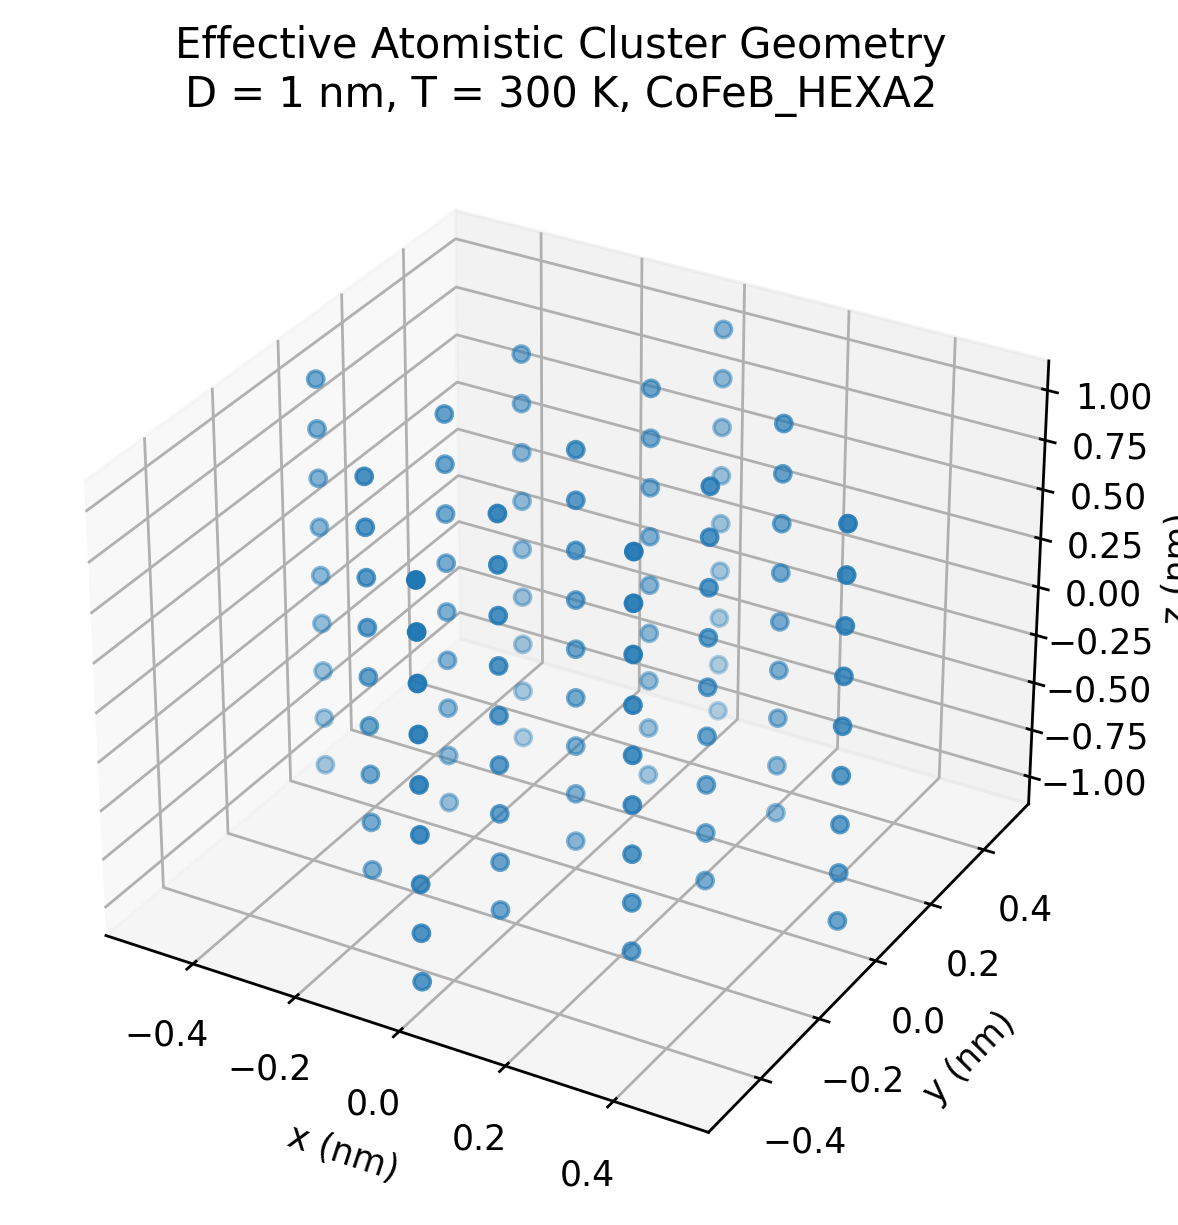

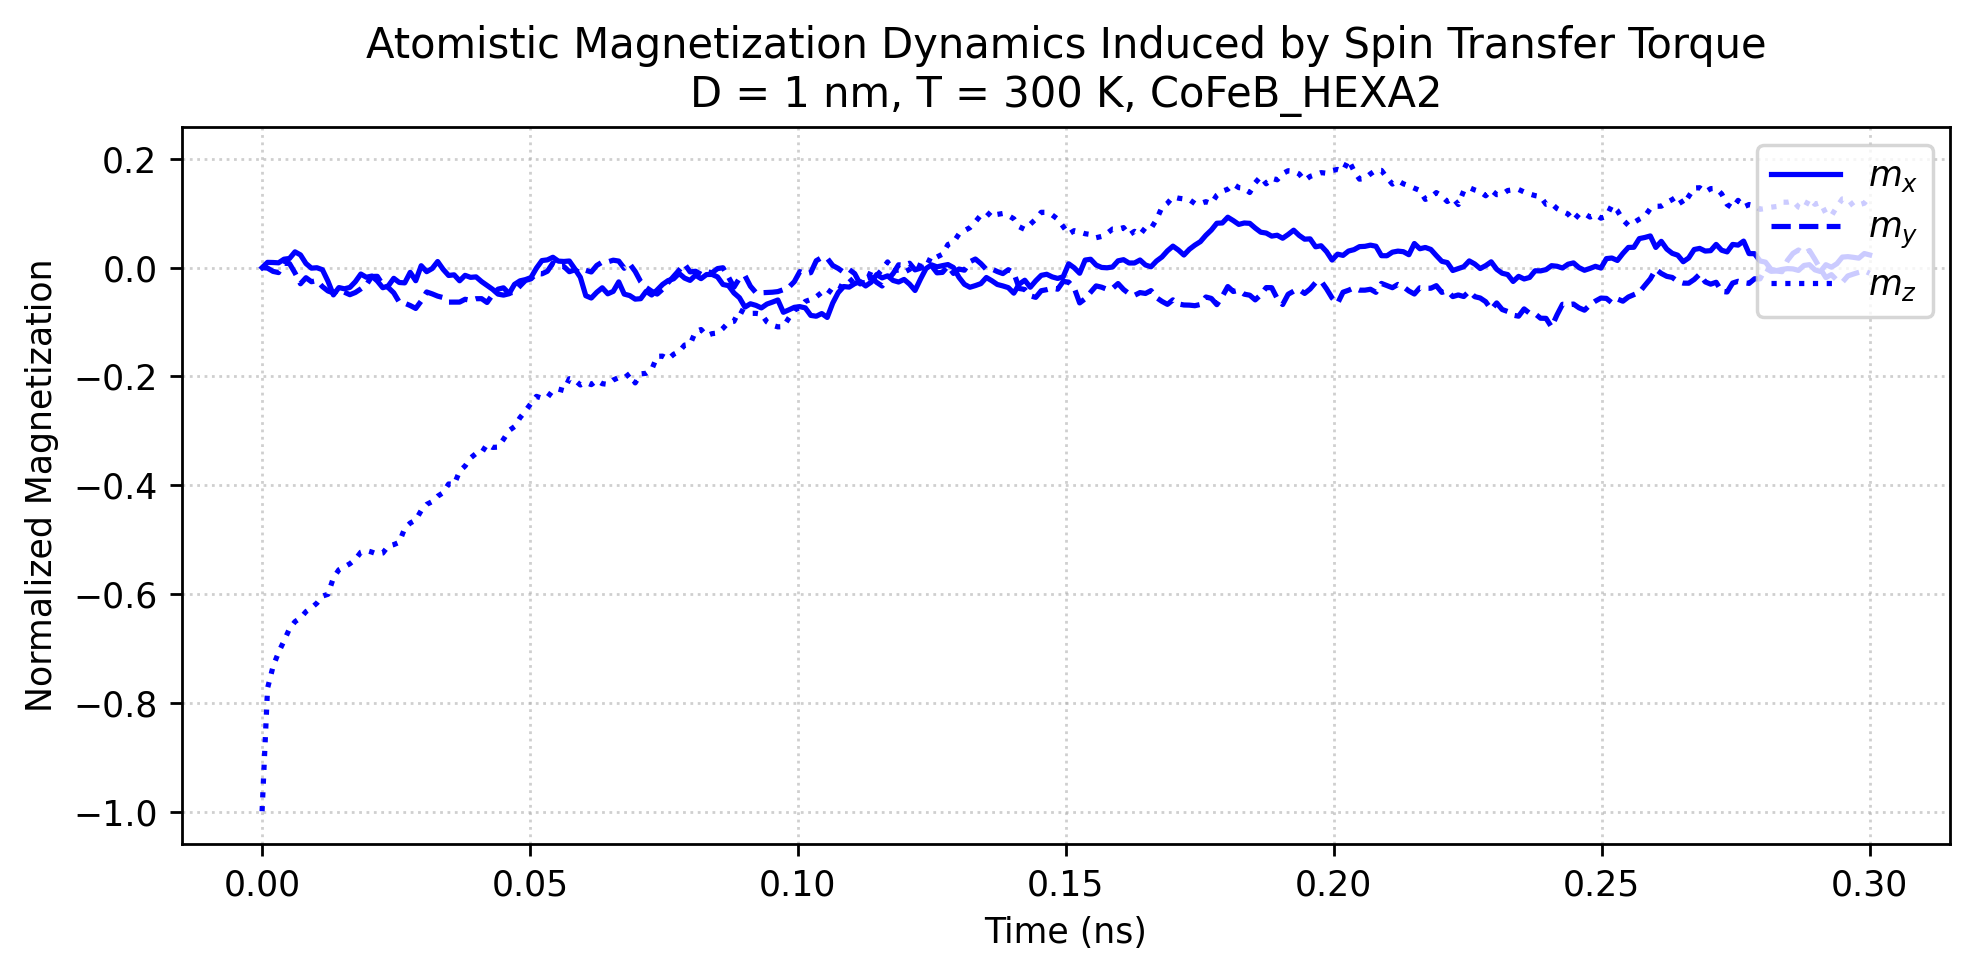

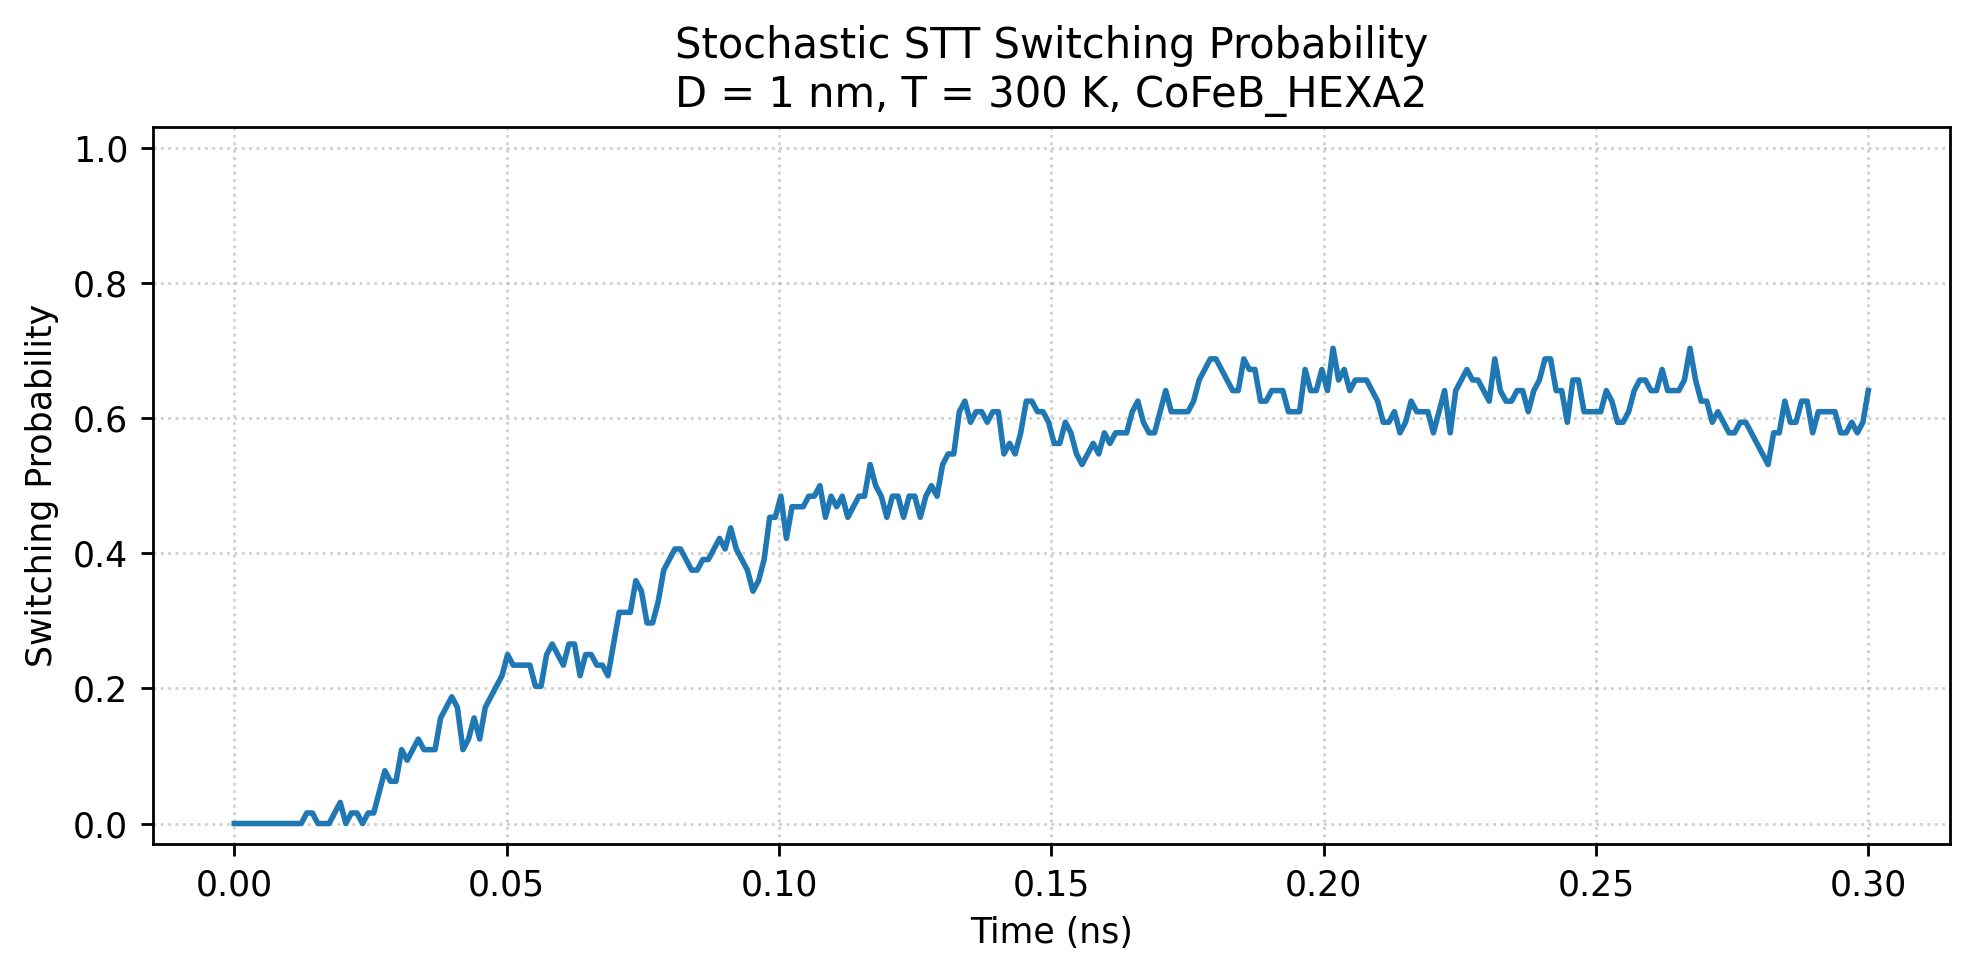

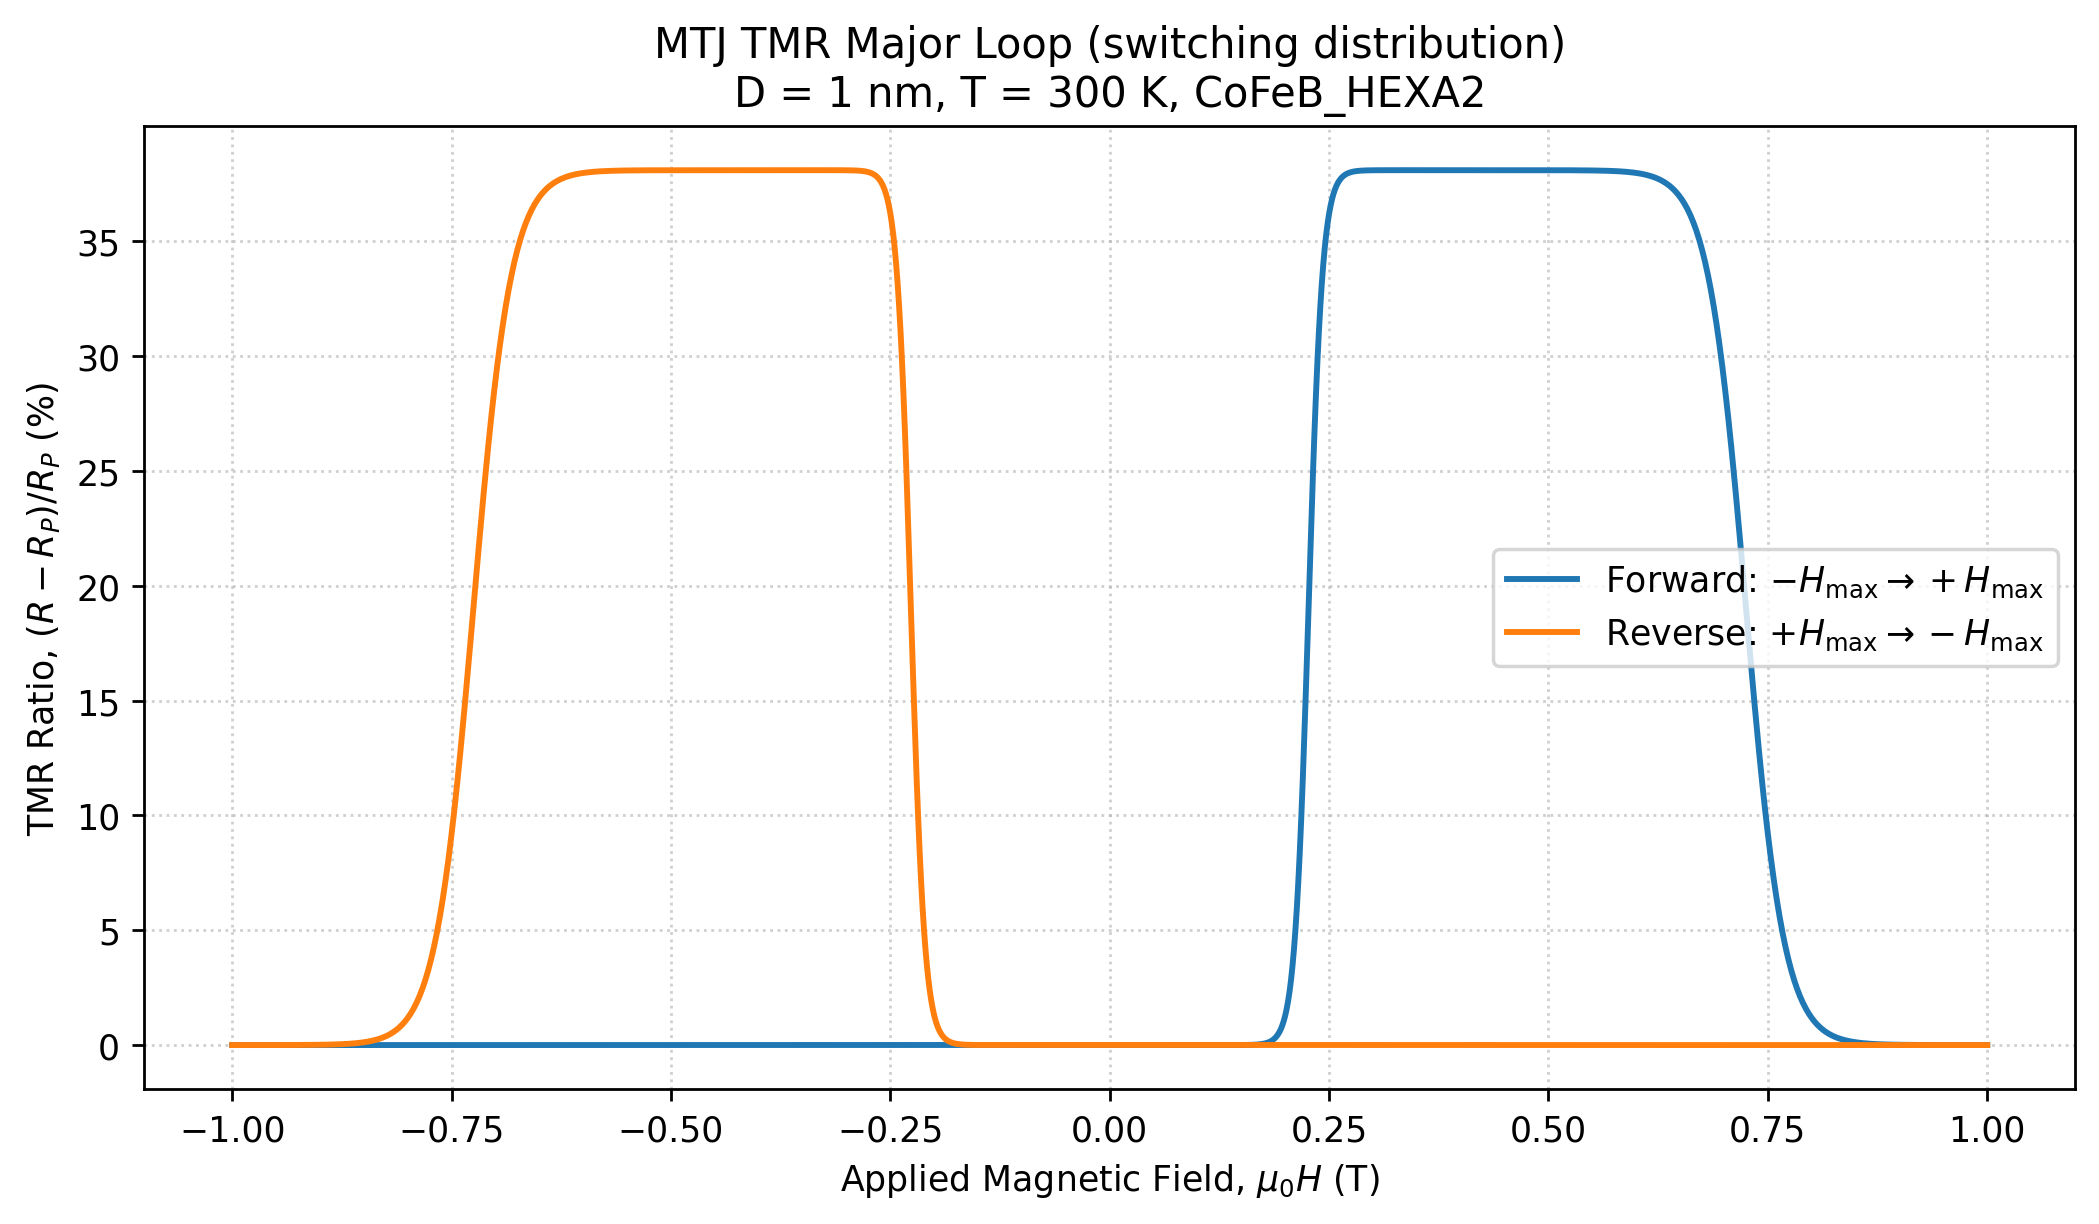

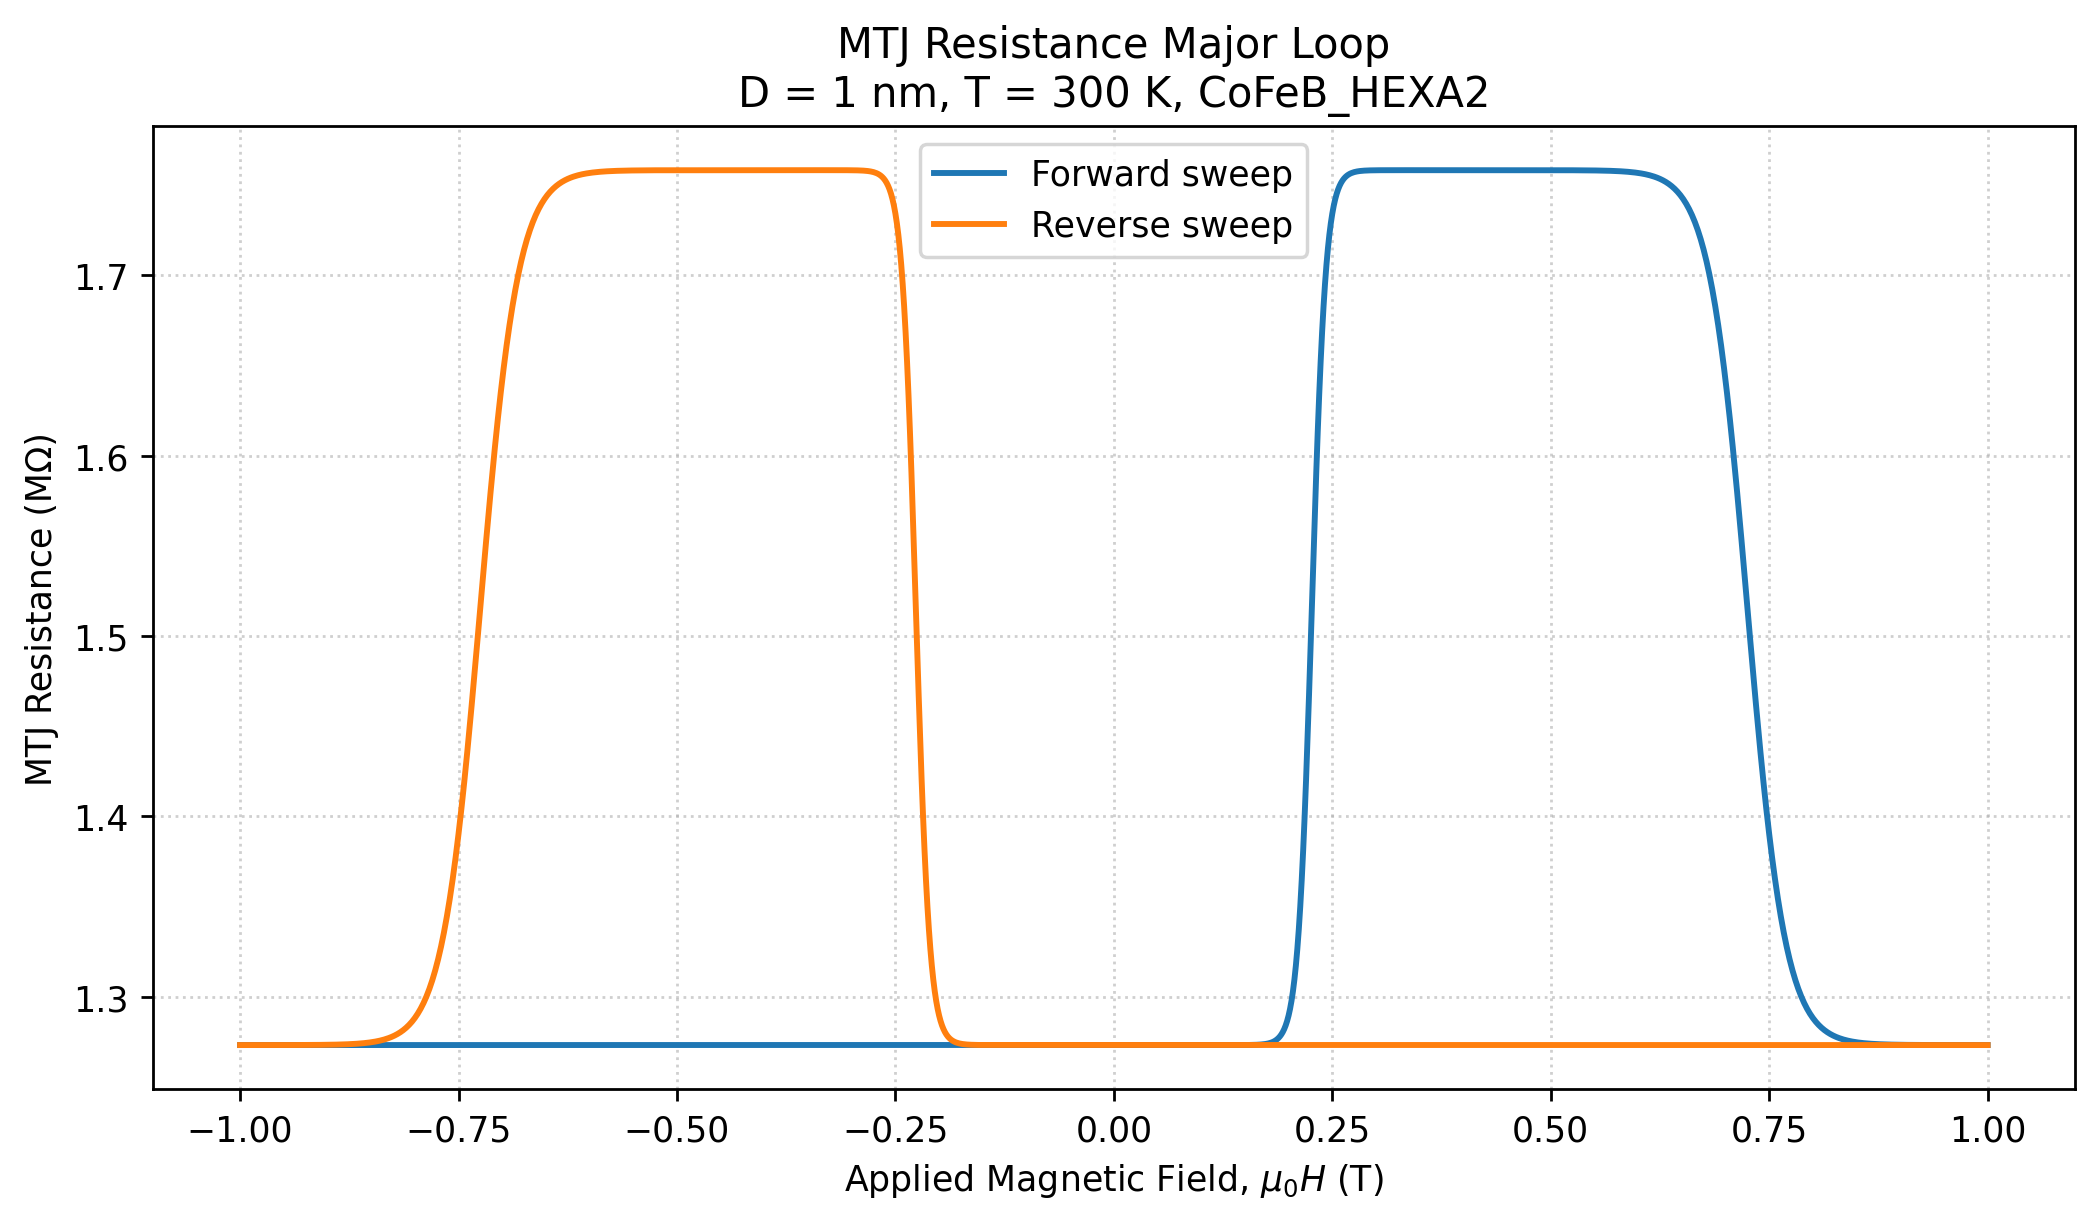

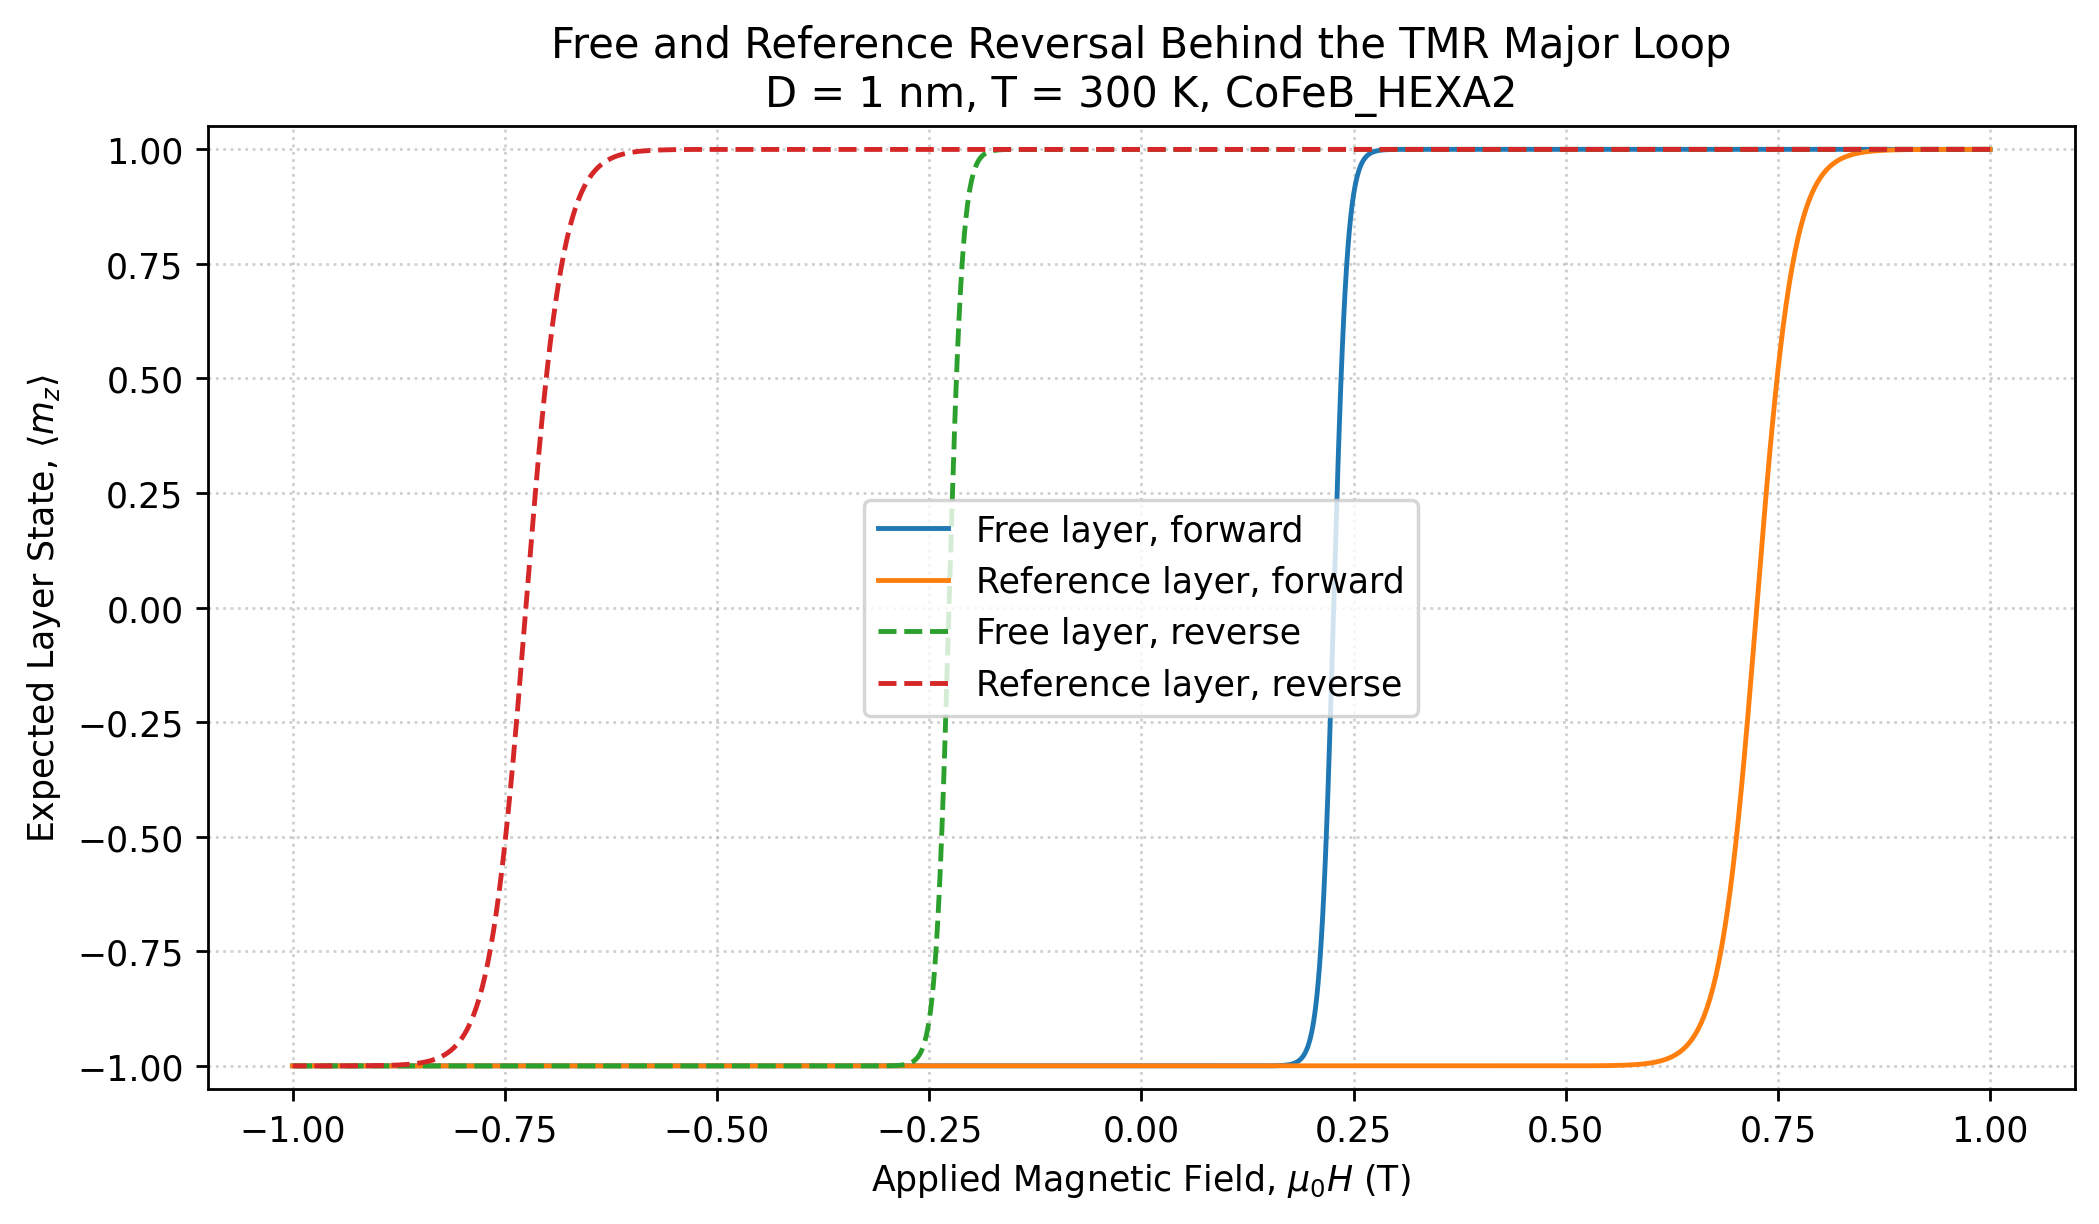

Major-loop fields: Hc_free=0.2266 T, Hc_ref=0.7251 T, Hk_free=0.6474 T, Hk_ref=1.133 T


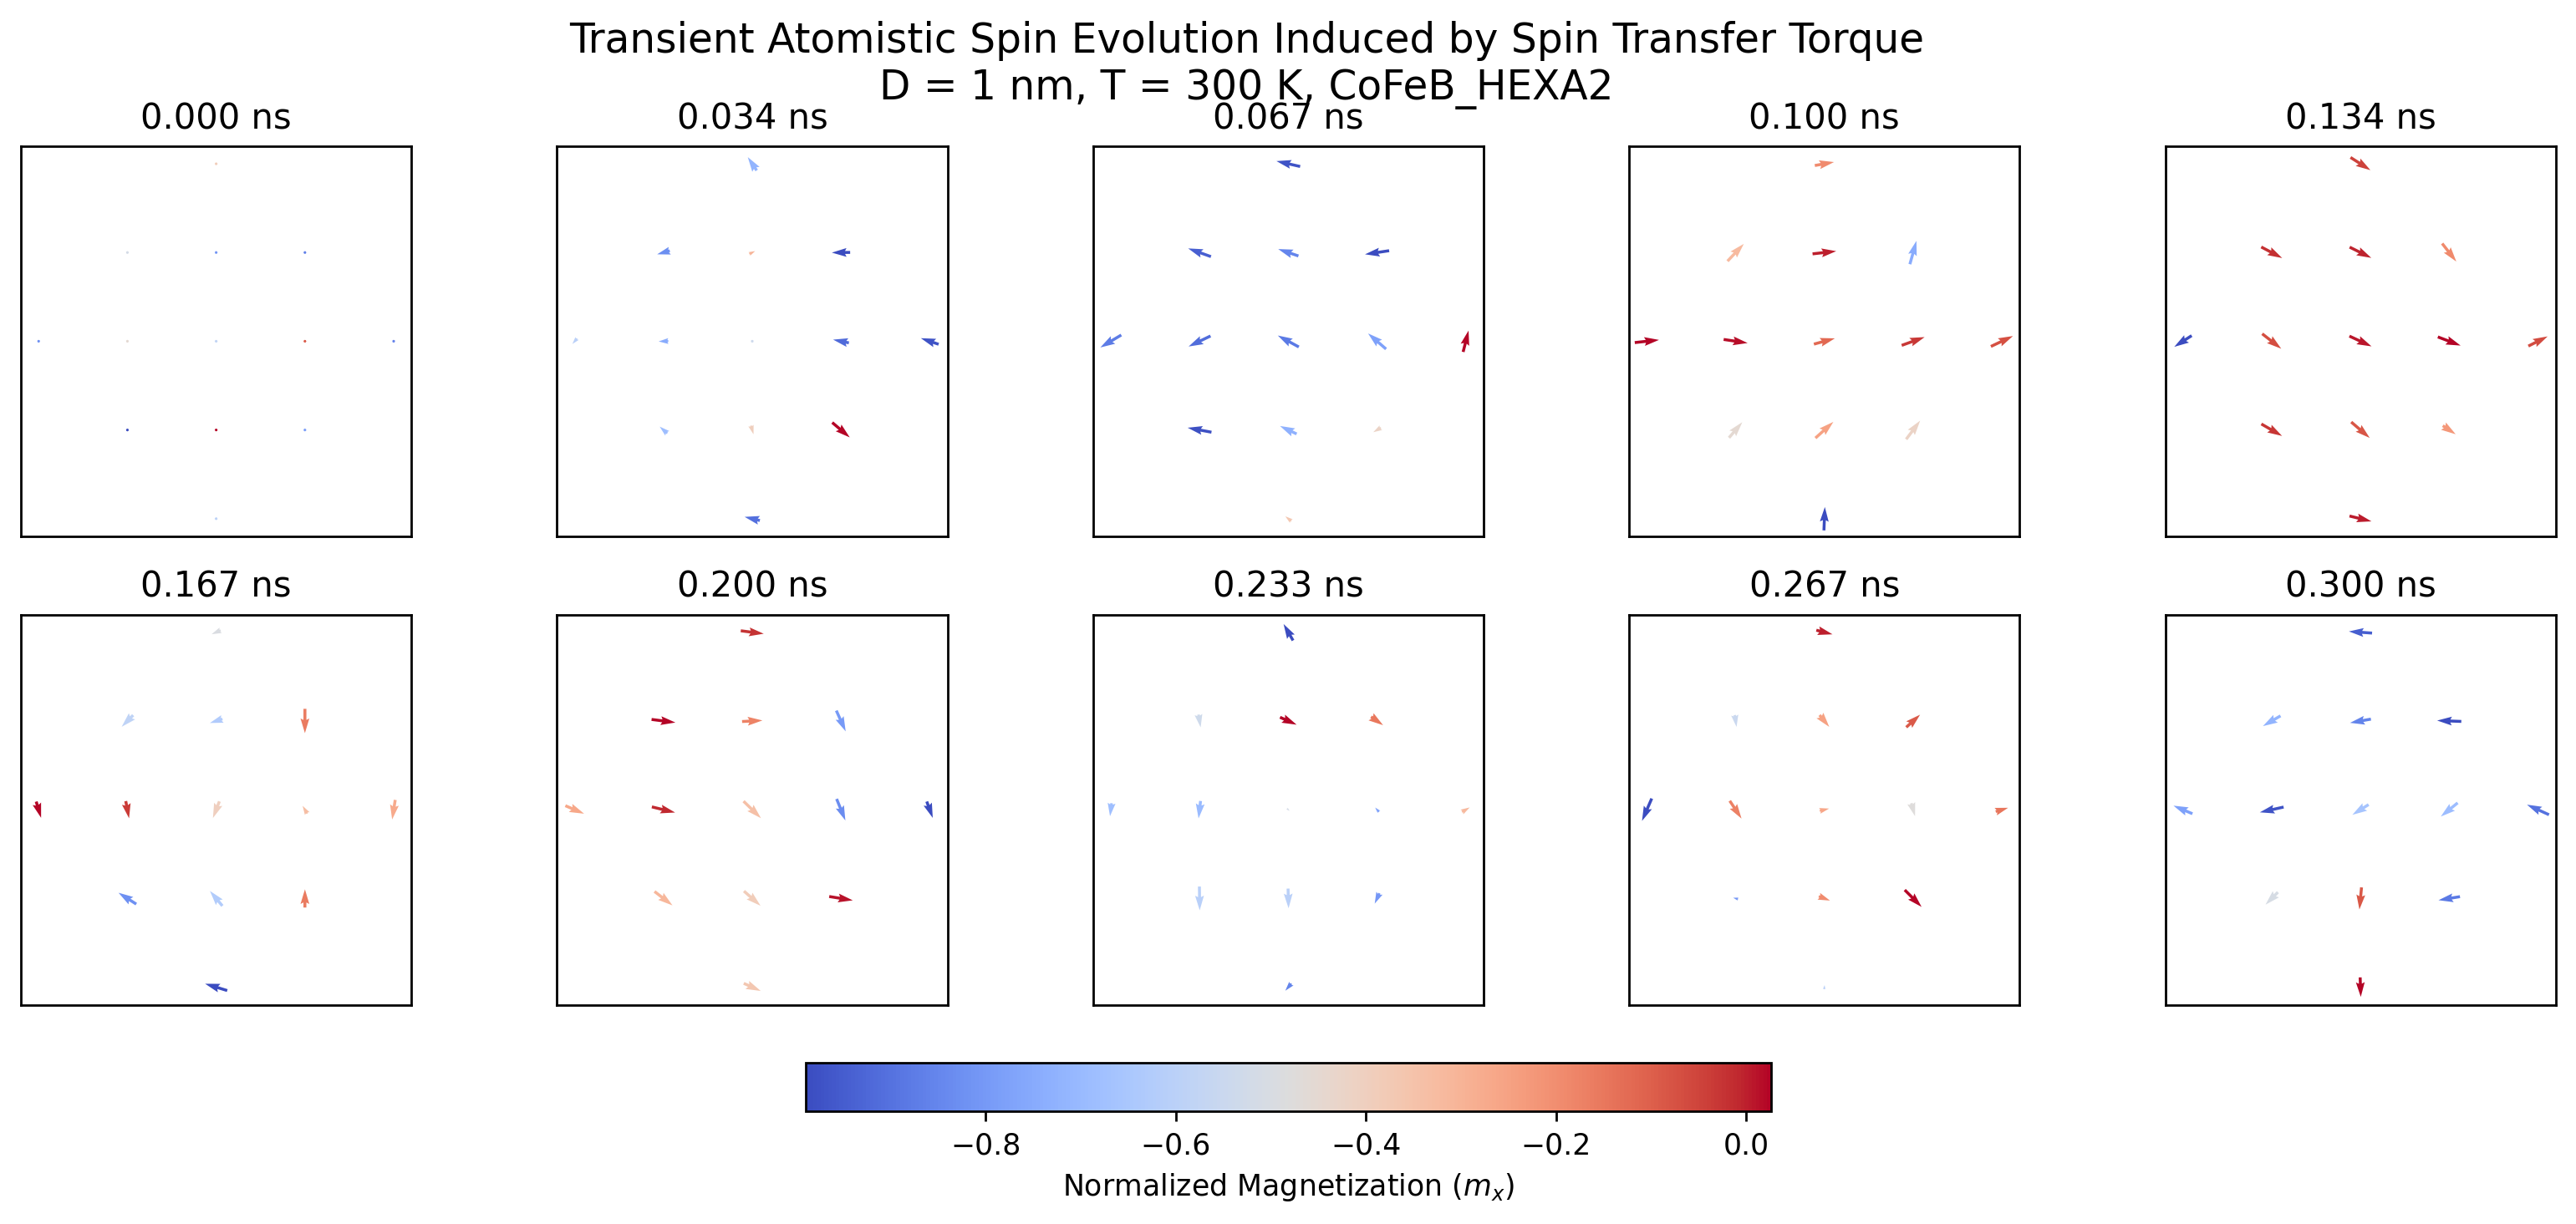

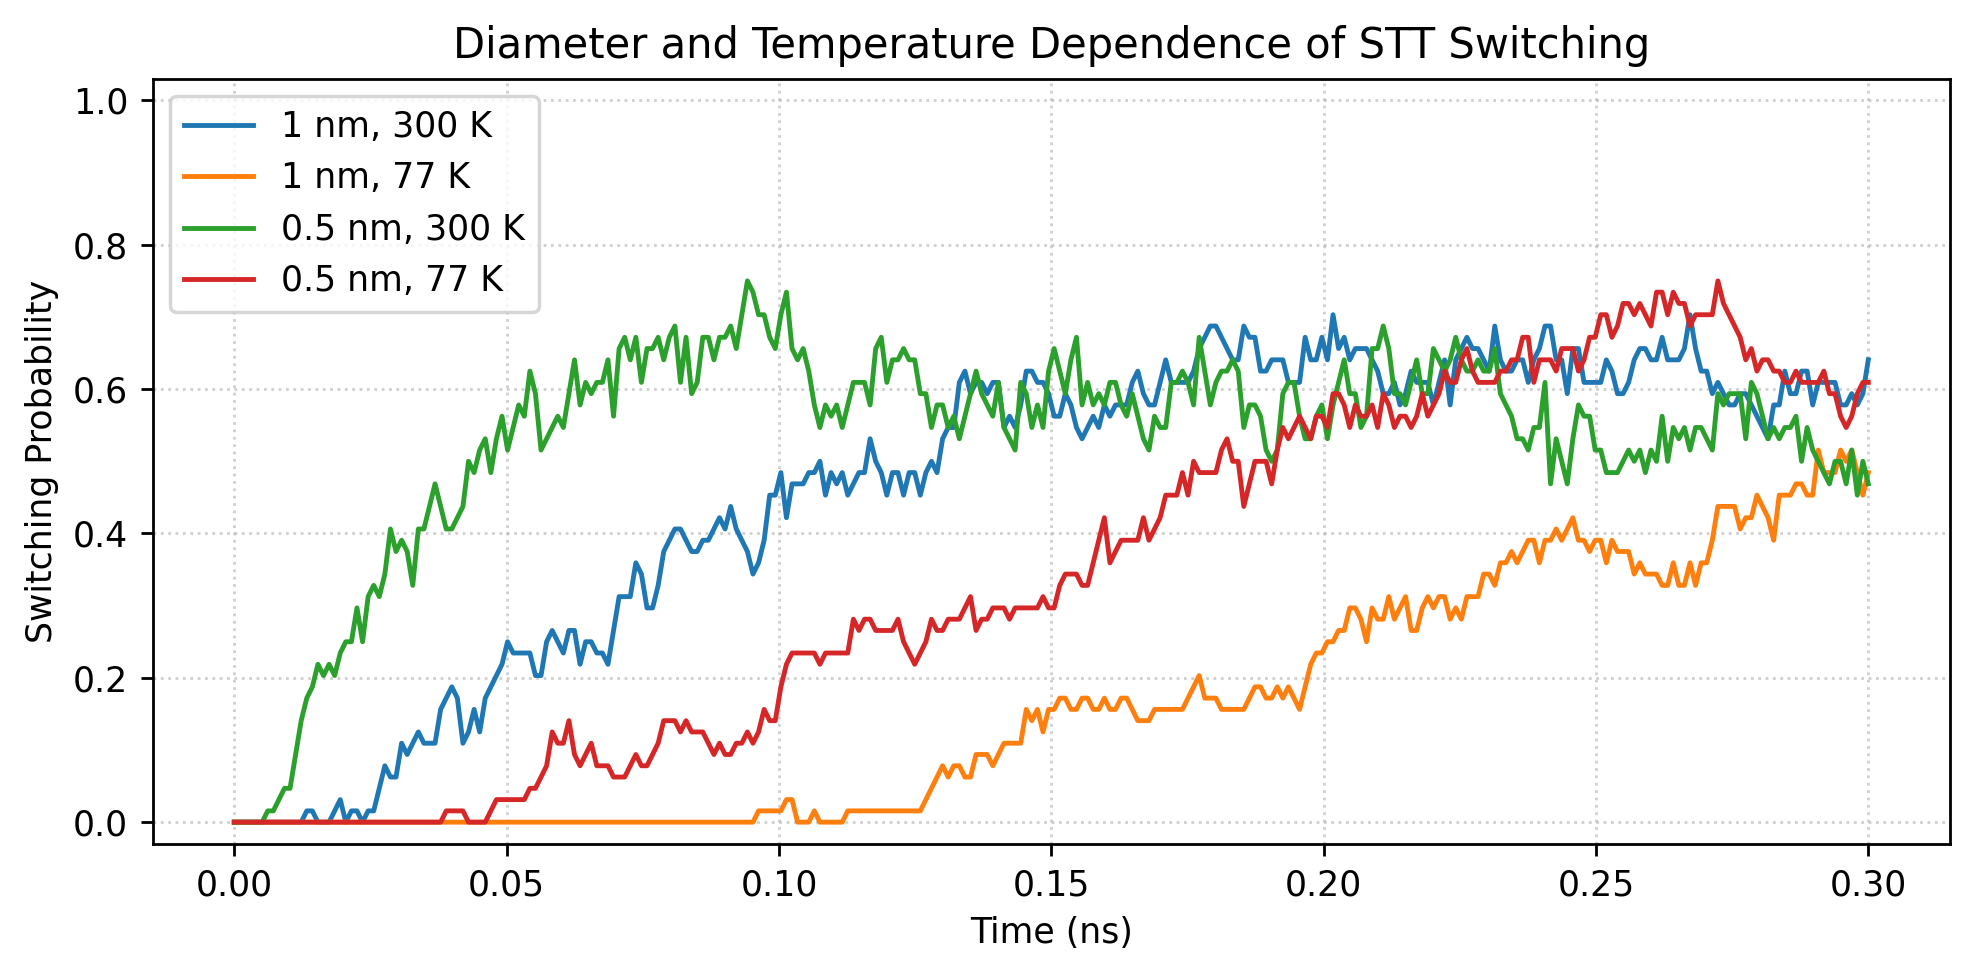

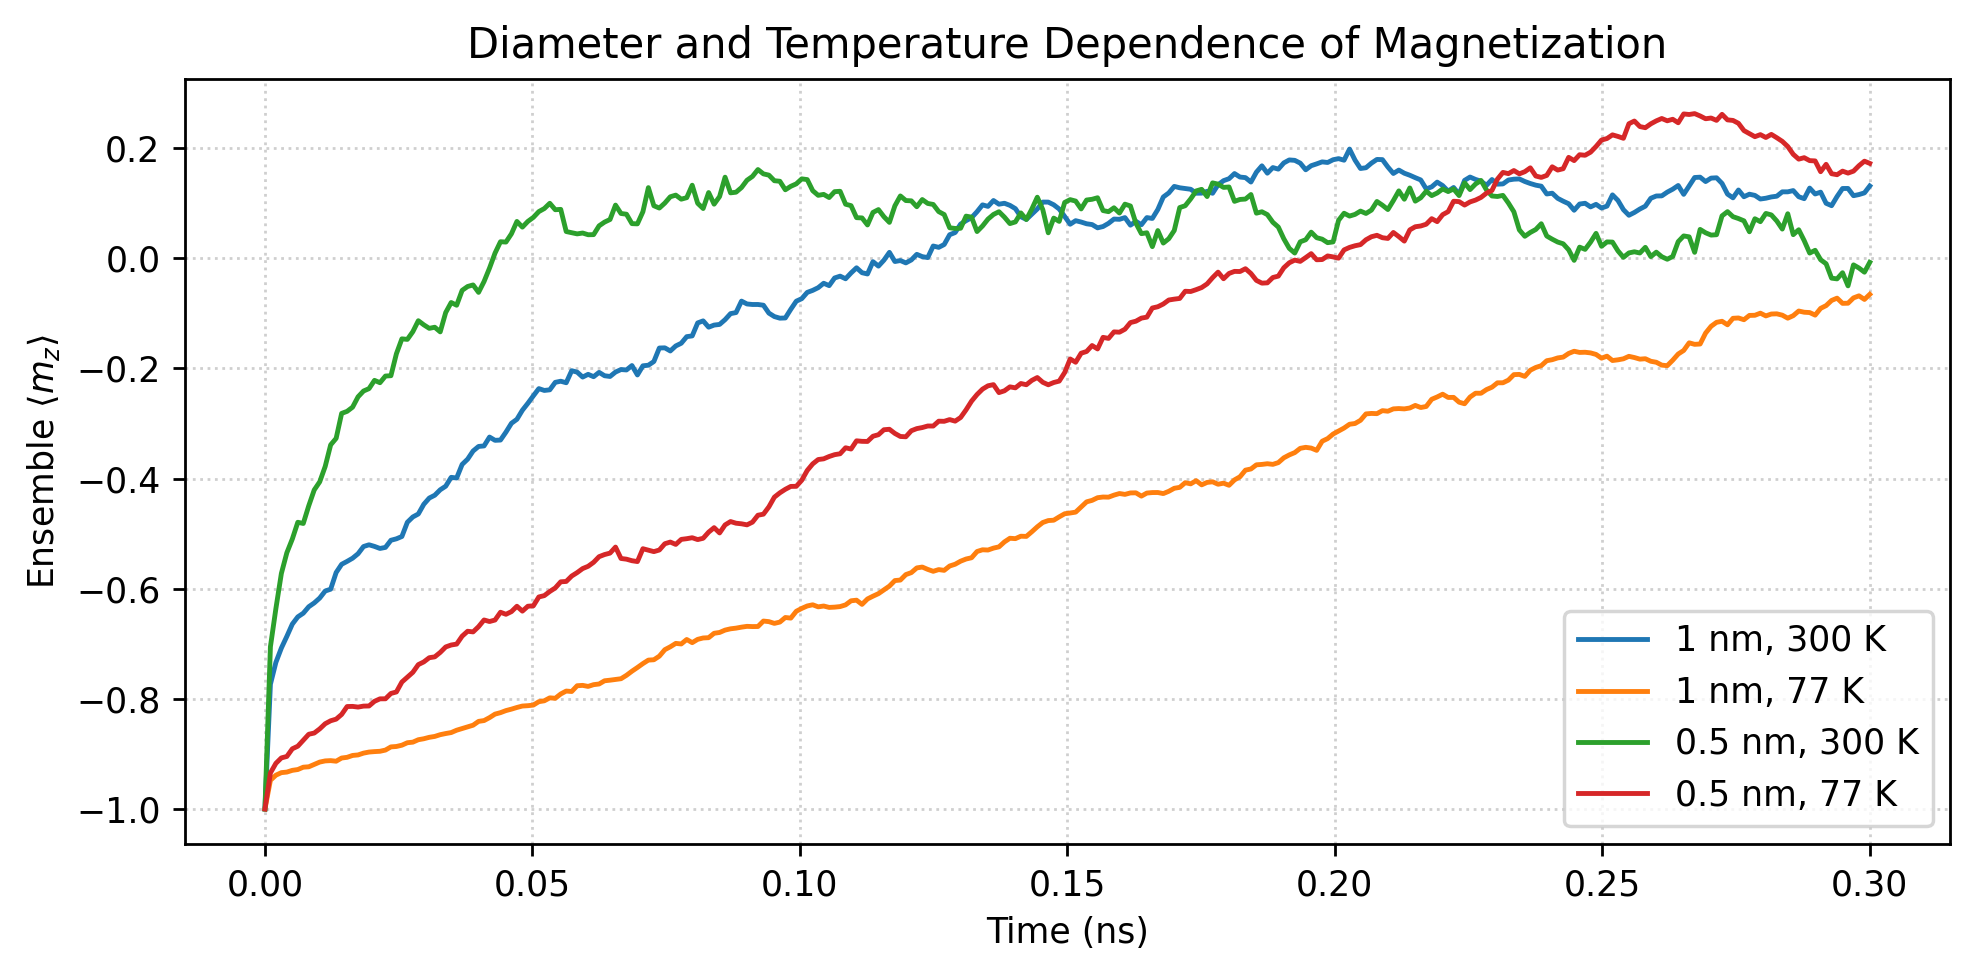

In [1]:
"""GPU atomistic spin-cluster solver for ultrascaled STT magnetic tunnel junctions."""

import math
import time
from dataclasses import dataclass
from typing import Any

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------

FIGURE_RESOLUTION_DPI = 250
FONT_FAMILY_PREFERENCE = ["Tahoma", "DejaVu Sans"]
FONT_WEIGHT_PREFERENCE = "normal"

# Device sweep requested in this study.
DEVICE_DIAMETERS_NM = [1.0, 0.5]
TEMPERATURES_K = [300.0, 77.0]

# Select independent stack components here.
FREE_LAYER_MATERIAL = "CoFeB_HEXA2"
REFERENCE_LAYER_MATERIAL = "CoFeB_HEXA2"
TUNNEL_CHANNEL_MATERIAL = "MgO"

# Source-supported reference concept. Accepted values:
# "single_fixed" or "FePd_Ir_FePd_SAF_fixed".
REFERENCE_STACK = "single_fixed"

# Free-layer thickness is an extrapolative geometry knob.
FREE_LAYER_THICKNESS_NM = 2.0

# Physical integration controls.
RUN_TIME_NS = 0.30
DT_FS = 0.25
N_TRAJECTORIES = 64
INTEGRATION_BLOCK_STEPS = 2048
RECORD_EVERY_BLOCKS = 2
RANDOM_SEED = 19

# Initial and target magnetic states relative to the +z reference layer.
START_STATE = "AP"  # "AP" or "P"
TARGET_STATE = "P"  # "P" or "AP"
INITIAL_TILT_STD = 0.025

# A trajectory enters the target basin after crossing m_z = 0.  Requiring
# |m_z| > 0.5 during a sub-ns pulse undercounts trajectories that have crossed
# the separatrix and will subsequently relax toward the target easy-axis state.
SWITCH_THRESHOLD_MZ = 0.0

# STT drive. Voltage mode uses J = V / RA.
DRIVE_MODE = "voltage"  # "voltage" or "current_density"
PULSE_VOLTAGE_V = 1.00
CURRENT_DENSITY_A_M2 = 8.0e11
PULSE_START_NS = 0.02
PULSE_WIDTH_NS = 0.25

# The sign of m x (m x p) that destabilizes AP and drives AP -> P is negative
# for the CUDA convention used below.  Leave the override as None to select
# the sign from TARGET_STATE automatically.
STT_SIGN_OVERRIDE = None
SLONCZEWSKI_LAMBDA = 1.0
FIELD_LIKE_TORQUE_RATIO = 0.0

# External field in tesla.
EXTERNAL_FIELD_T = (0.0, 0.0, 0.0)

# Atomistic terms.
# The CoFeB_HEXA2 Ku preset is derived from an effective anisotropy field,
# so explicit dipoles are off by default to avoid counting shape effects twice.
# Turn them on for a separately calibrated intrinsic-anisotropy model.
INCLUDE_DIPOLE_FIELD = False
AEX_SCALE = 1.0

# Optional thermal initialization. Metropolis affects the initial ensemble only.
USE_METROPOLIS_PRETHERMALIZATION = False
MC_SWEEPS = 80
MC_PROPOSAL_STD = 0.12

# TMR model.
TMR_MODEL = "julliere"  # "julliere" or "fixed"
FIXED_TMR_RATIO = 0.85

# TMR major-loop controls.
#
# MAJOR_LOOP_MODEL = "switching_distribution" reproduces the standard
# low-R -> high-R -> low-R MTJ major-loop topology by allowing both the
# free and hard/reference magnets to reverse.  Its coercive fields are
# derived from the selected material anisotropy fields and explicit,
# adjustable fractions.
#
# MAJOR_LOOP_MODEL = "thermal_kinetic" retains the Neel-Brown model.  For the
# requested 1.0 nm and 0.5 nm room-temperature extrapolations this mode can
# legitimately collapse toward a reversible superparamagnetic response.
MAJOR_LOOP_MODEL = "switching_distribution"

FIELD_SWEEP_MAX_T = 1.00
FIELD_SWEEP_POINTS = 1201
FIELD_SWEEP_DWELL_NS = 1.00
FIELD_SWEEP_ATTEMPT_FREQUENCY_HZ = 1.0e9
FIELD_SWEEP_PLOT_RESISTANCE = True
FIELD_SWEEP_PLOT_LAYER_STATES = True
AUTO_EXPAND_FIELD_SWEEP = True

# Effective hard/reference-layer controls used only for the TMR major loop.
REFERENCE_LAYER_THICKNESS_NM = 3.0
REFERENCE_LAYER_DIAMETER_SCALE = 1.00
REFERENCE_LAYER_KU_SCALE = 1.75

# Coercive-field model for the switching-distribution major loop.
# The reference branch is intentionally harder than the free branch.
FREE_LAYER_HC_FRACTION_OF_HK = 0.35
REFERENCE_LAYER_HC_FRACTION_OF_HK = 0.64
FREE_LAYER_SWITCH_WIDTH_FRACTION = 0.035
REFERENCE_LAYER_SWITCH_WIDTH_FRACTION = 0.030
MIN_SWITCH_WIDTH_T = 0.002

# Optional direct coercive-field overrides.  Keep as None to derive them from
# H_k and the fractions above.
FREE_LAYER_HC_OVERRIDE_T = None
REFERENCE_LAYER_HC_OVERRIDE_T = None

# Measurement-noise option for the field-swept resistance.
ADD_TMR_NOISE = False
TMR_NOISE_SIGMA_FRACTION = 0.010

# Plot controls retained from the earlier notebook.
SNAPSHOT_ROWS = 2
SNAPSHOT_COLUMNS = 5
MAX_SNAPSHOTS = 10
MAGNETIZATION_COLOR_DIRECTION = "M_X"
QUIVER_ARROW_SCALE = 16.0

# Set this to a tuple such as (1.0, 300.0) to plot only one case in detail.
DETAILED_PLOT_CASE = (1.0, 300.0)


# ---------------------------------------------------
# Physical Constants
# ---------------------------------------------------

MU0 = 4.0e-7 * math.pi
K_B = 1.380649e-23
HBAR = 1.054571817e-34
E_CHARGE = 1.602176634e-19
GAMMA = 1.76085963023e11  # rad s^-1 T^-1


# ---------------------------------------------------
# Material and Channel Catalogs
# ---------------------------------------------------

# "source" entries distinguish article-derived quantities from calibration
# placeholders required by the atomistic solver.
MATERIALS: dict[str, dict[str, Any]] = {
    "CoFeB_HEXA2": {
        "label": "CoFeB, HEXA(2)-like",
        "ms_model": "cofeb_bloch",
        "mu0_ms_0_t": 1.59,
        "bloch_a_k_m32": 2.47e-5,
        "alpha": 0.0139,
        "polarization": 0.40,
        "ku_ref_j_m3": 3.57e5,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 3.0,
        "a_xy_nm": 0.25,
        "a_z_nm": 0.25,
        "aex_j_m": 15.0e-12,
        "nominal_tmr_ratio": None,
        "source": (
            "paper: Ms(T) Bloch parameters; alpha=0.0139 global fit; "
            "P=0.4 design value; mu0 Hk_eff=0.65 T for the 4.5 nm HEXA(2) "
            "example. a and Aex are effective atomistic calibration placeholders."
        ),
    },
    "CoFeB_ULTRATHIN": {
        "label": "[CoFeB(0.66)/MgO]3-inspired CoFeB",
        "ms_model": "cofeb_bloch_scaled",
        "mu0_ms_0_t": 1.59,
        "bloch_a_k_m32": 2.47e-5,
        "mu0_ms_ref_t": 1.70,
        "alpha": 0.005,
        "polarization": 0.40,
        "ku_ref_j_m3": 4.44e-3 / 0.66e-9,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 3.0,
        "a_xy_nm": 0.25,
        "a_z_nm": 0.25,
        "aex_j_m": 15.0e-12,
        "nominal_tmr_ratio": None,
        "source": (
            "paper: mu0 Ms=1.70 T, alpha=0.005, P=0.4, "
            "Ki=4.44 mJ/m^2 for the proposed ultrathin structure. "
            "a and Aex are calibration placeholders."
        ),
    },
    "L10_FePd": {
        "label": "L1_0-FePd",
        "ms_model": "constant",
        "ms_a_m": 1.10e6,
        "alpha": 0.012,
        "polarization": 0.40,
        "ku_ref_j_m3": 1.13e6,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 0.0,
        "a_xy_nm": 0.40,
        "a_z_nm": 0.382,
        "aex_j_m": 10.0e-12,
        "nominal_tmr_ratio": 0.85,
        "source": (
            "paper: Ms=1.1 MA/m assumption, measured Ku=1.13 MJ/m^3, "
            "measured alpha approximately 0.012, PMA maintained from 4 to 400 K, "
            "and projected TMR up to 85% in earlier FePd MTJ work. "
            "P and Aex are calibration placeholders."
        ),
    },
    "L10_MnAl": {
        "label": "L1_0-MnAl",
        "ms_model": "constant",
        "ms_a_m": 0.60 / MU0,
        "alpha": 0.005,
        "polarization": 0.40,
        "ku_ref_j_m3": 8.5e5,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 0.0,
        "a_xy_nm": 0.39,
        "a_z_nm": 0.36,
        "aex_j_m": 10.0e-12,
        "nominal_tmr_ratio": None,
        "source": (
            "CoFeB/MgO paper design calculation: mu0 Ms=0.60 T, "
            "alpha=0.005, P=0.4, Kb=8.5e5 J/m^3. "
            "lattice spacings and Aex are calibration placeholders."
        ),
    },
}

CHANNELS: dict[str, dict[str, Any]] = {
    "MgO": {
        "label": "MgO tunnel barrier",
        "ra_ohm_um2": 1.0,
        "barrier_thickness_nm": 0.94,
        "source": (
            "paper-inspired: RA around 1.0 ohm um^2 for QUAD(2)/OCTA(2), "
            "with approximately 0.93 to 0.98 nm MgO barriers in several stacks."
        ),
    },
    "MgO_low_RA": {
        "label": "MgO custom low-RA",
        "ra_ohm_um2": 0.5,
        "barrier_thickness_nm": 0.90,
        "source": "custom extrapolative channel preset",
    },
}

FE_PD_SAF = {
    "ir_spacer_nm": 0.45,
    "jex_j_m2": -3.48e-3,
    "top_fepd_nm": 3.0,
    "bottom_fepd_nm": 6.0,
    "source": (
        "FePd paper: Ir spacer range 0.45 to 0.60 nm; representative "
        "-Jex=3.48 +/- 1.09 mJ/m^2; top/bottom FePd thicknesses 3/6 nm."
    ),
}


# ---------------------------------------------------
# Data Containers
# ---------------------------------------------------

@dataclass
class Geometry:
    """Store the effective atomistic pillar geometry and adjacency."""

    positions_m: np.ndarray
    neighbors: np.ndarray
    a_xy_m: float
    a_z_m: float
    site_volume_m3: float


@dataclass
class CaseParameters:
    """Store all derived quantities for one diameter-temperature case."""

    diameter_nm: float
    temperature_k: float
    geometry: Geometry
    ms_a_m: float
    alpha: float
    polarization_free: float
    polarization_ref: float
    ku_j_m3: float
    mu_s_j_t: float
    k_site_j: float
    j_exchange_j: float
    exchange_field_scale_t: float
    anisotropy_field_scale_t: float
    thermal_sigma_t: float
    free_thickness_m: float
    reference_vector: np.ndarray
    dipole_tensor_t: np.ndarray
    ra_ohm_m2: float
    area_m2: float
    rp_ohm: float
    tmr_ratio: float


# ---------------------------------------------------
# Matplotlib Configuration
# ---------------------------------------------------

plt.rcParams["figure.dpi"] = FIGURE_RESOLUTION_DPI
plt.rcParams["font.sans-serif"] = FONT_FAMILY_PREFERENCE
plt.rcParams["font.weight"] = FONT_WEIGHT_PREFERENCE


# ---------------------------------------------------
# Material Helpers
# ---------------------------------------------------

def ms_at_temperature(material: dict[str, Any], temperature_k: float) -> float:
    """Return saturation magnetization in A/m at the requested temperature."""
    model = material["ms_model"]

    if model == "constant":
        return float(material["ms_a_m"])

    mu0_ms_t = material["mu0_ms_0_t"] * (
        1.0 - material["bloch_a_k_m32"] * temperature_k ** 1.5
    )

    if model == "cofeb_bloch_scaled":
        mu0_ms_300 = material["mu0_ms_0_t"] * (
            1.0 - material["bloch_a_k_m32"] * 300.0 ** 1.5
        )
        mu0_ms_t *= material["mu0_ms_ref_t"] / mu0_ms_300

    return max(mu0_ms_t / MU0, 1.0)


def ku_at_temperature(
    material: dict[str, Any],
    temperature_k: float,
) -> float:
    """Return the effective uniaxial anisotropy density in J/m^3."""
    ku_ref = float(material["ku_ref_j_m3"])
    exponent = float(material["ku_temp_exponent"])

    if exponent == 0.0 or material["ms_model"] == "constant":
        return ku_ref

    ms_t = ms_at_temperature(material, temperature_k)
    ms_ref = ms_at_temperature(material, material["ku_ref_temp_k"])
    return ku_ref * (ms_t / ms_ref) ** exponent


def material_table() -> pd.DataFrame:
    """Return a readable table of selectable magnetic material presets."""
    rows = []
    for key, value in MATERIALS.items():
        rows.append(
            {
                "Key": key,
                "Label": value["label"],
                "alpha": value["alpha"],
                "P": value["polarization"],
                "Ku at 300 K (MJ/m^3)": ku_at_temperature(value, 300.0) / 1e6,
                "Ms at 300 K (MA/m)": ms_at_temperature(value, 300.0) / 1e6,
                "a_xy (nm)": value["a_xy_nm"],
                "Aex (pJ/m)": value["aex_j_m"] * 1e12,
                "Parameter status": value["source"],
            }
        )
    return pd.DataFrame(rows)


# ---------------------------------------------------
# Geometry and Adjacency
# ---------------------------------------------------

def build_cylindrical_cluster(
    diameter_nm: float,
    thickness_nm: float,
    a_xy_nm: float,
    a_z_nm: float,
) -> Geometry:
    """Construct a simple effective lattice inside a circular nanopillar."""
    diameter_m = diameter_nm * 1e-9
    thickness_m = thickness_nm * 1e-9
    a_xy_m = a_xy_nm * 1e-9
    a_z_m = a_z_nm * 1e-9
    radius_m = diameter_m / 2.0

    n_r = max(1, int(math.ceil(radius_m / a_xy_m)))
    n_z = max(0, int(math.floor((thickness_m / 2.0) / a_z_m)))

    index_to_site: dict[tuple[int, int, int], int] = {}
    positions = []

    for iz in range(-n_z, n_z + 1):
        z = iz * a_z_m
        if abs(z) > thickness_m / 2.0 + 1e-15:
            continue

        for iy in range(-n_r, n_r + 1):
            y = iy * a_xy_m
            for ix in range(-n_r, n_r + 1):
                x = ix * a_xy_m
                if x * x + y * y <= radius_m * radius_m + 1e-30:
                    site = len(positions)
                    index_to_site[(ix, iy, iz)] = site
                    positions.append((x, y, z))

    if not positions:
        raise RuntimeError("The selected diameter and lattice spacing produced no spins.")

    neighbor_offsets = (
        (1, 0, 0),
        (-1, 0, 0),
        (0, 1, 0),
        (0, -1, 0),
        (0, 0, 1),
        (0, 0, -1),
    )
    neighbors = np.full((len(positions), 6), -1, dtype=np.int32)

    for grid_index, site in index_to_site.items():
        ix, iy, iz = grid_index
        for slot, (dx, dy, dz) in enumerate(neighbor_offsets):
            neighbors[site, slot] = index_to_site.get(
                (ix + dx, iy + dy, iz + dz),
                -1,
            )

    return Geometry(
        positions_m=np.asarray(positions, dtype=np.float64),
        neighbors=neighbors,
        a_xy_m=a_xy_m,
        a_z_m=a_z_m,
        site_volume_m3=a_xy_m * a_xy_m * a_z_m,
    )


def build_dipole_tensor(
    positions_m: np.ndarray,
    mu_s_j_t: float,
) -> np.ndarray:
    """Precompute the magnetic field tensor from every spin j onto spin i."""
    n_spins = positions_m.shape[0]
    tensor = np.zeros((n_spins, n_spins, 3, 3), dtype=np.float32)
    identity = np.eye(3)

    for i in range(n_spins):
        for j in range(n_spins):
            if i == j:
                continue
            r_vec = positions_m[i] - positions_m[j]
            r = np.linalg.norm(r_vec)
            r_hat = r_vec / r
            prefactor = MU0 * mu_s_j_t / (4.0 * math.pi * r**3)
            tensor[i, j] = (
                prefactor
                * (3.0 * np.outer(r_hat, r_hat) - identity)
            ).astype(np.float32)

    return tensor


# ---------------------------------------------------
# TMR and Case Construction
# ---------------------------------------------------

def julliere_tmr(p_free: float, p_ref: float) -> float:
    """Return the Julliere tunnel magnetoresistance ratio."""
    product = p_free * p_ref
    denominator = max(1.0 - product, 1e-8)
    return 2.0 * product / denominator


def make_case_parameters(
    diameter_nm: float,
    temperature_k: float,
) -> CaseParameters:
    """Derive all atomistic and transport parameters for one case."""
    free_material = MATERIALS[FREE_LAYER_MATERIAL]
    ref_material = MATERIALS[REFERENCE_LAYER_MATERIAL]
    channel = CHANNELS[TUNNEL_CHANNEL_MATERIAL]

    geometry = build_cylindrical_cluster(
        diameter_nm=diameter_nm,
        thickness_nm=FREE_LAYER_THICKNESS_NM,
        a_xy_nm=free_material["a_xy_nm"],
        a_z_nm=free_material["a_z_nm"],
    )

    ms_a_m = ms_at_temperature(free_material, temperature_k)
    ku_j_m3 = ku_at_temperature(free_material, temperature_k)
    mu_s_j_t = ms_a_m * geometry.site_volume_m3
    k_site_j = ku_j_m3 * geometry.site_volume_m3

    # For a simple-cubic classical Heisenberg lattice, A approximately J/(2a).
    # Aex itself is a user-calibration quantity in the supplied-paper context.
    j_exchange_j = (
        2.0
        * free_material["aex_j_m"]
        * geometry.a_xy_m
        * AEX_SCALE
    )
    exchange_field_scale_t = j_exchange_j / mu_s_j_t
    anisotropy_field_scale_t = 2.0 * k_site_j / mu_s_j_t

    dt_s = DT_FS * 1e-15
    alpha = float(free_material["alpha"])
    thermal_sigma_t = math.sqrt(
        max(
            2.0 * alpha * K_B * temperature_k
            / (GAMMA * mu_s_j_t * dt_s),
            0.0,
        )
    )

    free_thickness_m = FREE_LAYER_THICKNESS_NM * 1e-9
    reference_vector = np.asarray((0.0, 0.0, 1.0), dtype=np.float32)

    if INCLUDE_DIPOLE_FIELD:
        dipole_tensor_t = build_dipole_tensor(
            geometry.positions_m,
            mu_s_j_t,
        )
    else:
        n_spins = geometry.positions_m.shape[0]
        dipole_tensor_t = np.zeros(
            (n_spins, n_spins, 3, 3),
            dtype=np.float32,
        )

    area_m2 = math.pi * (diameter_nm * 1e-9) ** 2 / 4.0
    ra_ohm_m2 = channel["ra_ohm_um2"] * 1e-12
    rp_ohm = ra_ohm_m2 / area_m2

    p_free = float(free_material["polarization"])
    p_ref = float(ref_material["polarization"])

    if TMR_MODEL.lower() == "fixed":
        tmr_ratio = FIXED_TMR_RATIO
    else:
        tmr_ratio = julliere_tmr(p_free, p_ref)

    return CaseParameters(
        diameter_nm=diameter_nm,
        temperature_k=temperature_k,
        geometry=geometry,
        ms_a_m=ms_a_m,
        alpha=alpha,
        polarization_free=p_free,
        polarization_ref=p_ref,
        ku_j_m3=ku_j_m3,
        mu_s_j_t=mu_s_j_t,
        k_site_j=k_site_j,
        j_exchange_j=j_exchange_j,
        exchange_field_scale_t=exchange_field_scale_t,
        anisotropy_field_scale_t=anisotropy_field_scale_t,
        thermal_sigma_t=thermal_sigma_t,
        free_thickness_m=free_thickness_m,
        reference_vector=reference_vector,
        dipole_tensor_t=dipole_tensor_t,
        ra_ohm_m2=ra_ohm_m2,
        area_m2=area_m2,
        rp_ohm=rp_ohm,
        tmr_ratio=tmr_ratio,
    )


# ---------------------------------------------------
# Equilibrium Energy and Stability Diagnostics
# ---------------------------------------------------

def coherent_state_energy_j(
    spins: np.ndarray,
    case: CaseParameters,
) -> float:
    """Return the classical cluster energy for one coherent spin state."""
    neighbors = case.geometry.neighbors
    exchange_energy = 0.0

    for i in range(spins.shape[0]):
        for j in neighbors[i]:
            if j > i:
                exchange_energy -= case.j_exchange_j * float(
                    np.dot(spins[i], spins[j])
                )

    anisotropy_energy = -case.k_site_j * float(
        np.sum(spins[:, 2] ** 2)
    )

    dipole_energy = 0.0
    if INCLUDE_DIPOLE_FIELD:
        b_dip = np.einsum(
            "ijab,jb->ia",
            case.dipole_tensor_t.astype(np.float64),
            spins,
            optimize=True,
        )
        dipole_energy = -0.5 * case.mu_s_j_t * float(
            np.sum(spins * b_dip)
        )

    external = np.asarray(EXTERNAL_FIELD_T, dtype=np.float64)
    zeeman_energy = -case.mu_s_j_t * float(
        np.sum(spins @ external)
    )

    return (
        exchange_energy
        + anisotropy_energy
        + dipole_energy
        + zeeman_energy
    )


def stability_diagnostics(case: CaseParameters) -> dict[str, float]:
    """Estimate coherent-rotation barrier and numerical stiffness."""
    n_spins = case.geometry.positions_m.shape[0]
    z_state = np.zeros((n_spins, 3), dtype=np.float64)
    z_state[:, 2] = 1.0
    x_state = np.zeros((n_spins, 3), dtype=np.float64)
    x_state[:, 0] = 1.0

    barrier_j = coherent_state_energy_j(x_state, case) - coherent_state_energy_j(
        z_state,
        case,
    )
    barrier_j = max(barrier_j, 0.0)
    delta = (
        barrier_j / (K_B * case.temperature_k)
        if case.temperature_k > 0.0
        else math.inf
    )

    max_exchange_t = (
        np.max(np.sum(case.geometry.neighbors >= 0, axis=1))
        * case.exchange_field_scale_t
    )
    characteristic_angle = GAMMA * max_exchange_t * DT_FS * 1e-15

    return {
        "spin_count": float(n_spins),
        "barrier_eV": barrier_j / E_CHARGE,
        "thermal_stability_delta": delta,
        "max_exchange_field_T": max_exchange_t,
        "gamma_Bex_dt": characteristic_angle,
    }


# ---------------------------------------------------
# Optional Metropolis Initialization
# ---------------------------------------------------

def retention_regime(delta: float) -> str:
    """Classify the zero-field thermal-retention regime."""
    if delta < 1.0:
        return "superparamagnetic-like"
    if delta < 10.0:
        return "retention-limited"
    if delta < 40.0:
        return "short-retention"
    return "nonvolatile-like"


def normalize_gpu(vectors: cp.ndarray) -> cp.ndarray:
    """Normalize the final axis of a CuPy array."""
    norms = cp.linalg.norm(vectors, axis=-1, keepdims=True)
    return vectors / cp.maximum(norms, 1e-20)


def metropolis_prethermalize(
    spins: cp.ndarray,
    case: CaseParameters,
) -> cp.ndarray:
    """Prethermalize an ensemble without assigning time to MC sweeps."""
    if not USE_METROPOLIS_PRETHERMALIZATION or MC_SWEEPS <= 0:
        return spins

    n_spins = spins.shape[1]
    neighbors_np = case.geometry.neighbors
    dipole_cp = cp.asarray(case.dipole_tensor_t)
    beta = (
        1.0 / (K_B * case.temperature_k)
        if case.temperature_k > 0.0
        else math.inf
    )
    external_cp = cp.asarray(EXTERNAL_FIELD_T, dtype=cp.float32)

    rng = np.random.default_rng(RANDOM_SEED + 883)
    for _ in range(MC_SWEEPS):
        for site in rng.permutation(n_spins):
            old = spins[:, site, :].copy()
            proposal = normalize_gpu(
                old
                + MC_PROPOSAL_STD
                * cp.random.standard_normal(
                    old.shape,
                    dtype=cp.float32,
                )
            )
            delta_spin = proposal - old

            neighbor_ids = neighbors_np[site]
            neighbor_ids = neighbor_ids[neighbor_ids >= 0]
            if len(neighbor_ids):
                neighbor_sum = cp.sum(
                    spins[:, neighbor_ids, :],
                    axis=1,
                )
                delta_exchange = -case.j_exchange_j * cp.sum(
                    delta_spin * neighbor_sum,
                    axis=1,
                )
            else:
                delta_exchange = cp.zeros(spins.shape[0], dtype=cp.float32)

            delta_anisotropy = -case.k_site_j * (
                proposal[:, 2] ** 2 - old[:, 2] ** 2
            )
            delta_zeeman = -case.mu_s_j_t * cp.sum(
                delta_spin * external_cp,
                axis=1,
            )

            if INCLUDE_DIPOLE_FIELD:
                field_i = cp.einsum(
                    "jab,tjb->ta",
                    dipole_cp[site],
                    spins,
                    optimize=True,
                )
                delta_dipole = -case.mu_s_j_t * cp.sum(
                    delta_spin * field_i,
                    axis=1,
                )
            else:
                delta_dipole = 0.0

            delta_energy = (
                delta_exchange
                + delta_anisotropy
                + delta_zeeman
                + delta_dipole
            )

            if math.isinf(beta):
                accept = delta_energy <= 0.0
            else:
                probability = cp.exp(
                    cp.minimum(-beta * delta_energy, 0.0)
                )
                accept = (
                    (delta_energy <= 0.0)
                    | (cp.random.random(spins.shape[0]) < probability)
                )

            spins[:, site, :] = cp.where(
                accept[:, None],
                proposal,
                old,
            )

    return spins


# ---------------------------------------------------
# CuPy RawKernel
# ---------------------------------------------------

CUDA_SOURCE = r"""
extern "C" {

__device__ inline void llg_derivative(
    const float* state,
    const int* neighbors,
    const float* dipole,
    int n_spins,
    int max_neighbors,
    int site,
    const float* noise_xyz,
    float exchange_scale,
    float anisotropy_scale,
    float external_bx,
    float external_by,
    float external_bz,
    float thermal_sigma,
    float alpha,
    float gamma,
    float current_density,
    float stt_prefactor,
    float polarization,
    float lambda,
    float p_x,
    float p_y,
    float p_z,
    float stt_sign,
    float field_like_ratio,
    float* out_x,
    float* out_y,
    float* out_z
) {
    const int i3 = 3 * site;
    const float mx = state[i3 + 0];
    const float my = state[i3 + 1];
    const float mz = state[i3 + 2];

    float bx = external_bx;
    float by = external_by;
    float bz = external_bz;

    // Nearest-neighbor Heisenberg exchange field.
    for (int slot = 0; slot < max_neighbors; ++slot) {
        const int j = neighbors[site * max_neighbors + slot];
        if (j >= 0) {
            bx += exchange_scale * state[3 * j + 0];
            by += exchange_scale * state[3 * j + 1];
            bz += exchange_scale * state[3 * j + 2];
        }
    }

    // Uniaxial anisotropy along z.
    bz += anisotropy_scale * mz;

    // Precomputed atomistic dipole field tensor.
    for (int j = 0; j < n_spins; ++j) {
        const int d0 = (site * n_spins + j) * 9;
        const float jx = state[3 * j + 0];
        const float jy = state[3 * j + 1];
        const float jz = state[3 * j + 2];

        bx += (
            dipole[d0 + 0] * jx
            + dipole[d0 + 1] * jy
            + dipole[d0 + 2] * jz
        );
        by += (
            dipole[d0 + 3] * jx
            + dipole[d0 + 4] * jy
            + dipole[d0 + 5] * jz
        );
        bz += (
            dipole[d0 + 6] * jx
            + dipole[d0 + 7] * jy
            + dipole[d0 + 8] * jz
        );
    }

    // Thermal field realization. The same realization is reused by the
    // predictor and corrector during a Heun step.
    bx += thermal_sigma * noise_xyz[0];
    by += thermal_sigma * noise_xyz[1];
    bz += thermal_sigma * noise_xyz[2];

    const float mxb_x = my * bz - mz * by;
    const float mxb_y = mz * bx - mx * bz;
    const float mxb_z = mx * by - my * bx;

    const float mdotb = mx * bx + my * by + mz * bz;
    const float mxxb_x = mx * mdotb - bx;
    const float mxxb_y = my * mdotb - by;
    const float mxxb_z = mz * mdotb - bz;

    const float one_over = 1.0f / (1.0f + alpha * alpha);
    const float gfac = gamma * one_over;

    float dx = -gfac * (mxb_x + alpha * mxxb_x);
    float dy = -gfac * (mxb_y + alpha * mxxb_y);
    float dz = -gfac * (mxb_z + alpha * mxxb_z);

    // Slonczewski damping-like STT with an optional small field-like term.
    const float cos_theta = mx * p_x + my * p_y + mz * p_z;
    const float lambda2 = lambda * lambda;
    const float eta_den = (
        (lambda2 + 1.0f)
        + (lambda2 - 1.0f) * cos_theta
    );
    const float eta = polarization * lambda2 / fmaxf(eta_den, 1.0e-6f);
    const float b_stt = stt_prefactor * current_density * eta;

    const float mxp_x = my * p_z - mz * p_y;
    const float mxp_y = mz * p_x - mx * p_z;
    const float mxp_z = mx * p_y - my * p_x;

    const float mdotp = cos_theta;
    const float mxxp_x = mx * mdotp - p_x;
    const float mxxp_y = my * mdotp - p_y;
    const float mxxp_z = mz * mdotp - p_z;

    dx += (
        stt_sign
        * gfac
        * b_stt
        * (
            mxxp_x
            - alpha * mxp_x
            + field_like_ratio * mxp_x
        )
    );
    dy += (
        stt_sign
        * gfac
        * b_stt
        * (
            mxxp_y
            - alpha * mxp_y
            + field_like_ratio * mxp_y
        )
    );
    dz += (
        stt_sign
        * gfac
        * b_stt
        * (
            mxxp_z
            - alpha * mxp_z
            + field_like_ratio * mxp_z
        )
    );

    *out_x = dx;
    *out_y = dy;
    *out_z = dz;
}


__global__ void heun_block(
    float* spins,
    float* predictor,
    float* d1,
    const int* neighbors,
    const float* dipole,
    const float* noise,
    const float* current_density,
    int n_trajectories,
    int n_spins,
    int max_neighbors,
    int n_steps,
    float dt,
    float exchange_scale,
    float anisotropy_scale,
    float external_bx,
    float external_by,
    float external_bz,
    float thermal_sigma,
    float alpha,
    float gamma,
    float stt_prefactor,
    float polarization,
    float lambda,
    float p_x,
    float p_y,
    float p_z,
    float stt_sign,
    float field_like_ratio
) {
    // One CUDA block advances one statistically independent trajectory.
    // Threads within that block represent spin sites and synchronize after
    // the Heun predictor and corrector, preserving simultaneous site updates.
    const int trajectory = blockIdx.x;
    const int site = threadIdx.x;

    if (trajectory >= n_trajectories) {
        return;
    }

    float* state = spins + trajectory * n_spins * 3;
    float* pred = predictor + trajectory * n_spins * 3;
    float* deriv1 = d1 + trajectory * n_spins * 3;

    for (int step = 0; step < n_steps; ++step) {
        const float jc = current_density[step];

        if (site < n_spins) {
            const int noise_index = (
                ((step * n_trajectories + trajectory) * n_spins + site) * 3
            );
            float dx;
            float dy;
            float dz;

            llg_derivative(
                state,
                neighbors,
                dipole,
                n_spins,
                max_neighbors,
                site,
                noise + noise_index,
                exchange_scale,
                anisotropy_scale,
                external_bx,
                external_by,
                external_bz,
                thermal_sigma,
                alpha,
                gamma,
                jc,
                stt_prefactor,
                polarization,
                lambda,
                p_x,
                p_y,
                p_z,
                stt_sign,
                field_like_ratio,
                &dx,
                &dy,
                &dz
            );

            deriv1[3 * site + 0] = dx;
            deriv1[3 * site + 1] = dy;
            deriv1[3 * site + 2] = dz;

            float px = state[3 * site + 0] + dt * dx;
            float py = state[3 * site + 1] + dt * dy;
            float pz = state[3 * site + 2] + dt * dz;
            const float norm = rsqrtf(
                fmaxf(px * px + py * py + pz * pz, 1.0e-20f)
            );
            pred[3 * site + 0] = px * norm;
            pred[3 * site + 1] = py * norm;
            pred[3 * site + 2] = pz * norm;
        }

        __syncthreads();

        if (site < n_spins) {
            const int noise_index = (
                ((step * n_trajectories + trajectory) * n_spins + site) * 3
            );
            float dx2;
            float dy2;
            float dz2;

            llg_derivative(
                pred,
                neighbors,
                dipole,
                n_spins,
                max_neighbors,
                site,
                noise + noise_index,
                exchange_scale,
                anisotropy_scale,
                external_bx,
                external_by,
                external_bz,
                thermal_sigma,
                alpha,
                gamma,
                jc,
                stt_prefactor,
                polarization,
                lambda,
                p_x,
                p_y,
                p_z,
                stt_sign,
                field_like_ratio,
                &dx2,
                &dy2,
                &dz2
            );

            float sx = state[3 * site + 0] + 0.5f * dt * (
                deriv1[3 * site + 0] + dx2
            );
            float sy = state[3 * site + 1] + 0.5f * dt * (
                deriv1[3 * site + 1] + dy2
            );
            float sz = state[3 * site + 2] + 0.5f * dt * (
                deriv1[3 * site + 2] + dz2
            );
            const float norm = rsqrtf(
                fmaxf(sx * sx + sy * sy + sz * sz, 1.0e-20f)
            );
            state[3 * site + 0] = sx * norm;
            state[3 * site + 1] = sy * norm;
            state[3 * site + 2] = sz * norm;
        }

        __syncthreads();
    }
}

}  // extern "C"
"""

HEUN_BLOCK_KERNEL = cp.RawKernel(
    CUDA_SOURCE,
    "heun_block",
    options=("--std=c++11",),
)


# ---------------------------------------------------
# Dynamics Helpers
# ---------------------------------------------------

def resolved_stt_sign() -> float:
    """Return the STT polarity that drives the selected target state."""
    if STT_SIGN_OVERRIDE is not None:
        return float(STT_SIGN_OVERRIDE)

    target = TARGET_STATE.upper()
    if target == "P":
        return -1.0
    if target == "AP":
        return 1.0
    raise ValueError("TARGET_STATE must be 'P' or 'AP'.")


def target_state_mask(mean_by_trajectory: cp.ndarray) -> cp.ndarray:
    """Return trajectories that have crossed into the target magnetic basin."""
    target = TARGET_STATE.upper()
    if target == "P":
        return mean_by_trajectory[:, 2] > SWITCH_THRESHOLD_MZ
    if target == "AP":
        return mean_by_trajectory[:, 2] < -SWITCH_THRESHOLD_MZ
    raise ValueError("TARGET_STATE must be 'P' or 'AP'.")


def initialize_spin_ensemble(
    case: CaseParameters,
) -> cp.ndarray:
    """Create an ensemble in the selected P or AP basin."""
    n_spins = case.geometry.positions_m.shape[0]
    base_z = -1.0 if START_STATE.upper() == "AP" else 1.0

    spins = cp.zeros(
        (N_TRAJECTORIES, n_spins, 3),
        dtype=cp.float32,
    )
    spins[:, :, 2] = base_z
    spins += INITIAL_TILT_STD * cp.random.standard_normal(
        spins.shape,
        dtype=cp.float32,
    )
    spins = normalize_gpu(spins)
    return metropolis_prethermalize(spins, case)


def current_density_profile(
    times_s: cp.ndarray,
    case: CaseParameters,
) -> cp.ndarray:
    """Return the current density pulse on a supplied time array."""
    pulse_start_s = PULSE_START_NS * 1e-9
    pulse_end_s = (PULSE_START_NS + PULSE_WIDTH_NS) * 1e-9
    active = (times_s >= pulse_start_s) & (times_s < pulse_end_s)

    if DRIVE_MODE.lower() == "voltage":
        jc_active = PULSE_VOLTAGE_V / case.ra_ohm_m2
    else:
        jc_active = CURRENT_DENSITY_A_M2

    return cp.where(
        active,
        cp.float32(jc_active),
        cp.float32(0.0),
    )


def spin_to_resistance(
    mean_mz: np.ndarray,
    case: CaseParameters,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert the ensemble magnetization angle into resistance and TMR."""
    cos_theta = np.clip(mean_mz, -1.0, 1.0)
    r_ap = case.rp_ohm * (1.0 + case.tmr_ratio)
    resistance = (
        case.rp_ohm
        + 0.5 * (r_ap - case.rp_ohm) * (1.0 - cos_theta)
    )

    if ADD_TMR_NOISE:
        resistance *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance.shape)
        )

    tmr_trace = 100.0 * (resistance - case.rp_ohm) / case.rp_ohm
    return resistance, tmr_trace


def free_layer_major_loop_parameters(
    case: CaseParameters,
) -> dict[str, float]:
    """Return effective soft/free-layer parameters for a field sweep."""
    if FREE_LAYER_HC_OVERRIDE_T is None:
        hk_t = abs(2.0 * case.ku_j_m3 / case.ms_a_m)
        hc_t = FREE_LAYER_HC_FRACTION_OF_HK * hk_t
    else:
        hc_t = abs(float(FREE_LAYER_HC_OVERRIDE_T))
        hk_t = abs(2.0 * case.ku_j_m3 / case.ms_a_m)

    return {
        "ku_j_m3": float(case.ku_j_m3),
        "volume_m3": float(case.area_m2 * case.free_thickness_m),
        "hk_t": max(float(hk_t), 1.0e-12),
        "hc_t": max(float(hc_t), 1.0e-12),
    }


def reference_layer_major_loop_parameters(
    case: CaseParameters,
) -> dict[str, float]:
    """Return effective hard/reference-layer parameters for a field sweep."""
    material = MATERIALS[REFERENCE_LAYER_MATERIAL]
    ms_a_m = ms_at_temperature(material, case.temperature_k)
    ku_j_m3 = (
        ku_at_temperature(material, case.temperature_k)
        * REFERENCE_LAYER_KU_SCALE
    )
    thickness_m = REFERENCE_LAYER_THICKNESS_NM * 1e-9
    diameter_m = (
        case.diameter_nm
        * REFERENCE_LAYER_DIAMETER_SCALE
        * 1e-9
    )
    area_m2 = math.pi * diameter_m**2 / 4.0
    volume_m3 = area_m2 * thickness_m
    hk_t = abs(2.0 * ku_j_m3 / ms_a_m)

    if REFERENCE_LAYER_HC_OVERRIDE_T is None:
        hc_t = REFERENCE_LAYER_HC_FRACTION_OF_HK * hk_t
    else:
        hc_t = abs(float(REFERENCE_LAYER_HC_OVERRIDE_T))

    return {
        "ku_j_m3": float(ku_j_m3),
        "volume_m3": float(volume_m3),
        "hk_t": max(float(hk_t), 1.0e-12),
        "hc_t": max(float(hc_t), 1.0e-12),
    }


def smooth_sigmoid(values: np.ndarray) -> np.ndarray:
    """Evaluate a numerically stable logistic sigmoid."""
    clipped = np.clip(values, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-clipped))


def switching_distribution_magnetization(
    field_t: np.ndarray,
    coercive_field_t: float,
    width_t: float,
    direction: str,
) -> np.ndarray:
    """Return a smooth +/-1 magnetic branch centered on a coercive field."""
    width_t = max(abs(width_t), MIN_SWITCH_WIDTH_T)

    if direction == "forward":
        sigma = smooth_sigmoid(
            (field_t - coercive_field_t) / width_t
        )
        return -1.0 + 2.0 * sigma

    if direction == "reverse":
        sigma = smooth_sigmoid(
            (-field_t - coercive_field_t) / width_t
        )
        return 1.0 - 2.0 * sigma

    raise ValueError("direction must be 'forward' or 'reverse'.")


def propagate_thermal_branch(
    field_t: np.ndarray,
    temperature_k: float,
    ku_j_m3: float,
    volume_m3: float,
    hk_t: float,
    initial_probability_up: float,
) -> np.ndarray:
    """Propagate a Neel-Brown two-state probability across one field branch."""
    probability_up = float(np.clip(initial_probability_up, 0.0, 1.0))
    probabilities = np.empty_like(field_t, dtype=np.float64)

    barrier0_j = max(ku_j_m3 * volume_m3, 0.0)
    hk_t = max(abs(hk_t), 1.0e-12)
    dwell_s = max(FIELD_SWEEP_DWELL_NS * 1.0e-9, 0.0)
    attempt_hz = max(FIELD_SWEEP_ATTEMPT_FREQUENCY_HZ, 0.0)

    if temperature_k <= 0.0:
        for index, applied_field_t in enumerate(field_t):
            if applied_field_t >= hk_t:
                probability_up = 1.0
            elif applied_field_t <= -hk_t:
                probability_up = 0.0
            probabilities[index] = probability_up
        return probabilities

    thermal_energy_j = K_B * temperature_k

    for index, applied_field_t in enumerate(field_t):
        reduced_field = applied_field_t / hk_t
        barrier_up_to_down_j = barrier0_j * max(
            1.0 + reduced_field,
            0.0,
        ) ** 2
        barrier_down_to_up_j = barrier0_j * max(
            1.0 - reduced_field,
            0.0,
        ) ** 2

        rate_up_to_down_hz = attempt_hz * math.exp(
            -min(barrier_up_to_down_j / thermal_energy_j, 700.0)
        )
        rate_down_to_up_hz = attempt_hz * math.exp(
            -min(barrier_down_to_up_j / thermal_energy_j, 700.0)
        )
        total_rate_hz = rate_up_to_down_hz + rate_down_to_up_hz

        if total_rate_hz > 0.0 and dwell_s > 0.0:
            equilibrium_probability_up = (
                rate_down_to_up_hz / total_rate_hz
            )
            probability_up = (
                equilibrium_probability_up
                + (
                    probability_up
                    - equilibrium_probability_up
                )
                * math.exp(-total_rate_hz * dwell_s)
            )

        probabilities[index] = probability_up

    return probabilities


def antiparallel_probability(
    p_free_up: np.ndarray,
    p_reference_up: np.ndarray,
) -> np.ndarray:
    """Return the probability of an antiparallel MTJ configuration."""
    return (
        p_free_up * (1.0 - p_reference_up)
        + (1.0 - p_free_up) * p_reference_up
    )


def simulate_tmr_major_loop(
    case: CaseParameters,
    rng: np.random.Generator,
) -> dict[str, np.ndarray | float | str]:
    """Simulate a complete two-magnet forward/reverse TMR major loop."""
    free = free_layer_major_loop_parameters(case)
    reference = reference_layer_major_loop_parameters(case)

    field_max_t = FIELD_SWEEP_MAX_T
    if AUTO_EXPAND_FIELD_SWEEP:
        field_max_t = max(
            field_max_t,
            1.20 * reference["hc_t"],
        )

    field_forward_t = np.linspace(
        -field_max_t,
        field_max_t,
        FIELD_SWEEP_POINTS,
        dtype=np.float64,
    )
    field_reverse_t = field_forward_t[::-1].copy()

    if MAJOR_LOOP_MODEL.lower() == "switching_distribution":
        free_width_t = max(
            FREE_LAYER_SWITCH_WIDTH_FRACTION * free["hc_t"],
            MIN_SWITCH_WIDTH_T,
        )
        reference_width_t = max(
            REFERENCE_LAYER_SWITCH_WIDTH_FRACTION * reference["hc_t"],
            MIN_SWITCH_WIDTH_T,
        )

        m_free_forward = switching_distribution_magnetization(
            field_forward_t,
            free["hc_t"],
            free_width_t,
            "forward",
        )
        m_reference_forward = switching_distribution_magnetization(
            field_forward_t,
            reference["hc_t"],
            reference_width_t,
            "forward",
        )
        m_free_reverse = switching_distribution_magnetization(
            field_reverse_t,
            free["hc_t"],
            free_width_t,
            "reverse",
        )
        m_reference_reverse = switching_distribution_magnetization(
            field_reverse_t,
            reference["hc_t"],
            reference_width_t,
            "reverse",
        )

        p_free_up_forward = 0.5 * (m_free_forward + 1.0)
        p_reference_up_forward = 0.5 * (m_reference_forward + 1.0)
        p_free_up_reverse = 0.5 * (m_free_reverse + 1.0)
        p_reference_up_reverse = 0.5 * (m_reference_reverse + 1.0)

    elif MAJOR_LOOP_MODEL.lower() == "thermal_kinetic":
        p_free_up_forward = propagate_thermal_branch(
            field_forward_t,
            case.temperature_k,
            free["ku_j_m3"],
            free["volume_m3"],
            free["hk_t"],
            initial_probability_up=0.0,
        )
        p_reference_up_forward = propagate_thermal_branch(
            field_forward_t,
            case.temperature_k,
            reference["ku_j_m3"],
            reference["volume_m3"],
            reference["hk_t"],
            initial_probability_up=0.0,
        )
        p_free_up_reverse = propagate_thermal_branch(
            field_reverse_t,
            case.temperature_k,
            free["ku_j_m3"],
            free["volume_m3"],
            free["hk_t"],
            initial_probability_up=1.0,
        )
        p_reference_up_reverse = propagate_thermal_branch(
            field_reverse_t,
            case.temperature_k,
            reference["ku_j_m3"],
            reference["volume_m3"],
            reference["hk_t"],
            initial_probability_up=1.0,
        )

    else:
        raise ValueError(
            "MAJOR_LOOP_MODEL must be 'switching_distribution' "
            "or 'thermal_kinetic'."
        )

    p_ap_forward = antiparallel_probability(
        p_free_up_forward,
        p_reference_up_forward,
    )
    p_ap_reverse = antiparallel_probability(
        p_free_up_reverse,
        p_reference_up_reverse,
    )

    r_ap_ohm = case.rp_ohm * (1.0 + case.tmr_ratio)
    resistance_forward_ohm = (
        case.rp_ohm
        + (r_ap_ohm - case.rp_ohm) * p_ap_forward
    )
    resistance_reverse_ohm = (
        case.rp_ohm
        + (r_ap_ohm - case.rp_ohm) * p_ap_reverse
    )

    if ADD_TMR_NOISE:
        resistance_forward_ohm *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance_forward_ohm.shape)
        )
        resistance_reverse_ohm *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance_reverse_ohm.shape)
        )

    tmr_forward_percent = (
        100.0
        * (resistance_forward_ohm - case.rp_ohm)
        / case.rp_ohm
    )
    tmr_reverse_percent = (
        100.0
        * (resistance_reverse_ohm - case.rp_ohm)
        / case.rp_ohm
    )

    return {
        "model": MAJOR_LOOP_MODEL,
        "field_forward_t": field_forward_t,
        "field_reverse_t": field_reverse_t,
        "p_free_up_forward": p_free_up_forward,
        "p_reference_up_forward": p_reference_up_forward,
        "p_free_up_reverse": p_free_up_reverse,
        "p_reference_up_reverse": p_reference_up_reverse,
        "p_ap_forward": p_ap_forward,
        "p_ap_reverse": p_ap_reverse,
        "resistance_forward_ohm": resistance_forward_ohm,
        "resistance_reverse_ohm": resistance_reverse_ohm,
        "tmr_forward_percent": tmr_forward_percent,
        "tmr_reverse_percent": tmr_reverse_percent,
        "free_hk_t": free["hk_t"],
        "reference_hk_t": reference["hk_t"],
        "free_hc_t": free["hc_t"],
        "reference_hc_t": reference["hc_t"],
    }

def simulate_case(
    diameter_nm: float,
    temperature_k: float,
) -> dict[str, Any]:
    """Run one stochastic atomistic STT switching simulation on the GPU."""
    case = make_case_parameters(diameter_nm, temperature_k)
    diagnostics = stability_diagnostics(case)

    n_spins = case.geometry.positions_m.shape[0]
    if n_spins < 10:
        print(
            f"WARNING: D={diameter_nm:g} nm contains only {n_spins} "
            "effective spins with the selected lattice spacing."
        )

    if diagnostics["thermal_stability_delta"] < 10.0:
        print(
            "WARNING: zero-field Delta = "
            f"{diagnostics['thermal_stability_delta']:.3g} "
            f"({retention_regime(diagnostics['thermal_stability_delta'])}). "
            "At this diameter the room-temperature bit can lose bistability "
            "independently of the STT pulse."
        )

    if diagnostics["gamma_Bex_dt"] > 0.20:
        print(
            "WARNING: gamma*B_exchange*dt = "
            f"{diagnostics['gamma_Bex_dt']:.3f}. "
            "Reduce DT_FS or AEX_SCALE for a converged integration study."
        )

    cp.random.seed(RANDOM_SEED + int(round(1000 * diameter_nm + temperature_k)))
    spins = initialize_spin_ensemble(case)
    predictor = cp.empty_like(spins)
    d1 = cp.empty_like(spins)

    neighbors_cp = cp.asarray(case.geometry.neighbors, dtype=cp.int32)
    dipole_cp = cp.asarray(case.dipole_tensor_t, dtype=cp.float32)

    dt_s = DT_FS * 1e-15
    total_steps = int(round(RUN_TIME_NS * 1e-9 / dt_s))
    max_neighbors = case.geometry.neighbors.shape[1]

    stt_prefactor = (
        HBAR
        / (2.0 * E_CHARGE * case.ms_a_m * case.free_thickness_m)
    )

    records_t_ns = [0.0]
    representative_m = [
        cp.asnumpy(cp.mean(spins[0], axis=0))
    ]
    ensemble_m = [
        cp.asnumpy(cp.mean(spins, axis=(0, 1)))
    ]

    initial_mean_by_trajectory = cp.mean(spins, axis=1)
    switched_initial = target_state_mask(initial_mean_by_trajectory)
    switch_probability = [
        float(cp.mean(switched_initial.astype(cp.float32)).get())
    ]

    snapshot_steps = np.linspace(
        0,
        total_steps,
        MAX_SNAPSHOTS,
        dtype=np.int64,
    )
    snapshots: list[np.ndarray] = [cp.asnumpy(spins[0])]
    snapshot_times_ns: list[float] = [0.0]
    next_snapshot_index = 1

    start_wall = time.perf_counter()
    global_step = 0
    block_index = 0

    while global_step < total_steps:
        n_block = min(
            INTEGRATION_BLOCK_STEPS,
            total_steps - global_step,
        )

        step_indices = cp.arange(
            global_step,
            global_step + n_block,
            dtype=cp.float32,
        )
        times_s = step_indices * cp.float32(dt_s)
        jc_block = current_density_profile(times_s, case).astype(cp.float32)

        if case.temperature_k > 0.0:
            noise = cp.random.standard_normal(
                (n_block, N_TRAJECTORIES, n_spins, 3),
                dtype=cp.float32,
            )
        else:
            noise = cp.zeros(
                (n_block, N_TRAJECTORIES, n_spins, 3),
                dtype=cp.float32,
            )

        if n_spins > 1024:
            raise RuntimeError(
                "The synchronized atomistic CUDA kernel supports at most "
                "1024 spin sites per trajectory. Increase the effective "
                "site spacing or split the magnetic body into coupled domains."
            )

        threads = max(
            32,
            1 << int(math.ceil(math.log2(max(n_spins, 1)))),
        )
        blocks = N_TRAJECTORIES

        HEUN_BLOCK_KERNEL(
            (blocks,),
            (threads,),
            (
                spins,
                predictor,
                d1,
                neighbors_cp,
                dipole_cp,
                noise,
                jc_block,
                np.int32(N_TRAJECTORIES),
                np.int32(n_spins),
                np.int32(max_neighbors),
                np.int32(n_block),
                np.float32(dt_s),
                np.float32(case.exchange_field_scale_t),
                np.float32(case.anisotropy_field_scale_t),
                np.float32(EXTERNAL_FIELD_T[0]),
                np.float32(EXTERNAL_FIELD_T[1]),
                np.float32(EXTERNAL_FIELD_T[2]),
                np.float32(case.thermal_sigma_t),
                np.float32(case.alpha),
                np.float32(GAMMA),
                np.float32(stt_prefactor),
                np.float32(case.polarization_free),
                np.float32(SLONCZEWSKI_LAMBDA),
                np.float32(case.reference_vector[0]),
                np.float32(case.reference_vector[1]),
                np.float32(case.reference_vector[2]),
                np.float32(resolved_stt_sign()),
                np.float32(FIELD_LIKE_TORQUE_RATIO),
            ),
        )

        global_step += n_block
        block_index += 1

        while (
            next_snapshot_index < len(snapshot_steps)
            and global_step >= snapshot_steps[next_snapshot_index]
        ):
            snapshots.append(cp.asnumpy(spins[0]))
            snapshot_times_ns.append(global_step * dt_s * 1e9)
            next_snapshot_index += 1

        if (
            block_index % RECORD_EVERY_BLOCKS == 0
            or global_step == total_steps
        ):
            mean_by_trajectory = cp.mean(spins, axis=1)
            records_t_ns.append(global_step * dt_s * 1e9)
            representative_m.append(
                cp.asnumpy(mean_by_trajectory[0])
            )
            ensemble_m.append(
                cp.asnumpy(cp.mean(mean_by_trajectory, axis=0))
            )

            switched = target_state_mask(mean_by_trajectory)

            switch_probability.append(
                float(cp.mean(switched.astype(cp.float32)).get())
            )

    cp.cuda.Stream.null.synchronize()
    wall_seconds = time.perf_counter() - start_wall

    records_t_ns_array = np.asarray(records_t_ns)
    representative_m_array = np.asarray(representative_m)
    ensemble_m_array = np.asarray(ensemble_m)
    switch_probability_array = np.asarray(switch_probability)

    rng = np.random.default_rng(
        RANDOM_SEED + int(10000 * diameter_nm + temperature_k)
    )
    resistance, tmr_trace = spin_to_resistance(
        ensemble_m_array[:, 2],
        case,
        rng,
    )

    return {
        "case": case,
        "diagnostics": diagnostics,
        "time_ns": records_t_ns_array,
        "representative_m": representative_m_array,
        "ensemble_m": ensemble_m_array,
        "switch_probability": switch_probability_array,
        "resistance_ohm": resistance,
        "tmr_percent": tmr_trace,
        "snapshots": snapshots[:MAX_SNAPSHOTS],
        "snapshot_times_ns": np.asarray(
            snapshot_times_ns[:MAX_SNAPSHOTS]
        ),
        "wall_seconds": wall_seconds,
    }


# ---------------------------------------------------
# Plotting
# ---------------------------------------------------

def case_title(result: dict[str, Any]) -> str:
    """Return a compact case description."""
    case = result["case"]
    return (
        f"D = {case.diameter_nm:g} nm, "
        f"T = {case.temperature_k:g} K, "
        f"{FREE_LAYER_MATERIAL}"
    )


def plot_magnetization(result: dict[str, Any]) -> None:
    """Plot the representative and ensemble-average magnetization dynamics."""
    t = result["time_ns"]
    m = result["ensemble_m"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        t,
        m[:, 0],
        label=r"$m_x$",
        color="#0000FF",
        linestyle="solid",
        linewidth=1.5,
    )
    ax.plot(
        t,
        m[:, 1],
        label=r"$m_y$",
        color="#0000FF",
        linestyle="dashed",
        linewidth=1.5,
    )
    ax.plot(
        t,
        m[:, 2],
        label=r"$m_z$",
        color="#0000FF",
        linestyle="dotted",
        linewidth=1.5,
    )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Normalized Magnetization")
    ax.set_title(
        "Atomistic Magnetization Dynamics Induced by Spin Transfer Torque\n"
        + case_title(result)
    )
    ax.legend(loc="upper right", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()


def plot_switch_probability(result: dict[str, Any]) -> None:
    """Plot ensemble switching probability."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        result["time_ns"],
        result["switch_probability"],
        linewidth=1.6,
    )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Switching Probability")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title("Stochastic STT Switching Probability\n" + case_title(result))
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()


def plot_tmr(result: dict[str, Any]) -> None:
    """Plot the full two-magnet forward/reverse TMR major loop."""
    case = result["case"]
    rng = np.random.default_rng(
        RANDOM_SEED
        + int(30000.0 * case.diameter_nm + case.temperature_k)
    )
    major_loop = simulate_tmr_major_loop(case, rng)

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    ax.plot(
        major_loop["field_forward_t"],
        major_loop["tmr_forward_percent"],
        label=r"Forward: $-H_{\max}\rightarrow+H_{\max}$",
        linewidth=1.7,
    )
    ax.plot(
        major_loop["field_reverse_t"],
        major_loop["tmr_reverse_percent"],
        label=r"Reverse: $+H_{\max}\rightarrow-H_{\max}$",
        linewidth=1.7,
    )
    ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
    ax.set_ylabel(r"TMR Ratio, $(R-R_P)/R_P$ (%)")
    ax.set_title(
        "MTJ TMR Major Loop "
        f"({major_loop['model'].replace('_', ' ')})\n"
        + case_title(result)
    )
    ax.legend(loc="best", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()

    if FIELD_SWEEP_PLOT_RESISTANCE:
        fig, ax = plt.subplots(figsize=(8.5, 5.0))
        ax.plot(
            major_loop["field_forward_t"],
            major_loop["resistance_forward_ohm"] / 1e6,
            label="Forward sweep",
            linewidth=1.7,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            major_loop["resistance_reverse_ohm"] / 1e6,
            label="Reverse sweep",
            linewidth=1.7,
        )
        ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
        ax.set_ylabel("MTJ Resistance (MΩ)")
        ax.set_title(
            "MTJ Resistance Major Loop\n"
            + case_title(result)
        )
        ax.legend(loc="best", frameon=True)
        ax.grid(True, linestyle=":", alpha=0.6)
        fig.tight_layout()
        plt.show()

    if FIELD_SWEEP_PLOT_LAYER_STATES:
        fig, ax = plt.subplots(figsize=(8.5, 5.0))
        ax.plot(
            major_loop["field_forward_t"],
            2.0 * major_loop["p_free_up_forward"] - 1.0,
            label="Free layer, forward",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_forward_t"],
            2.0 * major_loop["p_reference_up_forward"] - 1.0,
            label="Reference layer, forward",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            2.0 * major_loop["p_free_up_reverse"] - 1.0,
            label="Free layer, reverse",
            linestyle="--",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            2.0 * major_loop["p_reference_up_reverse"] - 1.0,
            label="Reference layer, reverse",
            linestyle="--",
            linewidth=1.4,
        )
        ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
        ax.set_ylabel(r"Expected Layer State, $\langle m_z\rangle$")
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(
            "Free and Reference Reversal Behind the TMR Major Loop\n"
            + case_title(result)
        )
        ax.legend(loc="best", frameon=True)
        ax.grid(True, linestyle=":", alpha=0.6)
        fig.tight_layout()
        plt.show()

    print(
        "Major-loop fields: "
        f"Hc_free={major_loop['free_hc_t']:.4g} T, "
        f"Hc_ref={major_loop['reference_hc_t']:.4g} T, "
        f"Hk_free={major_loop['free_hk_t']:.4g} T, "
        f"Hk_ref={major_loop['reference_hk_t']:.4g} T"
    )

def plot_snapshots(result: dict[str, Any]) -> None:
    """Plot ten spin-field snapshots in the earlier notebook's 2 x 5 layout."""
    case = result["case"]
    positions_nm = case.geometry.positions_m * 1e9
    z_abs = np.abs(positions_nm[:, 2])
    z_min = np.min(z_abs)
    plane_mask = np.isclose(
        z_abs,
        z_min,
        atol=0.26 * case.geometry.a_z_m * 1e9,
    )

    pos = positions_nm[plane_mask]
    snapshots = result["snapshots"]
    times = result["snapshot_times_ns"]

    fig, axes = plt.subplots(
        SNAPSHOT_ROWS,
        SNAPSHOT_COLUMNS,
        figsize=(16, 6),
    )
    axes_flat = np.asarray(axes).reshape(-1)
    last_artist = None

    for index, ax in enumerate(axes_flat):
        if index >= len(snapshots):
            ax.axis("off")
            continue

        spins = snapshots[index][plane_mask]

        if MAGNETIZATION_COLOR_DIRECTION == "M_X":
            colors = spins[:, 0]
            colorbar_label = r"Normalized Magnetization ($m_x$)"
        elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
            colors = spins[:, 1]
            colorbar_label = r"Normalized Magnetization ($m_y$)"
        else:
            colors = spins[:, 2]
            colorbar_label = r"Normalized Magnetization ($m_z$)"

        last_artist = ax.quiver(
            pos[:, 0],
            pos[:, 1],
            spins[:, 0],
            spins[:, 1],
            colors,
            cmap="coolwarm",
            pivot="mid",
            scale=QUIVER_ARROW_SCALE,
        )
        ax.set_title(f"{times[index]:.3f} ns")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

    if last_artist is not None:
        colorbar = fig.colorbar(
            last_artist,
            ax=axes_flat.tolist(),
            orientation="horizontal",
            fraction=0.05,
            pad=0.06,
        )
        colorbar.set_label(colorbar_label)

    fig.suptitle(
        "Transient Atomistic Spin Evolution Induced by Spin Transfer Torque\n"
        + case_title(result),
        fontsize=14,
    )
    plt.show()


def plot_geometry(result: dict[str, Any]) -> None:
    """Plot the effective spin sites in the nanopillar."""
    case = result["case"]
    pos = case.geometry.positions_m * 1e9

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=22)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_zlabel("z (nm)")
    ax.set_title(
        "Effective Atomistic Cluster Geometry\n"
        + case_title(result)
    )
    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# Summary Tables
# ---------------------------------------------------

def results_summary(results: dict[tuple[float, float], dict[str, Any]]) -> pd.DataFrame:
    """Build a full tabular summary of the simulated cases."""
    rows = []
    for key, result in results.items():
        case = result["case"]
        diagnostics = result["diagnostics"]
        rows.append(
            {
                "Diameter (nm)": case.diameter_nm,
                "Temperature (K)": case.temperature_k,
                "Effective spins": int(diagnostics["spin_count"]),
                "Ms (MA/m)": case.ms_a_m / 1e6,
                "Ku (MJ/m^3)": case.ku_j_m3 / 1e6,
                "alpha": case.alpha,
                "P_free": case.polarization_free,
                "RA (ohm um^2)": case.ra_ohm_m2 / 1e-12,
                "Rp (Mohm)": case.rp_ohm / 1e6,
                "Model TMR (%)": 100.0 * case.tmr_ratio,
                "Barrier (eV)": diagnostics["barrier_eV"],
                "Delta": diagnostics["thermal_stability_delta"],
                "Retention regime": retention_regime(
                    diagnostics["thermal_stability_delta"]
                ),
                "gamma Bex dt": diagnostics["gamma_Bex_dt"],
                "Final P_switch": result["switch_probability"][-1],
                "Wall time (s)": result["wall_seconds"],
            }
        )
    return pd.DataFrame(rows)


# ---------------------------------------------------
# Provenance and Configuration Report
# ---------------------------------------------------

def print_configuration_report() -> None:
    """Print the configuration and source-status information."""
    print("CuPy version:", cp.__version__)
    device = cp.cuda.Device()
    props = cp.cuda.runtime.getDeviceProperties(device.id)
    gpu_name = props["name"]
    if isinstance(gpu_name, bytes):
        gpu_name = gpu_name.decode()
    print("GPU:", gpu_name)
    print()
    print("Free layer:", FREE_LAYER_MATERIAL)
    print("Reference layer:", REFERENCE_LAYER_MATERIAL)
    print("Tunnel channel:", TUNNEL_CHANNEL_MATERIAL)
    print("Reference stack:", REFERENCE_STACK)
    print("Target state:", TARGET_STATE)
    print("Resolved STT sign:", resolved_stt_sign())
    print("Major-loop model:", MAJOR_LOOP_MODEL)
    if REFERENCE_STACK == "FePd_Ir_FePd_SAF_fixed":
        print("FePd SAF metadata:", FE_PD_SAF)
    print()
    print(material_table().to_string(index=False))


print_configuration_report()

# ---------------------------------------------------
# Run the Requested Diameter and Temperature Sweep
# ---------------------------------------------------

results: dict[tuple[float, float], dict[str, Any]] = {}

for diameter_nm in DEVICE_DIAMETERS_NM:
    for temperature_k in TEMPERATURES_K:
        print(
            f"\nRunning D={diameter_nm:g} nm at "
            f"T={temperature_k:g} K ..."
        )
        result = simulate_case(diameter_nm, temperature_k)
        results[(diameter_nm, temperature_k)] = result
        diagnostics = result["diagnostics"]
        print(
            "  spins = "
            f"{int(diagnostics['spin_count'])}, "
            "Delta = "
            f"{diagnostics['thermal_stability_delta']:.3g}, "
            "final P_switch = "
            f"{result['switch_probability'][-1]:.3f}, "
            "wall = "
            f"{result['wall_seconds']:.2f} s"
        )

summary = results_summary(results)
display(summary)

# ---------------------------------------------------
# Detailed Plots
# ---------------------------------------------------

if DETAILED_PLOT_CASE not in results:
    raise KeyError(
        f"DETAILED_PLOT_CASE={DETAILED_PLOT_CASE} was not simulated."
    )

detailed_result = results[DETAILED_PLOT_CASE]

plot_geometry(detailed_result)
plot_magnetization(detailed_result)
plot_switch_probability(detailed_result)
# Full two-magnet TMR major loop with forward/reverse sweeps.
plot_tmr(detailed_result)
plot_snapshots(detailed_result)

# ---------------------------------------------------
# Cross-Case Comparisons
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))

for (diameter_nm, temperature_k), result in results.items():
    ax.plot(
        result["time_ns"],
        result["switch_probability"],
        label=(
            f"{diameter_nm:g} nm, "
            f"{temperature_k:g} K"
        ),
        linewidth=1.4,
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Switching Probability")
ax.set_ylim(-0.03, 1.03)
ax.set_title("Diameter and Temperature Dependence of STT Switching")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for (diameter_nm, temperature_k), result in results.items():
    ax.plot(
        result["time_ns"],
        result["ensemble_m"][:, 2],
        label=(
            f"{diameter_nm:g} nm, "
            f"{temperature_k:g} K"
        ),
        linewidth=1.4,
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"Ensemble $\langle m_z\rangle$")
ax.set_title("Diameter and Temperature Dependence of Magnetization")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()


CuPy version: 14.0.1
GPU: NVIDIA L4

Free layer: CoFeB_SOT_NC2024
Reference layer: CoFeB_REFERENCE
Read barrier: MgO_VGSOT_PROJECTED
SOT channel: CoFeB_Ti_CoFeB_FIELD_FREE
Assist mode: none
Target state: P
Resolved SOT sign: 1.0
Major-loop model: switching_distribution

Magnetic material catalog
             Key                                    Label  Ms @ 300 K (MA/m)  Ku @ 300 K (MJ/m^3)  alpha  P read  Aex (pJ/m)  a_xy (nm)                                                                                                                                                                                                              Source status
CoFeB_SOT_NC2024 CoFeB PMA free layer, NC 2024 SOT preset           1.000000                0.200 0.0050     0.4        10.0       0.25 Nature Communications 2024 SOT simulation: tF=1 nm, Ms=1000 emu/cm^3, Aex=1e-6 erg/cm, mu0 Hk,eff=400 mT, thetaDL=0.3, alpha=0.005. Effective lattice spacing and read polarization are explicit calibration placeho

,Diameter (nm),Temperature (K),Effective spins,Site moment (mu_B),Ms (MA/m),Ku0 (MJ/m^3),alpha,theta_DL,sigma_z,Peak B_DL (mT),Delta zero-gate,gamma Bex dt,TMR model (%),Rp (MOhm),Final P_switch,t_50% (ns),Write energy (fJ),Wall time (s)
0,1.0,300.0,65,1.684816,1.0,0.2,0.005,0.3,0.104528,177.717228,0.037924,0.084521,120.0,25.464791,0.645833,0.108544,NaN,60.008250
1,0.5,300.0,25,1.684816,1.0,0.2,0.005,0.3,0.104528,177.717228,0.009481,0.084521,120.0,101.859164,0.270833,0.031744,NaN,8.350979


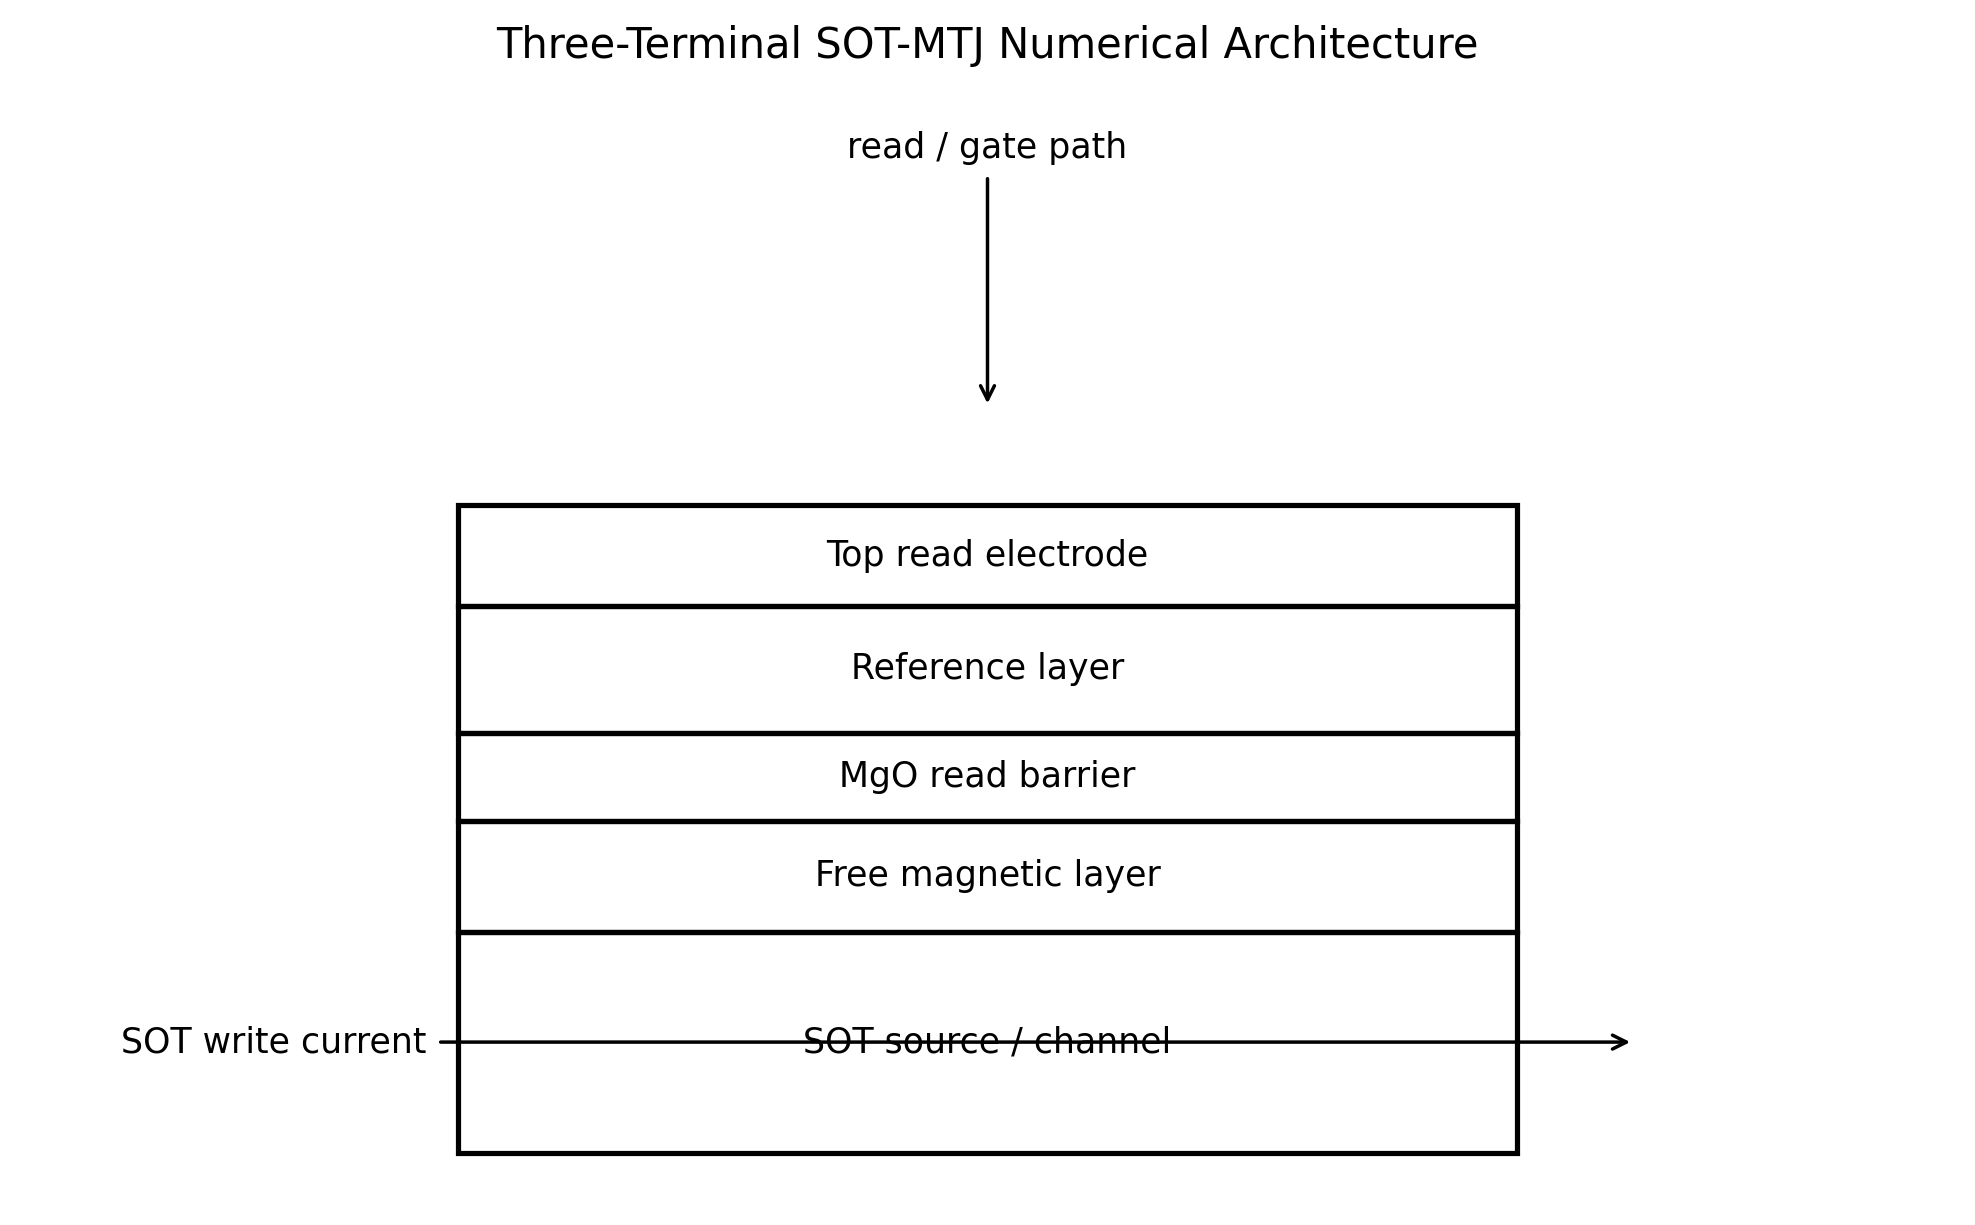

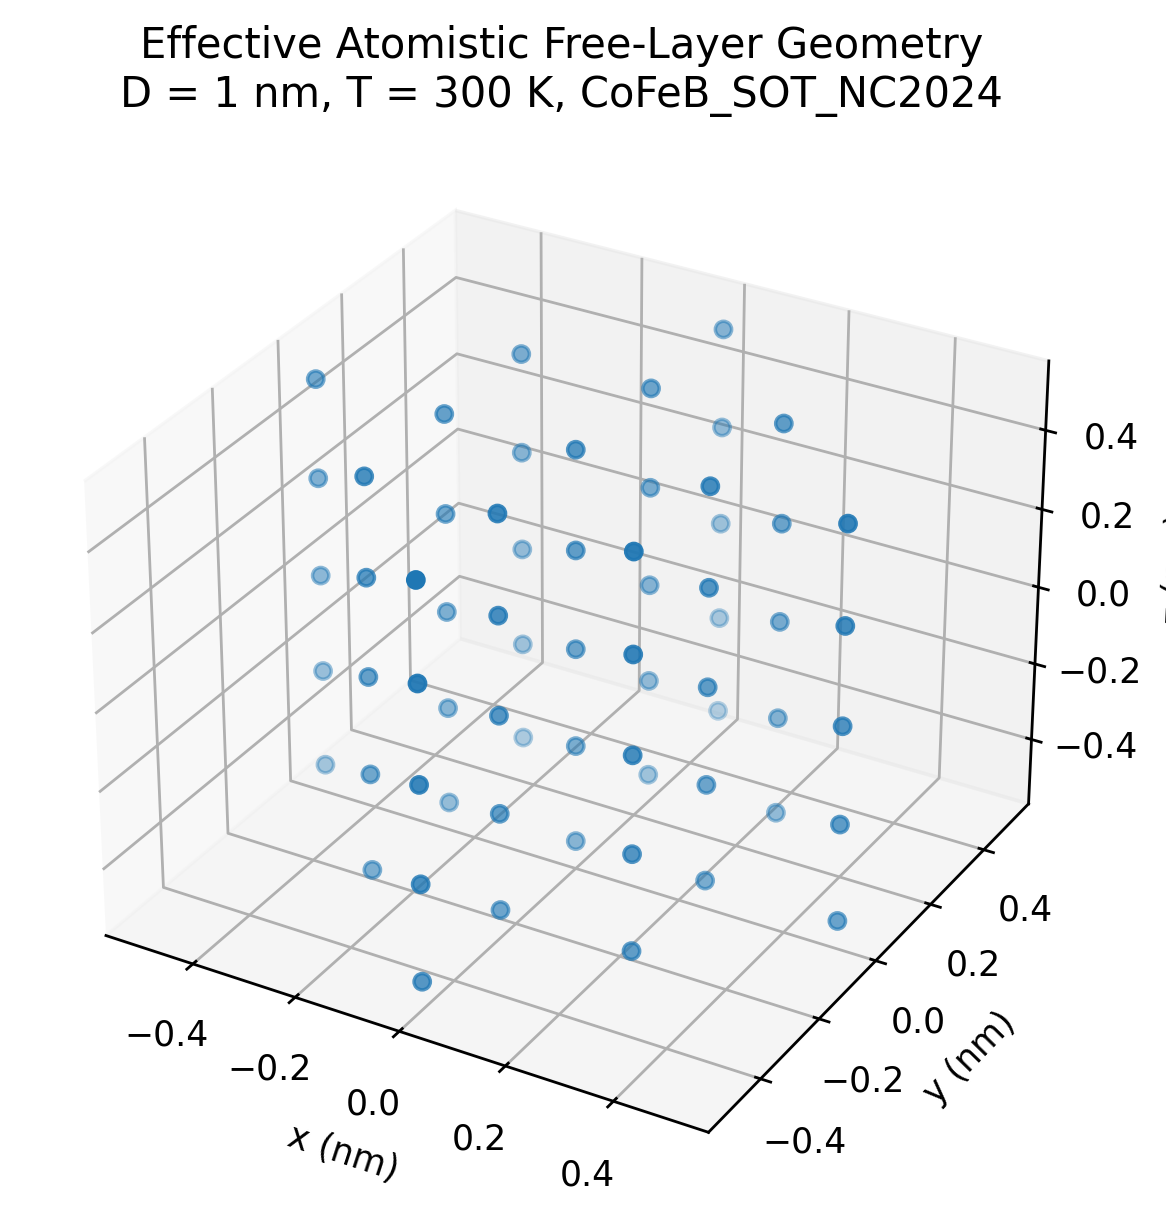

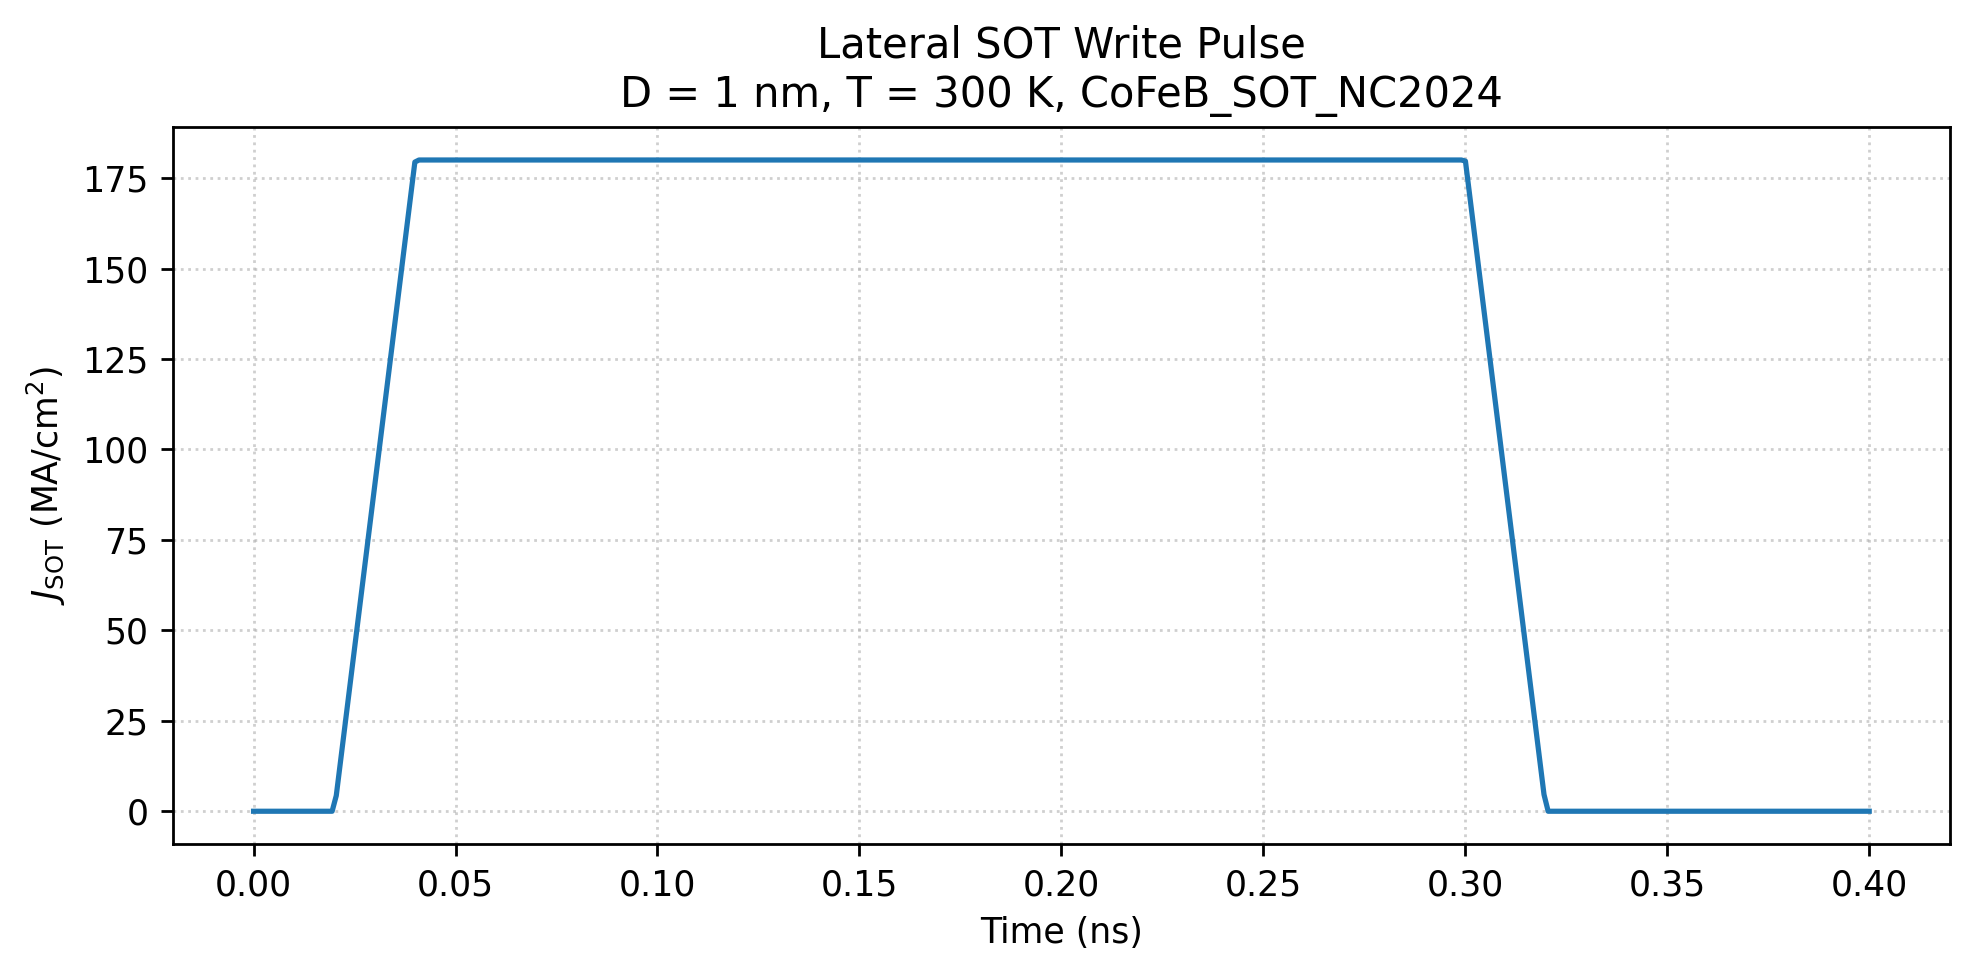

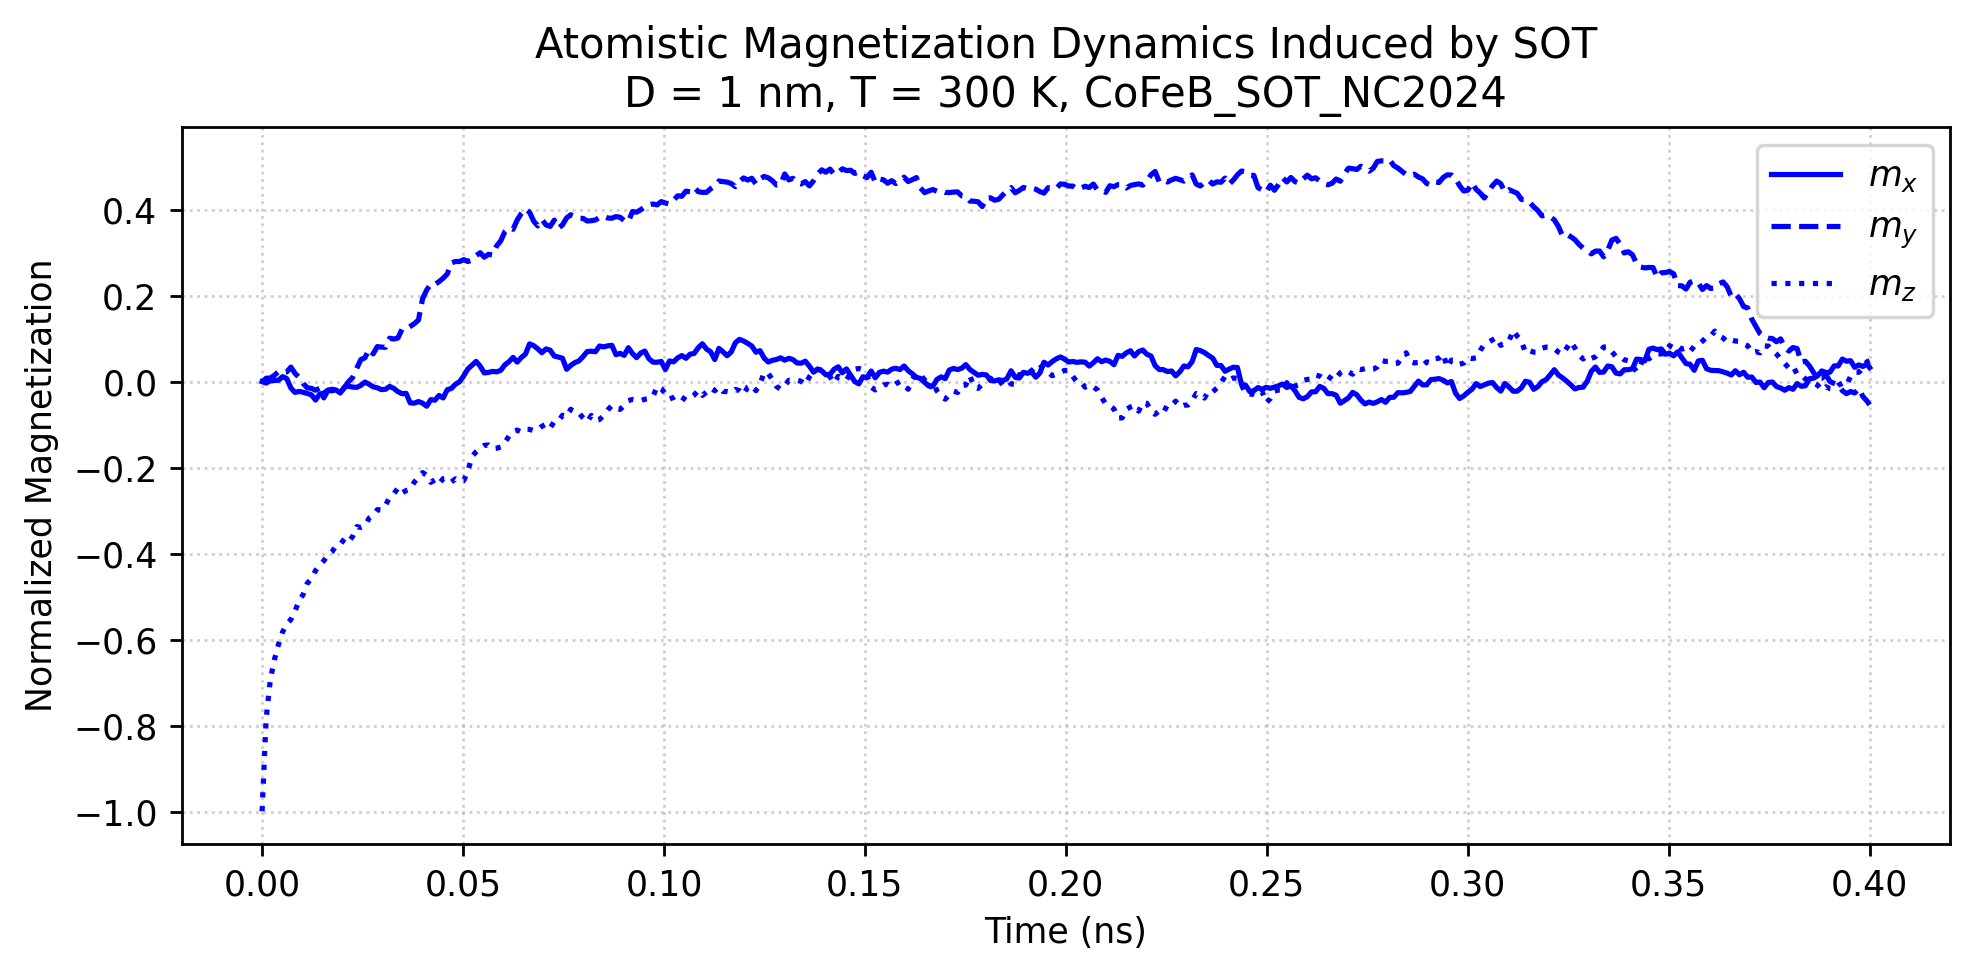

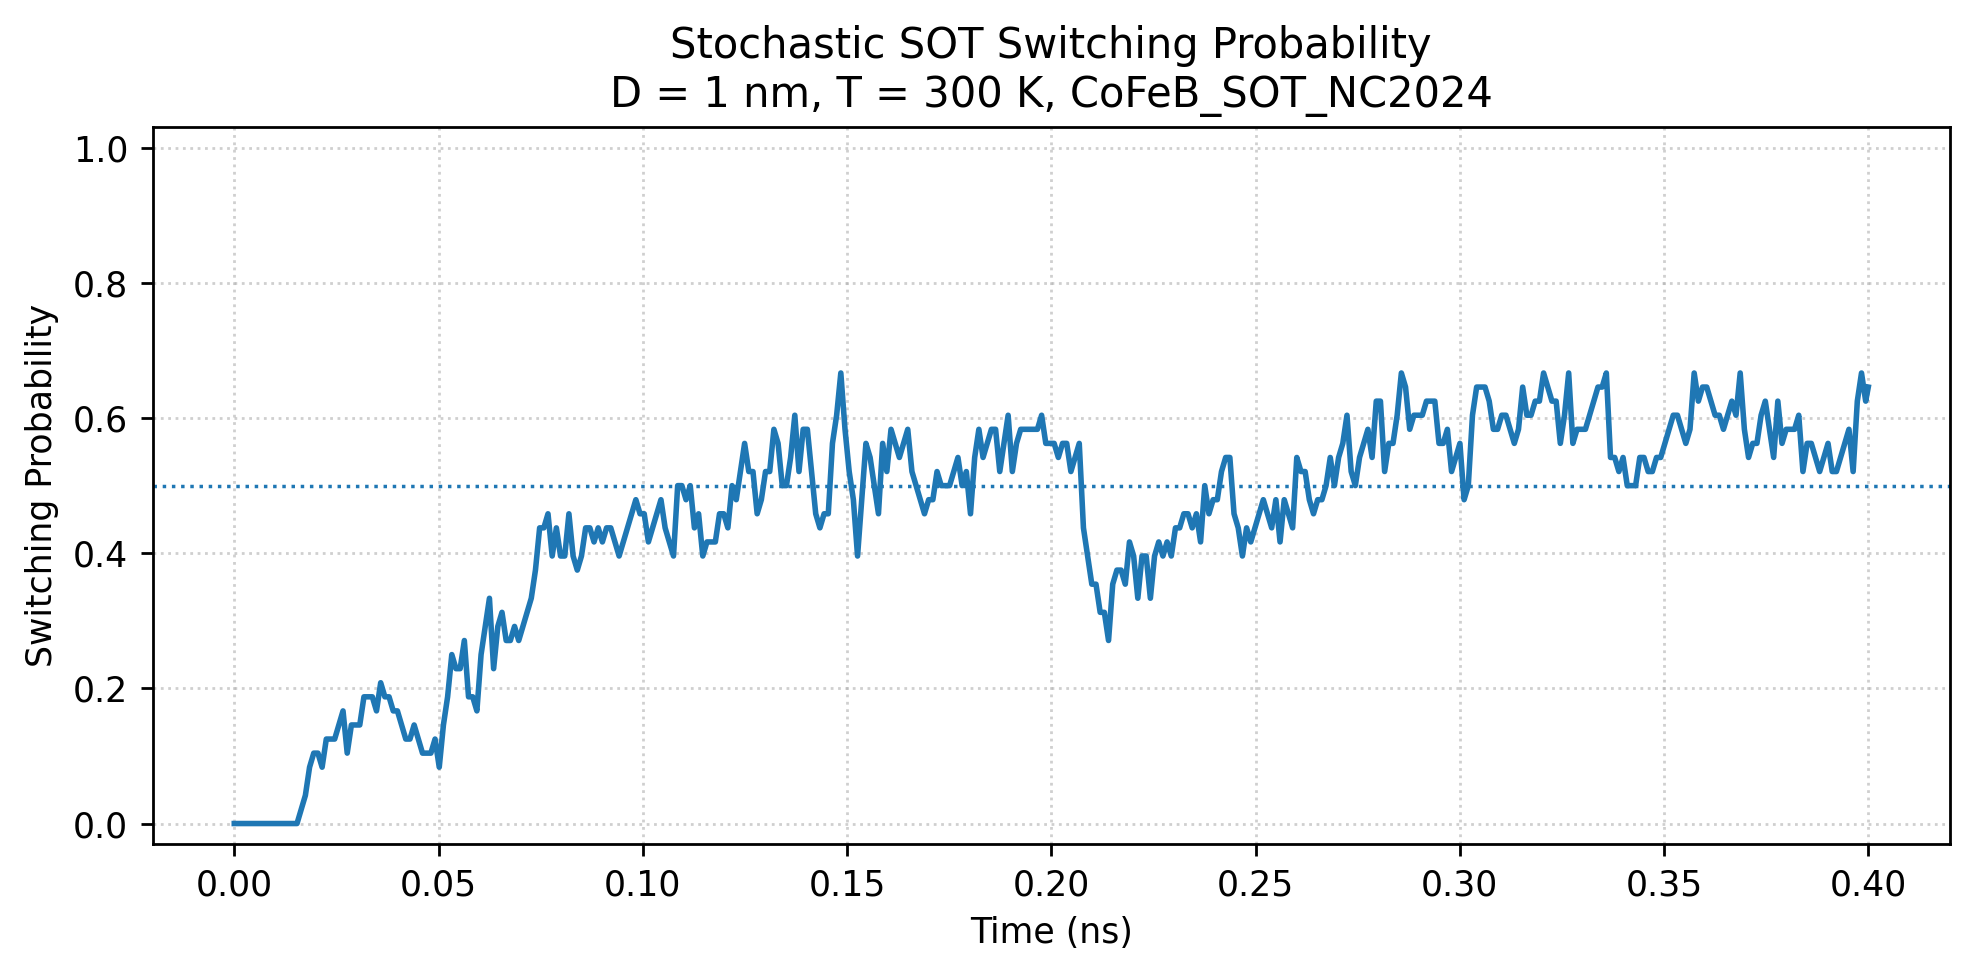

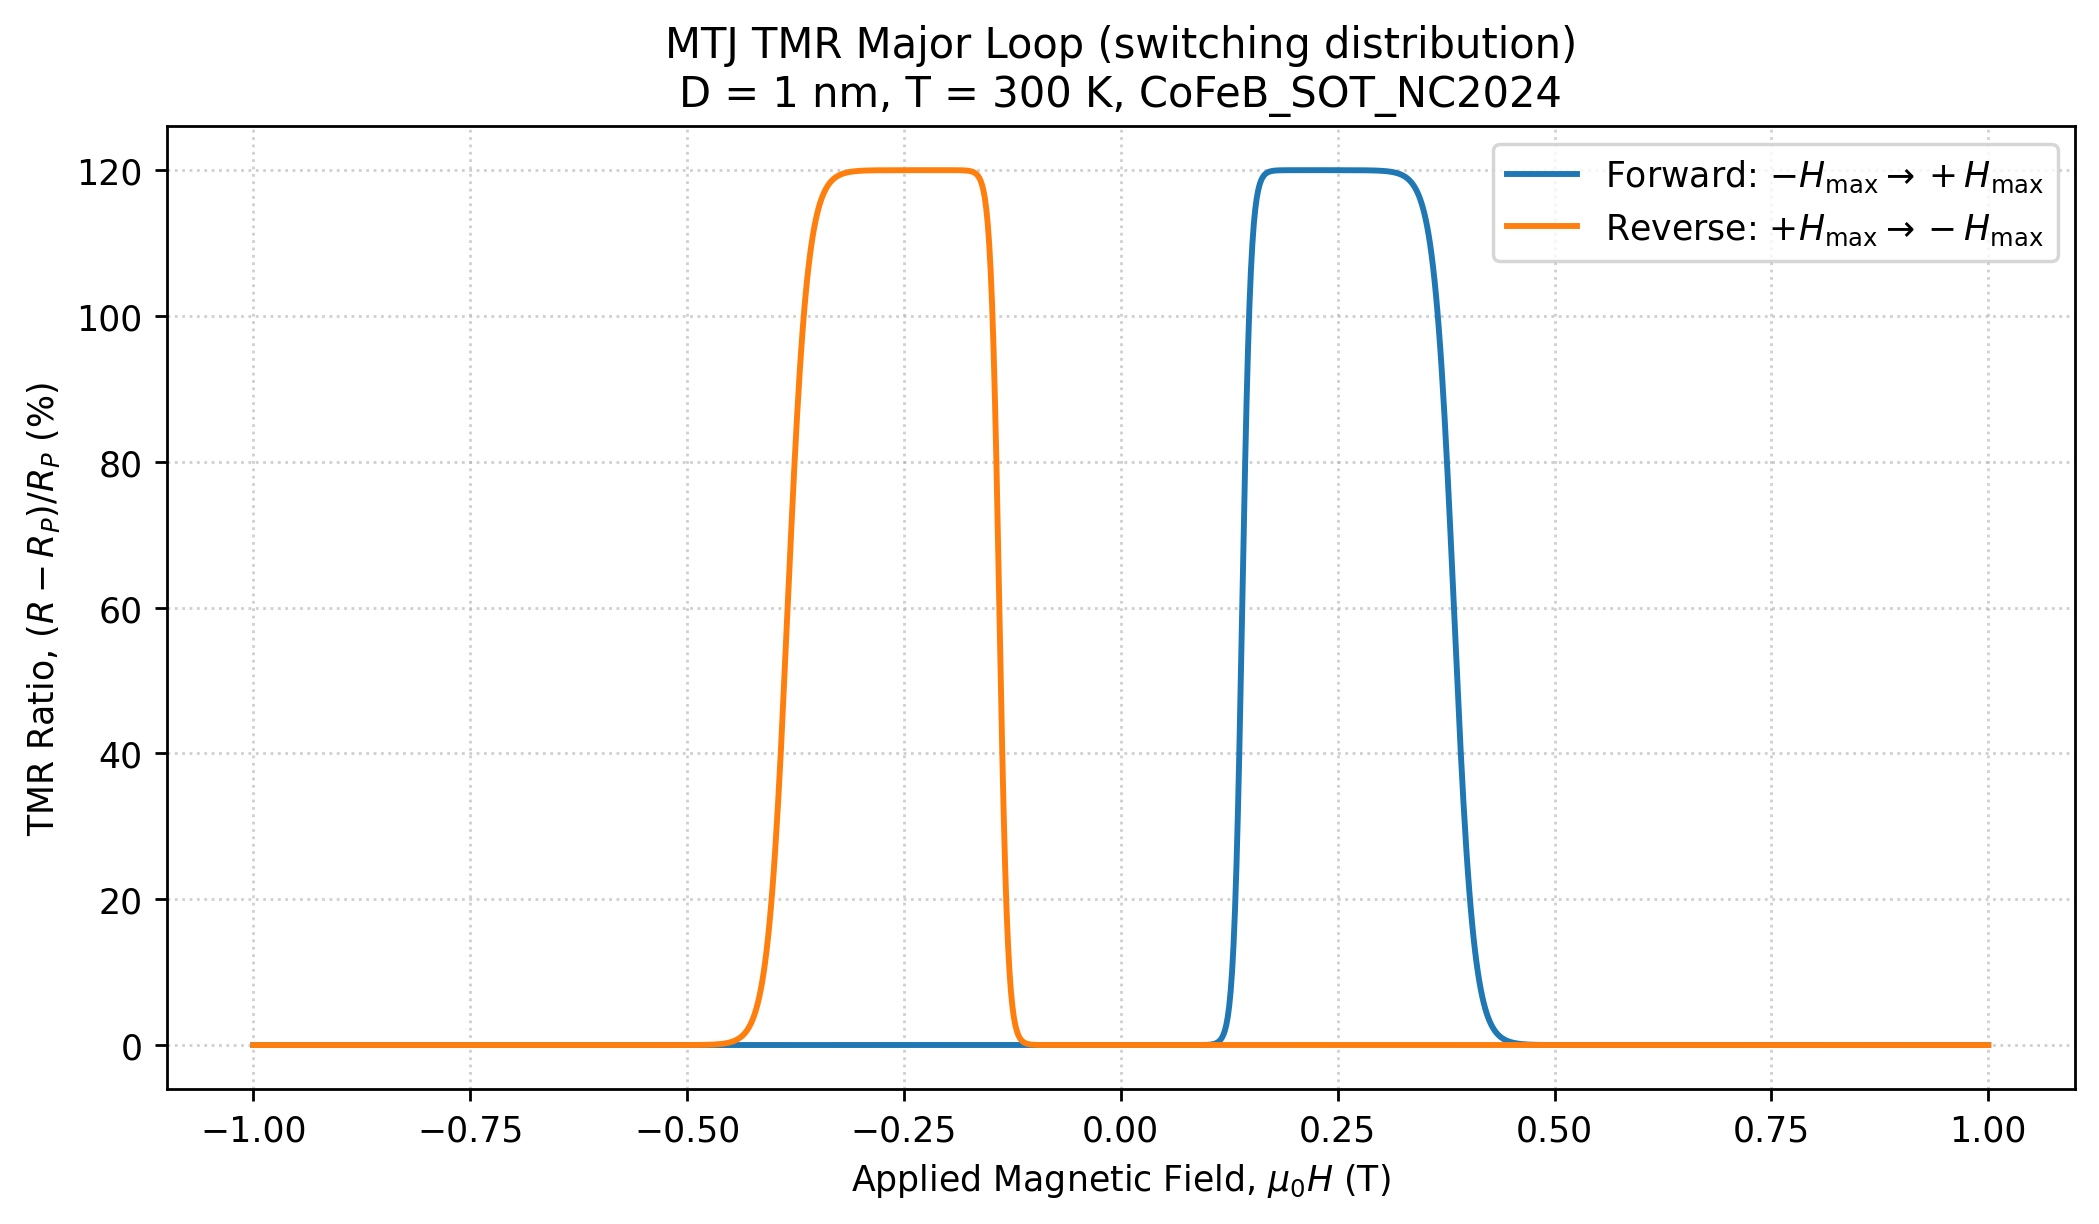

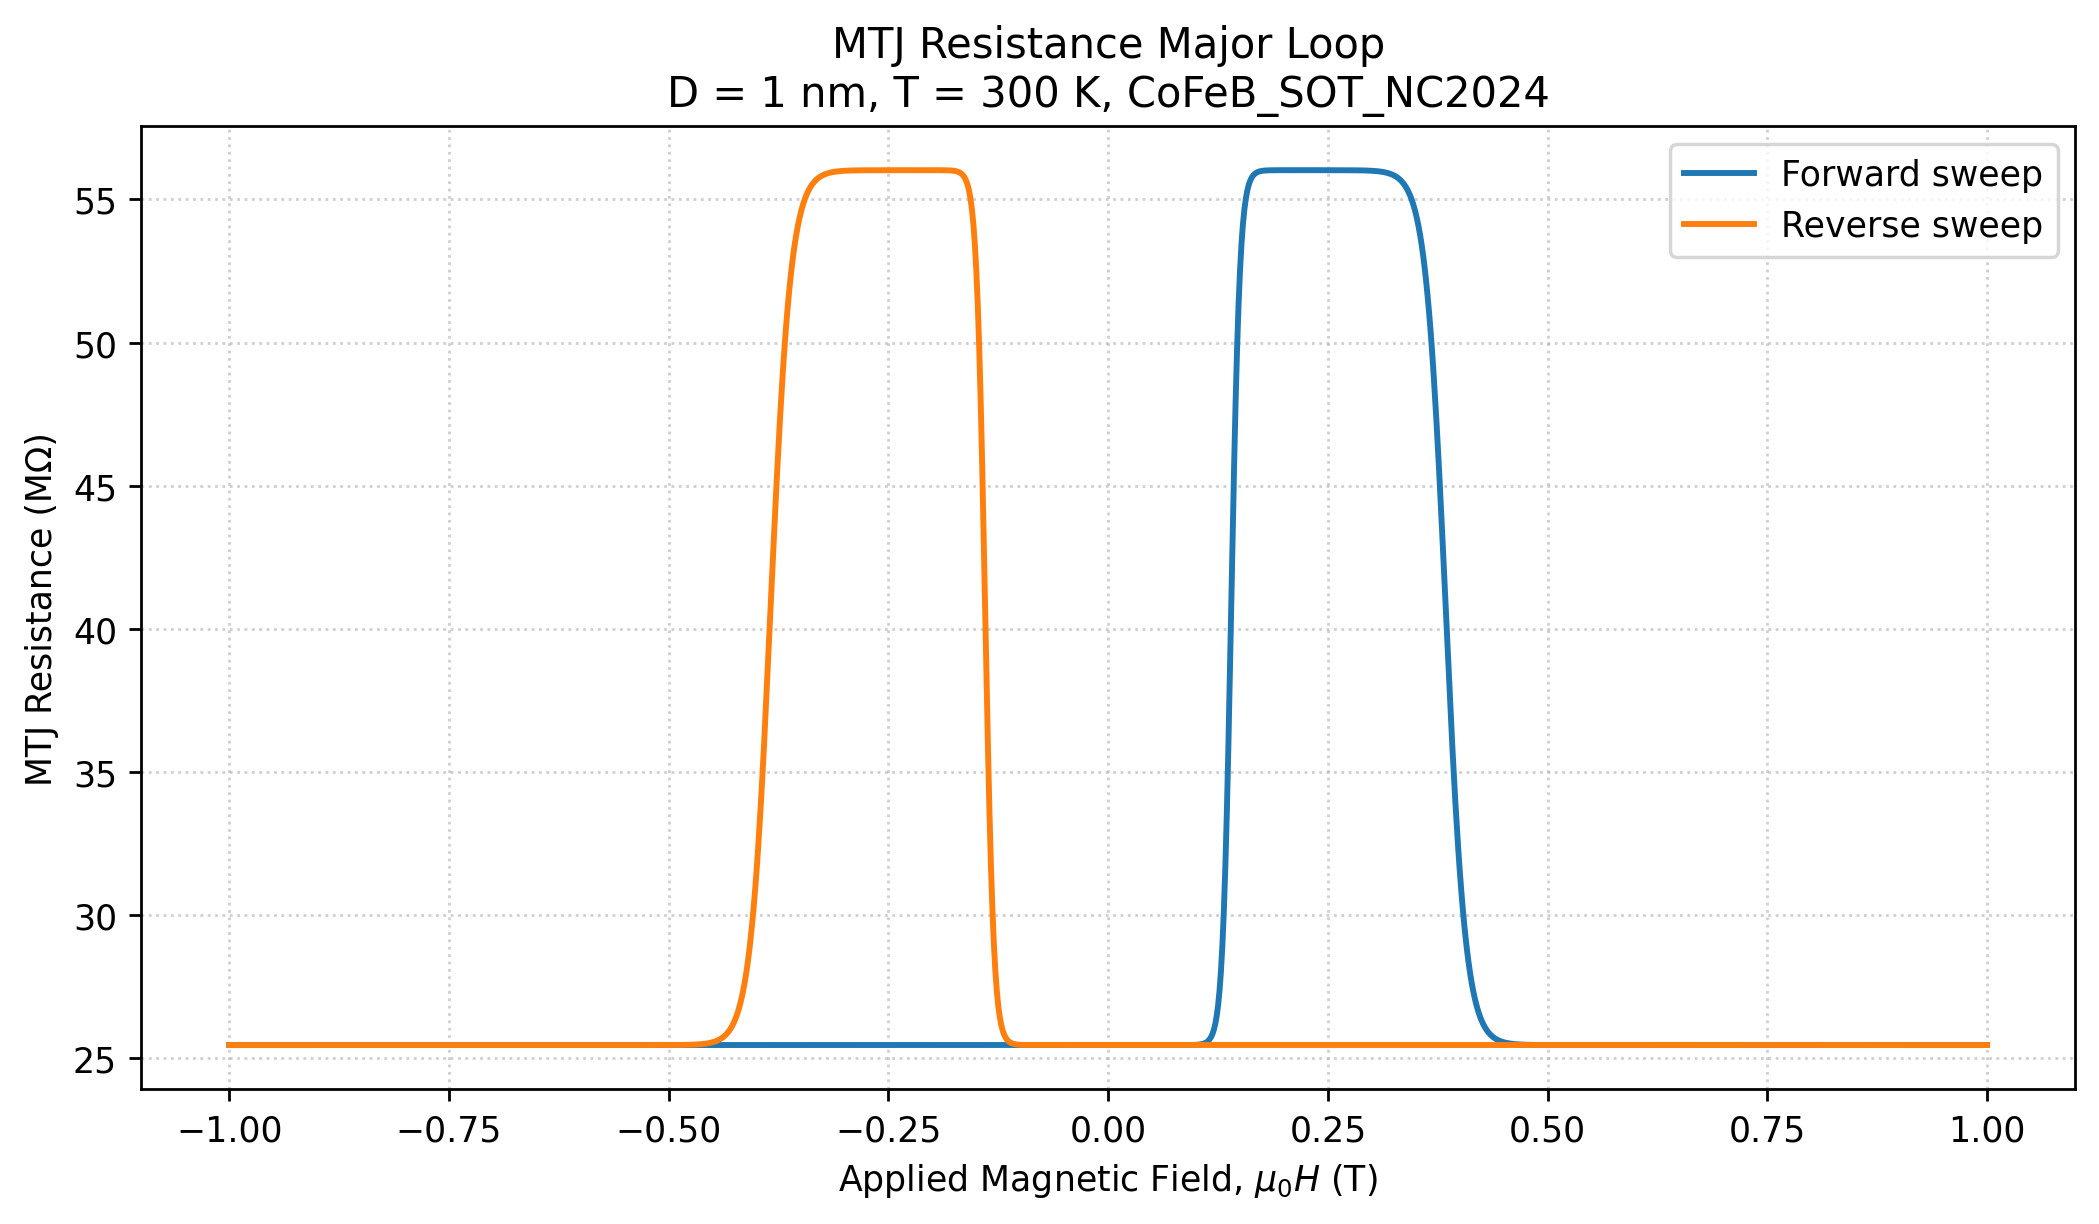

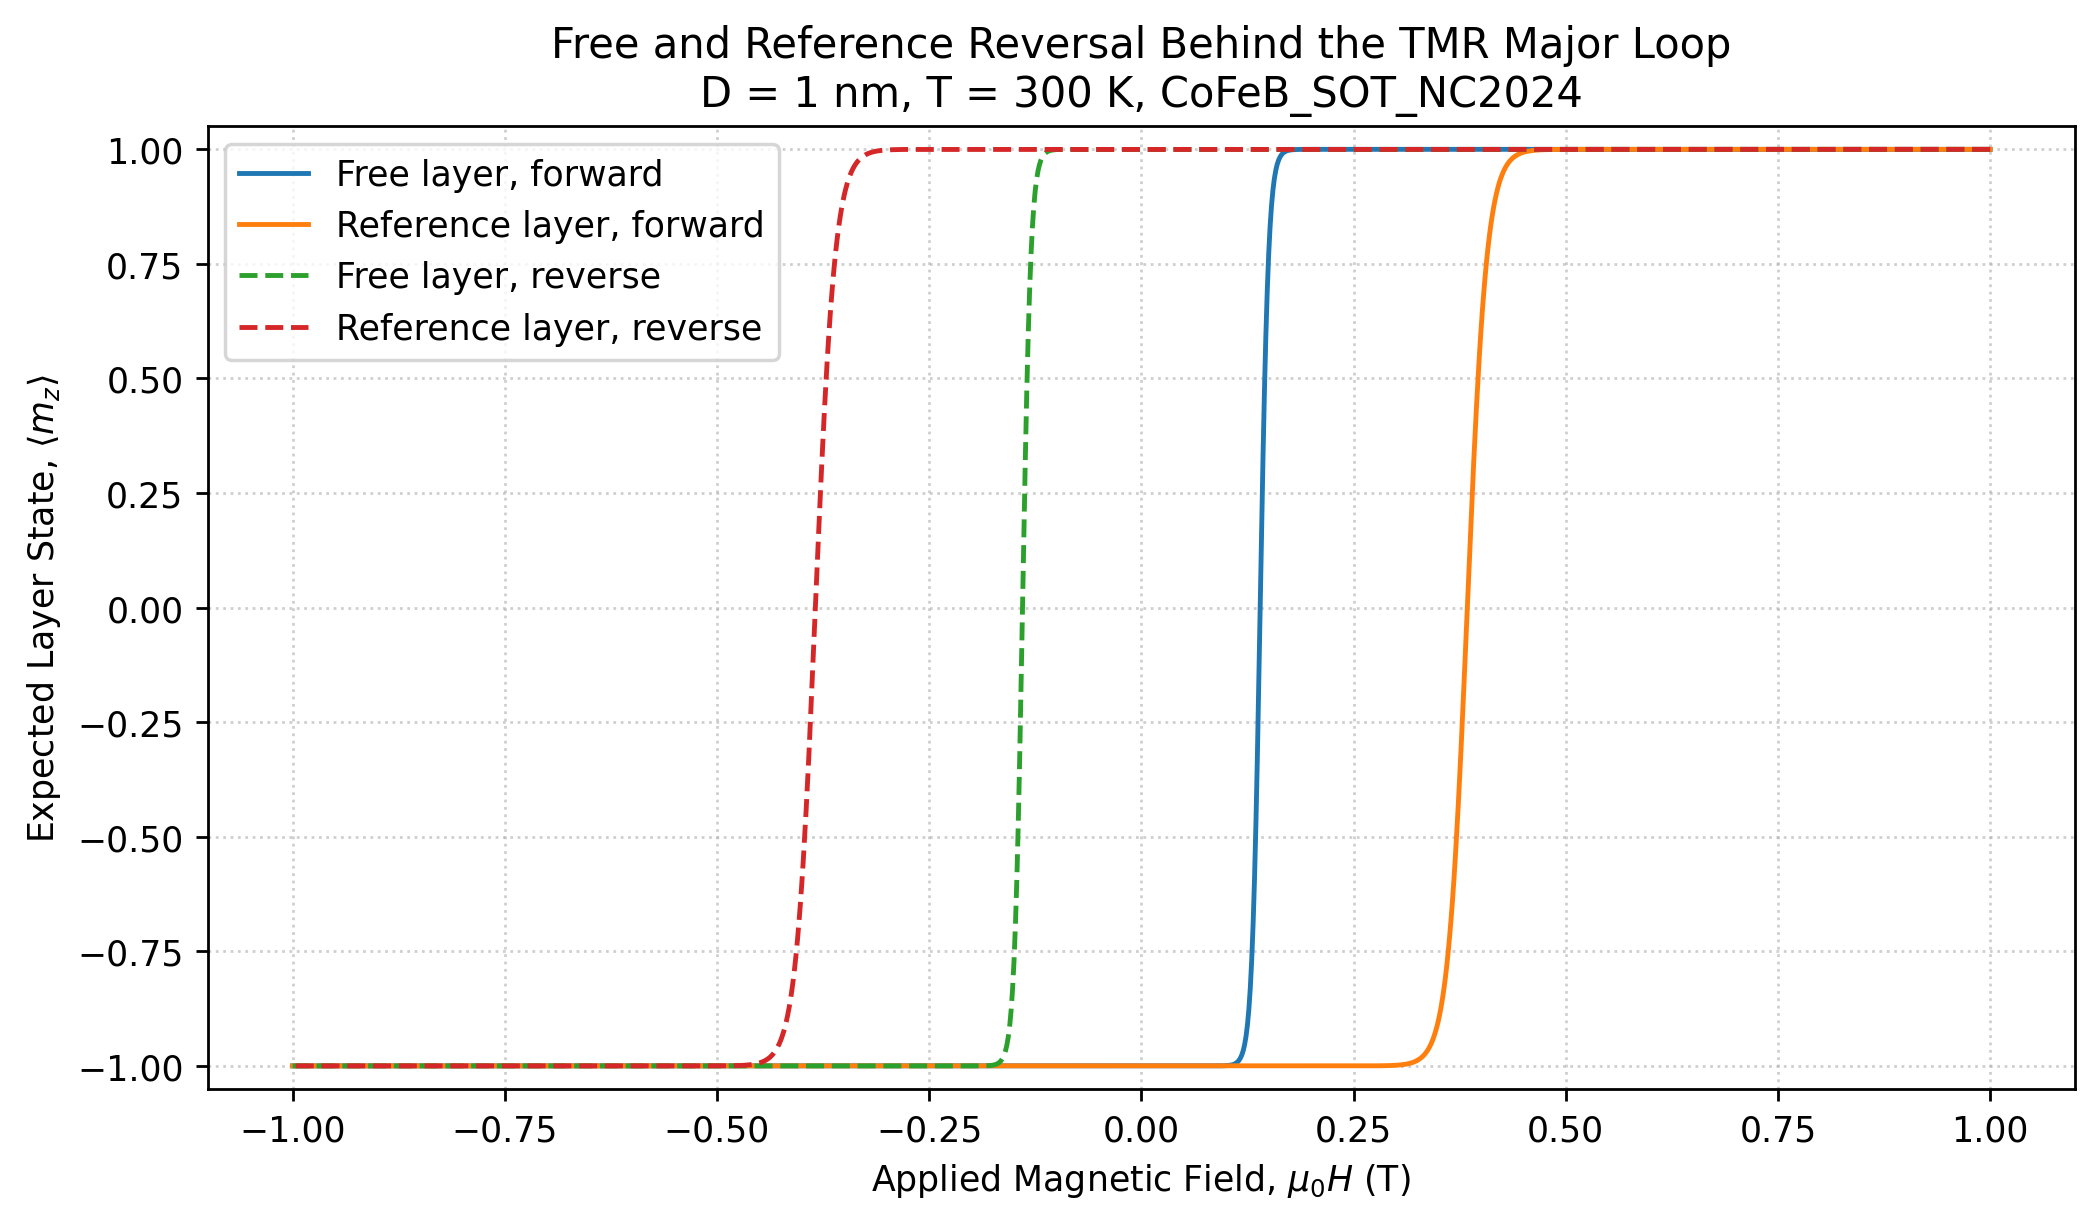

Major-loop fields: Hc_free=0.14 T, Hc_ref=0.384 T, Hk_free=0.4 T, Hk_ref=0.6 T


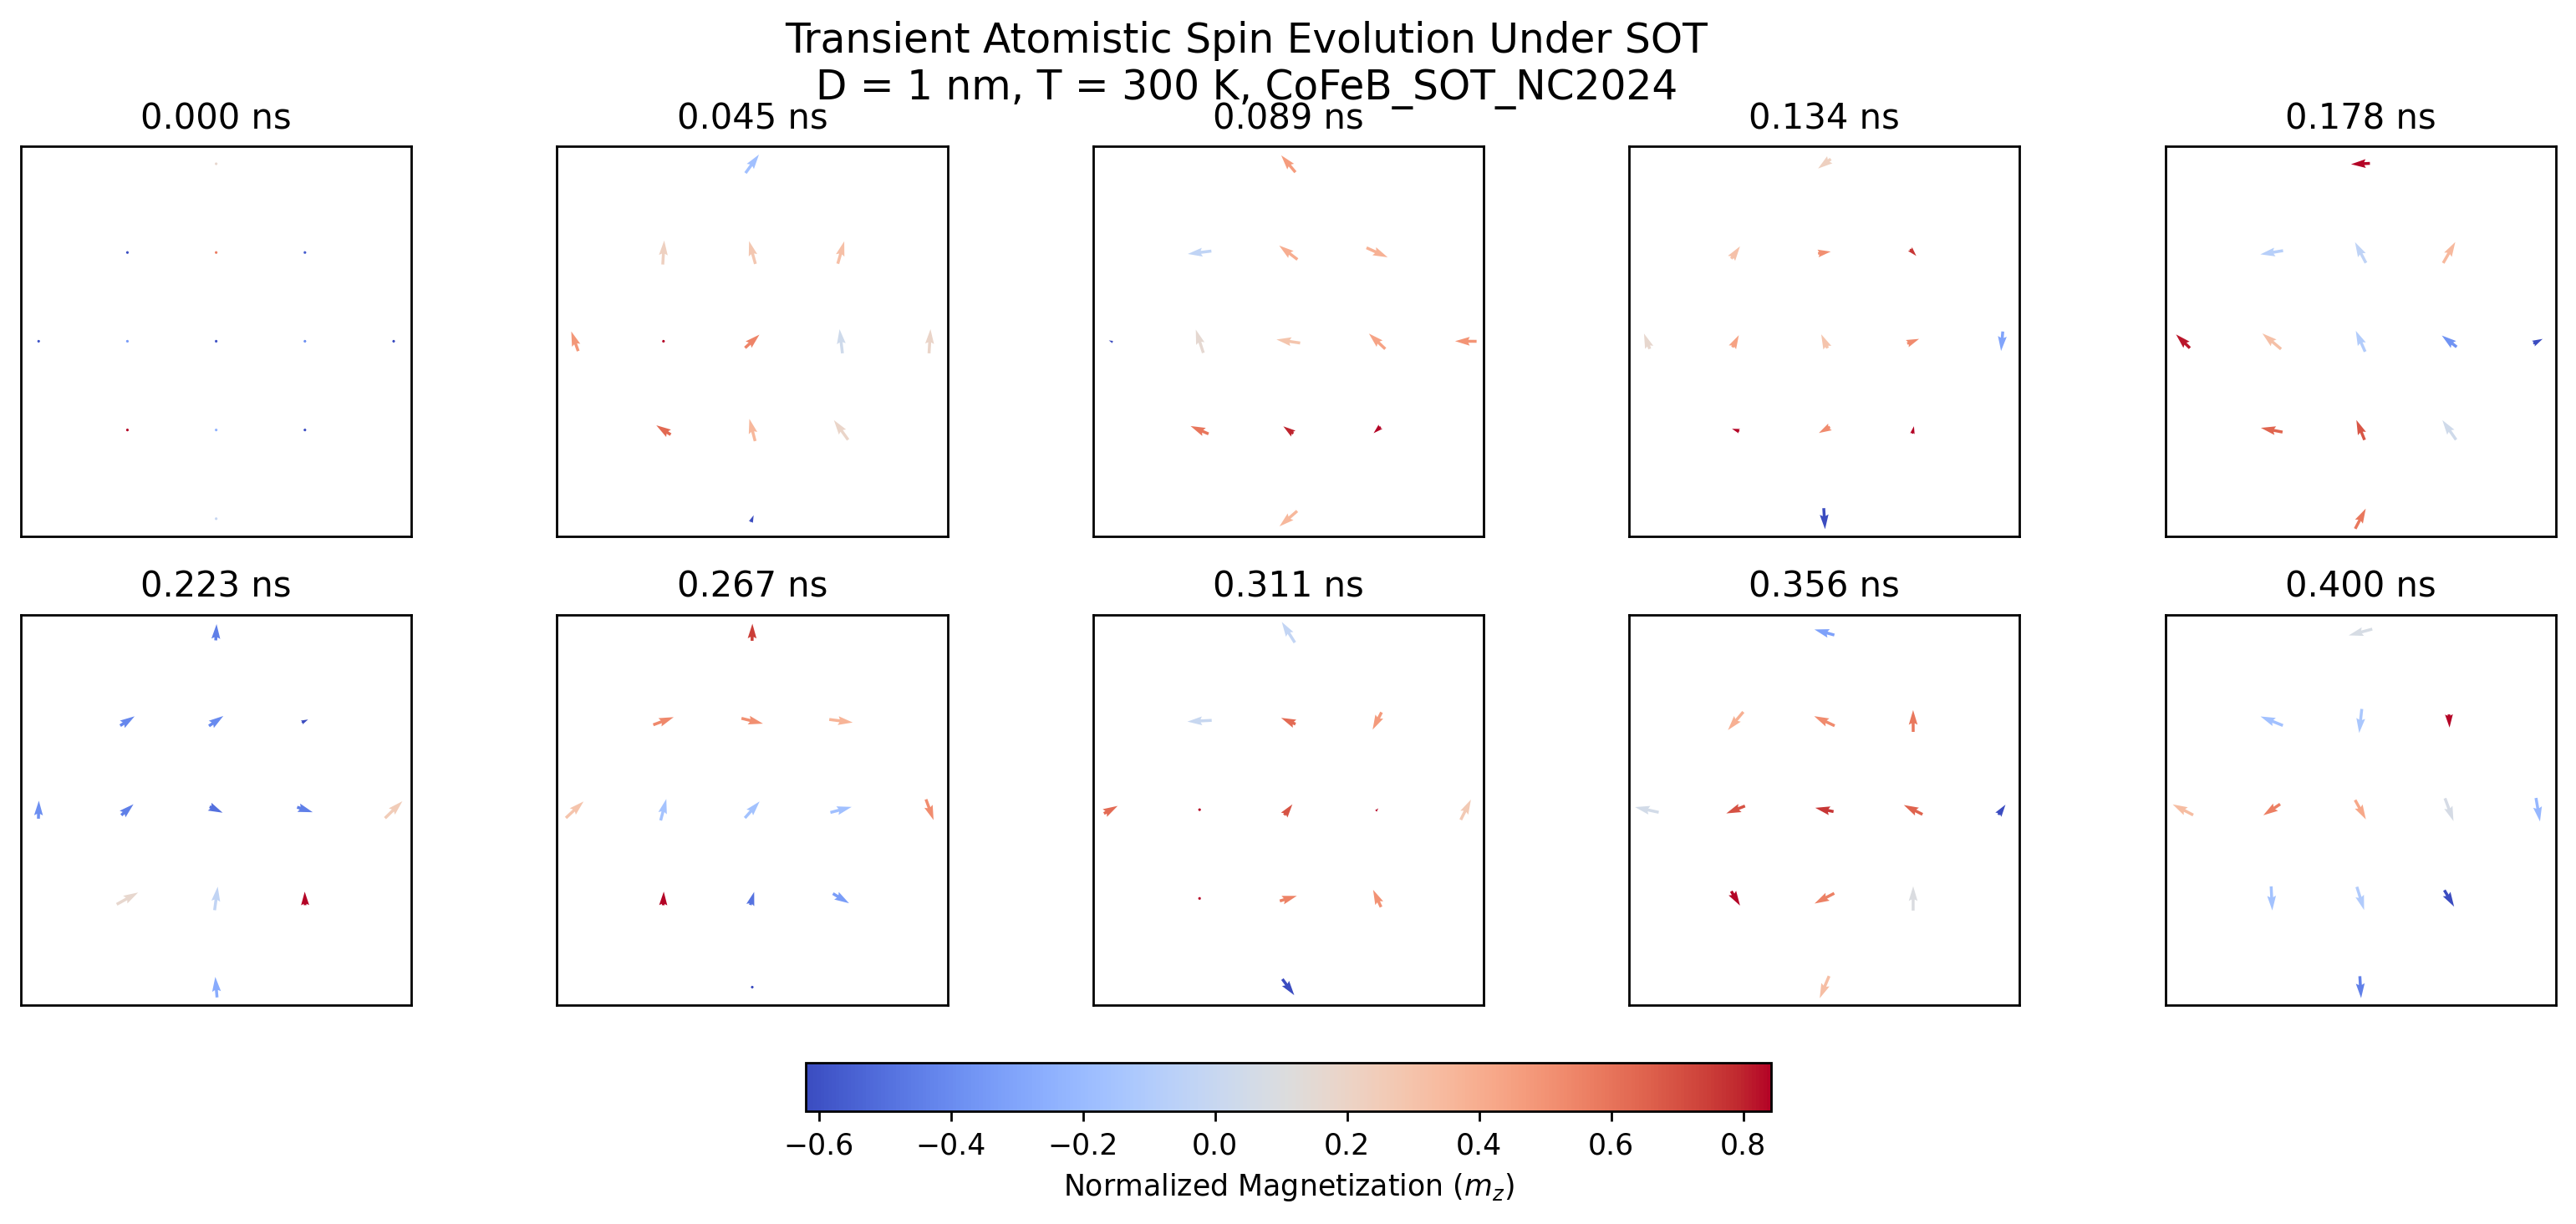

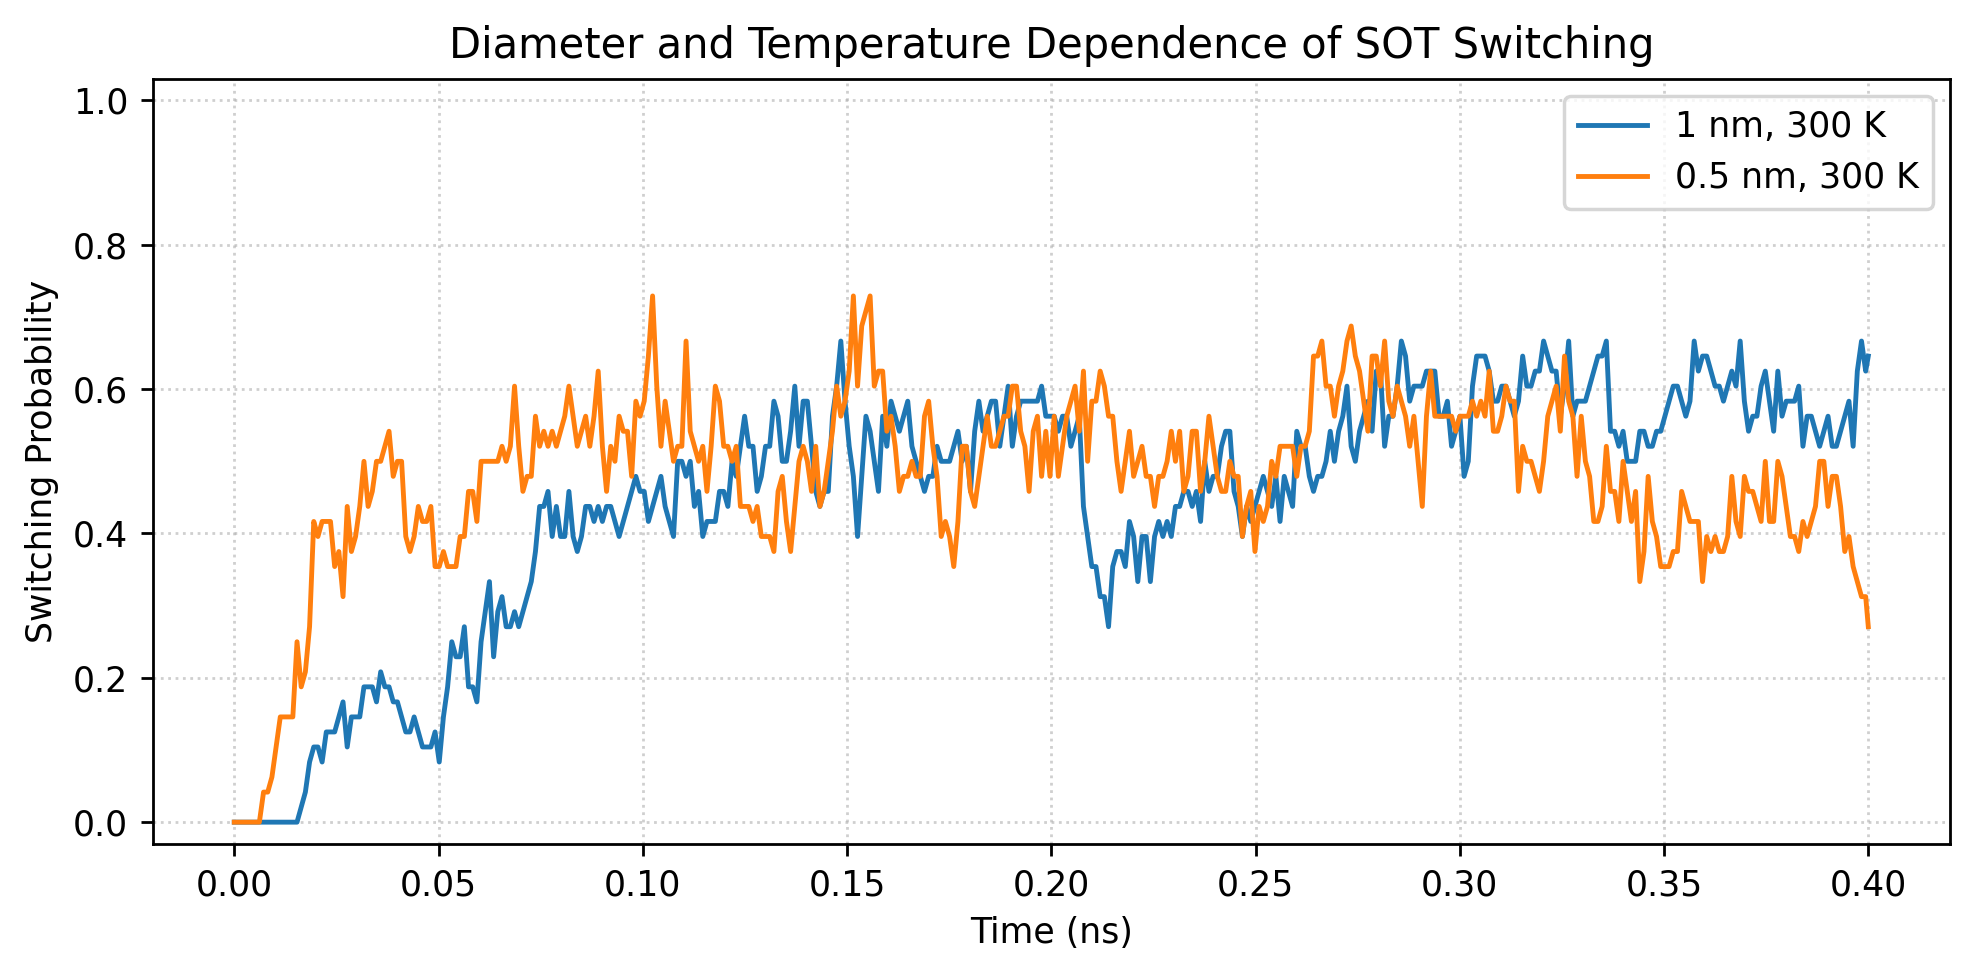

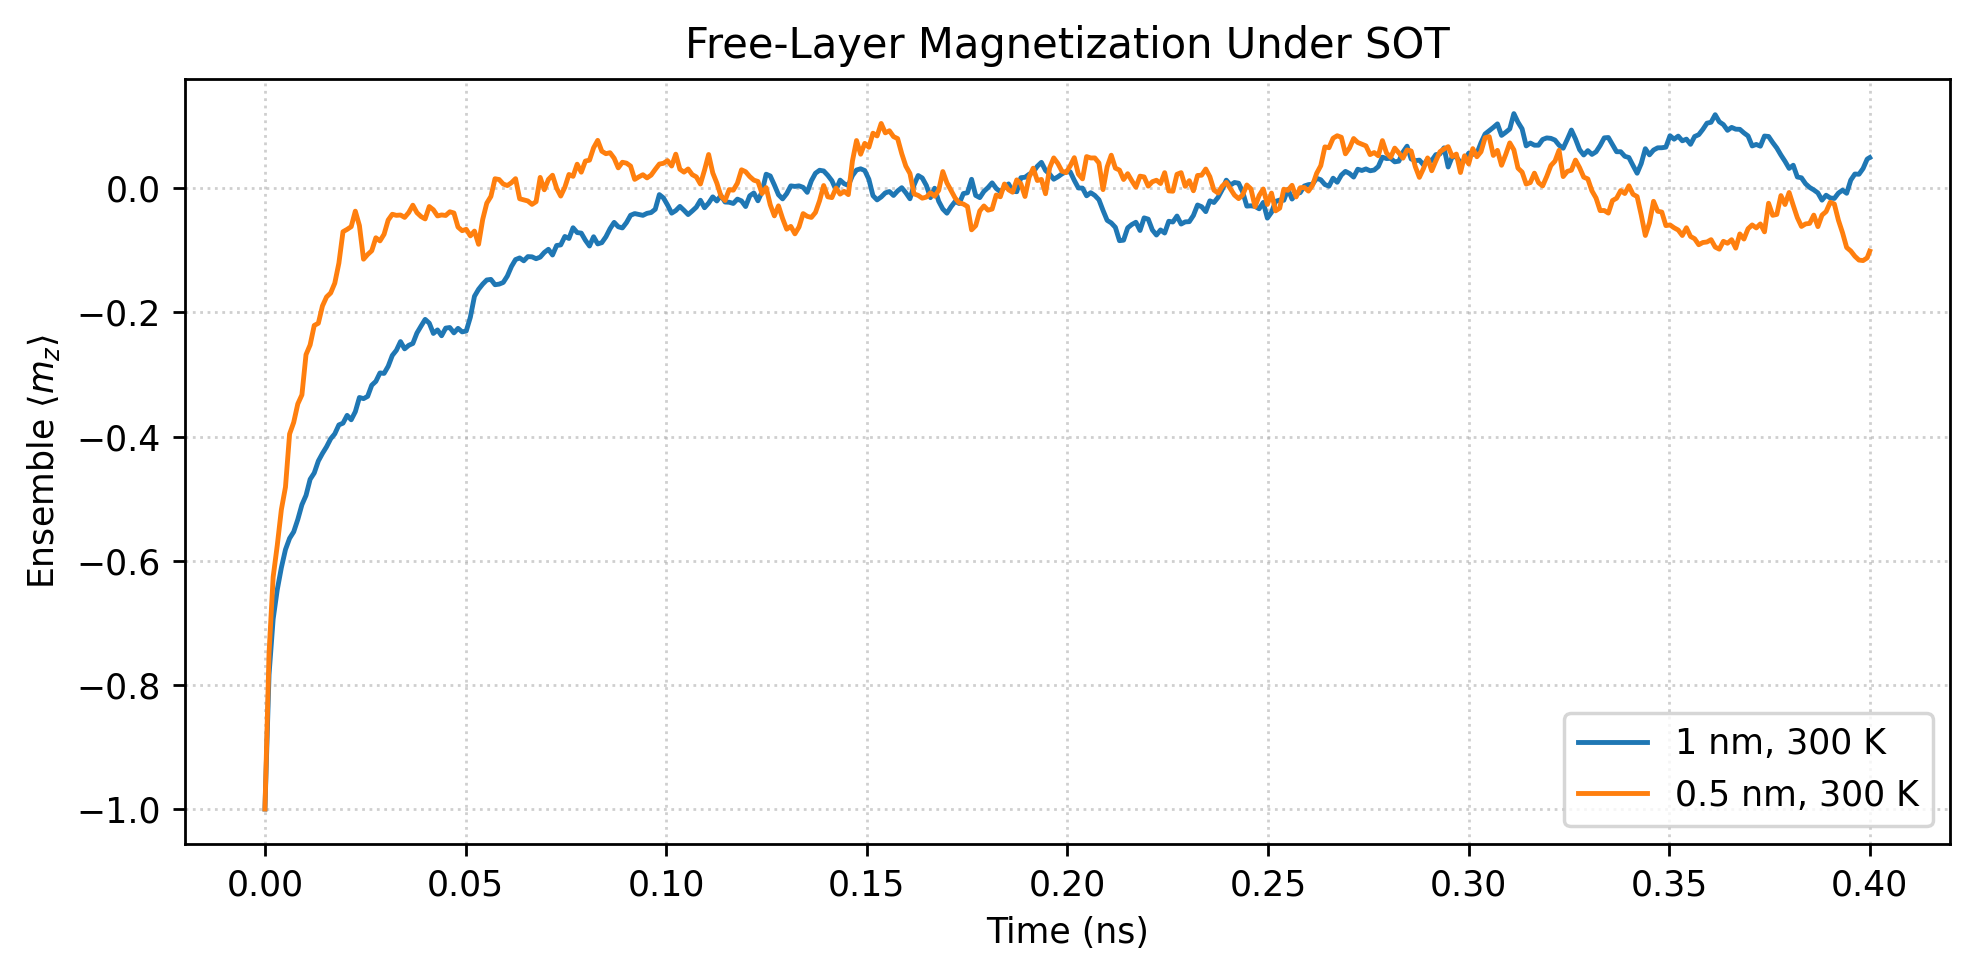

In [2]:
"""GPU atomistic SOT solver for extrapolative sub-nanometer MTJ studies."""

import math
import time
from dataclasses import dataclass
from typing import Any

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------

FIGURE_RESOLUTION_DPI = 250
FONT_FAMILY_PREFERENCE = ["Tahoma", "DejaVu Sans"]
FONT_WEIGHT_PREFERENCE = "normal"

# Extrapolative device sweep. The attached CoFeB study experimentally
# fabricated devices down to 2 nm, so these values lie below its device range.
DEVICE_DIAMETERS_NM = [1.0, 0.5]
TEMPERATURES_K = [300.0]  # Examples: [300.0, 77.0, 4.0]

# Select the independently configurable read stack and free layer.
FREE_LAYER_MATERIAL = "CoFeB_SOT_NC2024"
REFERENCE_LAYER_MATERIAL = "CoFeB_REFERENCE"
TUNNEL_BARRIER = "MgO_VGSOT_PROJECTED"

# Select the lateral SOT switching channel.
SOT_CHANNEL = "CoFeB_Ti_CoFeB_FIELD_FREE"

# Free-layer geometry. A 1 nm thickness matches the CoFeB/Ti/CoFeB
# field-free SOT simulation parameters in the supplied Nature Communications
# article.
FREE_LAYER_THICKNESS_NM = 1.0

# Stochastic atomistic integration.
RUN_TIME_NS = 0.40
DT_FS = 0.25
N_TRAJECTORIES = 48
INTEGRATION_BLOCK_STEPS = 2048
RECORD_EVERY_BLOCKS = 2
RANDOM_SEED = 31

# Initial and target states are defined relative to the +z read reference.
START_STATE = "AP"  # "AP" or "P"
TARGET_STATE = "P"  # "P" or "AP"
INITIAL_TILT_STD = 0.025
SWITCH_THRESHOLD_MZ = 0.0

# SOT pulse.
# 78.15 MA/cm^2 is retained below as the large-device experimental benchmark.
# A 1 nm coherent spin cluster lacks the domain-nucleation pathway of the
# source device, so a stronger extrapolative drive is used as the default.
SOURCE_BENCHMARK_SOT_CURRENT_MA_CM2 = 78.15
SOT_CURRENT_DENSITY_MA_CM2 = 180.0
SOT_PULSE_START_NS = 0.02
SOT_PULSE_WIDTH_NS = 0.30
SOT_RISE_FALL_NS = 0.02
SOT_SIGN_OVERRIDE = None

# Override a channel preset only if desired.
CUSTOM_SOT_EFFICIENCY = None
CUSTOM_SPIN_POLARIZATION_ANGLE_DEG = None
SOT_FIELD_LIKE_RATIO = 0.0

# Optional gate assistance. Accepted values:
# "none", "vcec", "vcma", "vcec+vcma".
ASSIST_MODE = "none"
GATE_VOLTAGE_V = 0.80
GATE_PULSE_START_NS = 0.02
GATE_PULSE_WIDTH_NS = 0.30
GATE_RISE_FALL_NS = 0.02

# Source-supported VCEC compact-model parameters.
VCEC_A_J_M2 = 1.0e-5
VCEC_B_J_M2_PER_V = 9.0e-5
VCEC_PARTNER_VECTOR = (0.0, 0.0, 1.0)
VCEC_INCLUDE_STATIC_A = True

# Source-supported VCEC/VCMA parameter from the Nano Letters experiment.
VCMA_COEFFICIENT_FJ_PER_VM = 117.0
VCEC_MGO_THICKNESS_NM = 2.0

# External magnetic field. The field-free SOT preset uses zero field.
EXTERNAL_FIELD_T = (0.0, 0.0, 0.0)

# Atomistic terms.
INCLUDE_DIPOLE_FIELD = False
AEX_SCALE = 1.0

# Optional equilibrium preparation.
USE_METROPOLIS_PRETHERMALIZATION = False
MC_SWEEPS = 60
MC_PROPOSAL_STD = 0.12

# Readout and TMR.
TMR_MODEL = "fixed"  # "fixed" or "julliere"
FIXED_TMR_RATIO = 1.20

# TMR major-loop controls.
#
# The switching-distribution model reproduces a conventional MTJ major loop
# with separate soft/free and hard/reference reversals.  The thermal-kinetic
# option is retained to expose superparamagnetic collapse at extreme scaling.
MAJOR_LOOP_MODEL = "switching_distribution"

FIELD_SWEEP_MAX_T = 1.00
FIELD_SWEEP_POINTS = 1201
FIELD_SWEEP_DWELL_NS = 1.00
FIELD_SWEEP_ATTEMPT_FREQUENCY_HZ = 1.0e9
FIELD_SWEEP_GATE_VOLTAGE_V = 0.0
FIELD_SWEEP_PLOT_RESISTANCE = True
FIELD_SWEEP_PLOT_LAYER_STATES = True
AUTO_EXPAND_FIELD_SWEEP = True

# Effective reference layer for the read major loop.
REFERENCE_LAYER_THICKNESS_NM = 1.30
REFERENCE_LAYER_DIAMETER_SCALE = 1.00
REFERENCE_LAYER_KU_SCALE = 1.00

FREE_LAYER_HC_FRACTION_OF_HK = 0.35
REFERENCE_LAYER_HC_FRACTION_OF_HK = 0.64
FREE_LAYER_SWITCH_WIDTH_FRACTION = 0.035
REFERENCE_LAYER_SWITCH_WIDTH_FRACTION = 0.030
MIN_SWITCH_WIDTH_T = 0.002

FREE_LAYER_HC_OVERRIDE_T = None
REFERENCE_LAYER_HC_OVERRIDE_T = None

# Optional measurement-like resistance noise applied after the magnetic
# state probabilities have been simulated.
ADD_TMR_NOISE = False
TMR_NOISE_SIGMA_FRACTION = 0.010

# Optional write-energy estimate. The default field-free CoFeB/Ti/CoFeB
# article does not supply a channel resistivity, so energy is left undefined
# unless this override is supplied.
CUSTOM_SOT_RESISTIVITY_UOHM_CM = None
SOT_ACTIVE_WIDTH_NM = 10.0
SOT_ACTIVE_LENGTH_NM = 20.0

# Plot controls.
SNAPSHOT_ROWS = 2
SNAPSHOT_COLUMNS = 5
MAX_SNAPSHOTS = 10
MAGNETIZATION_COLOR_DIRECTION = "M_Z"
QUIVER_ARROW_SCALE = 16.0
DETAILED_PLOT_CASE = (1.0, 300.0)

# Optional current/pulse sweep. This can be expensive at atomistic time steps.
RUN_SWITCHING_MAP = False
SWEEP_DIAMETER_NM = 1.0
SWEEP_TEMPERATURE_K = 300.0
SWEEP_CURRENT_DENSITIES_MA_CM2 = [30.0, 45.0, 60.0, 78.15, 95.0]
SWEEP_PULSE_WIDTHS_NS = [0.10, 0.20, 0.30, 0.40]
SWEEP_TRAJECTORIES = 24


# ---------------------------------------------------
# Physical Constants
# ---------------------------------------------------

MU0 = 4.0e-7 * math.pi
K_B = 1.380649e-23
HBAR = 1.054571817e-34
E_CHARGE = 1.602176634e-19
GAMMA = 1.76085963023e11  # rad s^-1 T^-1
MU_B = 9.2740100657e-24


# ---------------------------------------------------
# Material, Read-Barrier, and SOT-Channel Catalogs
# ---------------------------------------------------

MATERIALS: dict[str, dict[str, Any]] = {
    "CoFeB_SOT_NC2024": {
        "label": "CoFeB PMA free layer, NC 2024 SOT preset",
        "ms_model": "constant",
        "ms_a_m": 1.0e6,
        "alpha": 0.005,
        "polarization": 0.40,
        "ku_ref_j_m3": 0.5 * 1.0e6 * 0.400,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 0.0,
        "a_xy_nm": 0.25,
        "a_z_nm": 0.25,
        "aex_j_m": 1.0e-11,
        "nominal_tmr_ratio": None,
        "source": (
            "Nature Communications 2024 SOT simulation: tF=1 nm, "
            "Ms=1000 emu/cm^3, Aex=1e-6 erg/cm, mu0 Hk,eff=400 mT, "
            "thetaDL=0.3, alpha=0.005. Effective lattice spacing and "
            "read polarization are explicit calibration placeholders."
        ),
    },
    "CoFeB_HEXA2": {
        "label": "CoFeB, HEXA(2)-like",
        "ms_model": "cofeb_bloch",
        "mu0_ms_0_t": 1.59,
        "bloch_a_k_m32": 2.47e-5,
        "alpha": 0.0139,
        "polarization": 0.40,
        "ku_ref_j_m3": 3.57e5,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 3.0,
        "a_xy_nm": 0.25,
        "a_z_nm": 0.25,
        "aex_j_m": 15.0e-12,
        "nominal_tmr_ratio": None,
        "source": (
            "npj Spintronics 2024: CoFeB temperature law and fitted "
            "alpha=0.0139; P=0.4 is the paper's design value. "
            "Aex and effective site spacing are calibration quantities."
        ),
    },
    "L10_FePd": {
        "label": "L1_0-FePd",
        "ms_model": "constant",
        "ms_a_m": 1.10e6,
        "alpha": 0.012,
        "polarization": 0.40,
        "ku_ref_j_m3": 1.13e6,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 0.0,
        "a_xy_nm": 0.40,
        "a_z_nm": 0.382,
        "aex_j_m": 10.0e-12,
        "nominal_tmr_ratio": 0.85,
        "source": (
            "Advanced Functional Materials 2023: Ms=1.1 MA/m scaling "
            "assumption, measured Ku=1.13 MJ/m^3, alpha about 0.012, "
            "PMA maintained from 4 to 400 K. Aex and read polarization "
            "are calibration quantities."
        ),
    },
    "CoFeB_REFERENCE": {
        "label": "CoFeB fixed reference layer",
        "ms_model": "constant",
        "ms_a_m": 1.0e6,
        "alpha": 0.01,
        "polarization": 0.40,
        "ku_ref_j_m3": 3.0e5,
        "ku_ref_temp_k": 300.0,
        "ku_temp_exponent": 0.0,
        "a_xy_nm": 0.25,
        "a_z_nm": 0.25,
        "aex_j_m": 12.0e-12,
        "nominal_tmr_ratio": None,
        "source": (
            "Read-reference placeholder. P=0.4 follows the supplied "
            "CoFeB switching-design calculations."
        ),
    },
}

READ_BARRIERS: dict[str, dict[str, Any]] = {
    "MgO_VGSOT_PROJECTED": {
        "label": "MgO read barrier, projected VGSOT",
        "ra_ohm_um2": 20.0,
        "barrier_thickness_nm": 1.0,
        "source": (
            "Physical Review Applied 2021 projected scaled VGSOT: "
            "RA=20 ohm um^2 and tMgO approximately 1 nm."
        ),
    },
    "MgO_ULTRASCALED_LOW_RA": {
        "label": "MgO read barrier, ultrascaled low-RA preset",
        "ra_ohm_um2": 1.0,
        "barrier_thickness_nm": 0.94,
        "source": (
            "npj Spintronics 2024: approximately 1 ohm um^2 RA and "
            "0.93 to 0.98 nm MgO in several ultrascaled stacks."
        ),
    },
}

SOT_CHANNELS: dict[str, dict[str, Any]] = {
    "CoFeB_Ti_CoFeB_FIELD_FREE": {
        "label": "CoFeB/Ti/CoFeB field-free SOT source",
        "theta_dl": 0.30,
        "spin_polarization_angle_deg": 6.0,
        "channel_thickness_nm": 3.0,
        "resistivity_uohm_cm": None,
        "field_free": True,
        "source": (
            "Nature Communications 2024: CoFeB(4)/Ti(3)/CoFeB(1) "
            "field-free SOT; thetaDL=0.3 in simulation; experiment/simulation "
            "comparison suggests about 6 degrees of out-of-plane spin "
            "polarization. The Ti thickness is 3 nm in the best-performing "
            "reported sample."
        ),
    },
    "W_VGSOT": {
        "label": "W SOT channel with VCMA gate assistance",
        "theta_dl": -0.45,
        "spin_polarization_angle_deg": 0.0,
        "channel_thickness_nm": 3.5,
        "resistivity_uohm_cm": 160.0,
        "field_free": False,
        "source": (
            "Physical Review Applied 2021: 3.5 nm W SOT track, "
            "SOT-layer resistivity about 160 micro-ohm cm, and projected "
            "thetaSH=-0.45 for scaled VGSOT."
        ),
    },
    "CUSTOM": {
        "label": "Custom SOT channel",
        "theta_dl": 0.30,
        "spin_polarization_angle_deg": 6.0,
        "channel_thickness_nm": 3.0,
        "resistivity_uohm_cm": None,
        "field_free": True,
        "source": "User-defined calibration preset.",
    },
}


# ---------------------------------------------------
# Data Containers
# ---------------------------------------------------

@dataclass
class Geometry:
    """Store the effective atomistic cylinder and its adjacency."""

    positions_m: np.ndarray
    neighbors: np.ndarray
    a_xy_m: float
    a_z_m: float
    site_volume_m3: float


@dataclass
class CaseParameters:
    """Store all material, geometry, readout, and SOT parameters."""

    diameter_nm: float
    temperature_k: float
    geometry: Geometry
    ms_a_m: float
    alpha: float
    polarization_free: float
    polarization_ref: float
    ku0_j_m3: float
    mu_s_j_t: float
    k_site_j: float
    j_exchange_j: float
    exchange_field_scale_t: float
    anisotropy_field_scale0_t: float
    thermal_sigma_t: float
    free_thickness_m: float
    read_reference_vector: np.ndarray
    vcec_partner_vector: np.ndarray
    dipole_tensor_t: np.ndarray
    ra_ohm_m2: float
    read_area_m2: float
    rp_ohm: float
    tmr_ratio: float
    theta_dl: float
    spin_sigma: np.ndarray
    sot_field_per_current_t_m2_a: float
    sot_channel_thickness_m: float
    sot_resistivity_ohm_m: float | None


# ---------------------------------------------------
# Matplotlib Configuration
# ---------------------------------------------------

plt.rcParams["figure.dpi"] = FIGURE_RESOLUTION_DPI
plt.rcParams["font.sans-serif"] = FONT_FAMILY_PREFERENCE
plt.rcParams["font.weight"] = FONT_WEIGHT_PREFERENCE


# ---------------------------------------------------
# Material Helpers
# ---------------------------------------------------

def ms_at_temperature(material: dict[str, Any], temperature_k: float) -> float:
    """Return saturation magnetization in A/m."""
    if material["ms_model"] == "constant":
        return float(material["ms_a_m"])

    mu0_ms_t = material["mu0_ms_0_t"] * (
        1.0 - material["bloch_a_k_m32"] * temperature_k**1.5
    )
    return max(mu0_ms_t / MU0, 1.0)


def ku_at_temperature(
    material: dict[str, Any],
    temperature_k: float,
) -> float:
    """Return effective uniaxial anisotropy in J/m^3."""
    ku_ref = float(material["ku_ref_j_m3"])
    exponent = float(material["ku_temp_exponent"])

    if exponent == 0.0:
        return ku_ref

    ms_t = ms_at_temperature(material, temperature_k)
    ms_ref = ms_at_temperature(material, material["ku_ref_temp_k"])
    return ku_ref * (ms_t / ms_ref) ** exponent


def normalize_vector(vector: np.ndarray) -> np.ndarray:
    """Return a normalized NumPy vector."""
    norm = np.linalg.norm(vector)
    if norm <= 0.0:
        raise ValueError("A direction vector must have nonzero norm.")
    return vector / norm


def material_table() -> pd.DataFrame:
    """Return the selectable magnetic material catalog."""
    rows = []
    for key, value in MATERIALS.items():
        rows.append(
            {
                "Key": key,
                "Label": value["label"],
                "Ms @ 300 K (MA/m)": ms_at_temperature(value, 300.0) / 1e6,
                "Ku @ 300 K (MJ/m^3)": ku_at_temperature(value, 300.0) / 1e6,
                "alpha": value["alpha"],
                "P read": value["polarization"],
                "Aex (pJ/m)": value["aex_j_m"] * 1e12,
                "a_xy (nm)": value["a_xy_nm"],
                "Source status": value["source"],
            }
        )
    return pd.DataFrame(rows)


def sot_channel_table() -> pd.DataFrame:
    """Return the selectable SOT channel catalog."""
    rows = []
    for key, value in SOT_CHANNELS.items():
        rows.append(
            {
                "Key": key,
                "Label": value["label"],
                "theta_DL": value["theta_dl"],
                "spin angle eta (deg)": value["spin_polarization_angle_deg"],
                "channel thickness (nm)": value["channel_thickness_nm"],
                "rho (uohm cm)": value["resistivity_uohm_cm"],
                "field-free preset": value["field_free"],
                "Source status": value["source"],
            }
        )
    return pd.DataFrame(rows)


# ---------------------------------------------------
# Geometry and Adjacency
# ---------------------------------------------------

def build_cylindrical_cluster(
    diameter_nm: float,
    thickness_nm: float,
    a_xy_nm: float,
    a_z_nm: float,
) -> Geometry:
    """Construct an effective spin lattice inside a circular nanopillar."""
    diameter_m = diameter_nm * 1e-9
    thickness_m = thickness_nm * 1e-9
    a_xy_m = a_xy_nm * 1e-9
    a_z_m = a_z_nm * 1e-9
    radius_m = diameter_m / 2.0

    n_r = max(1, int(math.ceil(radius_m / a_xy_m)))
    n_z = max(0, int(math.floor((thickness_m / 2.0) / a_z_m)))

    index_to_site: dict[tuple[int, int, int], int] = {}
    positions = []

    for iz in range(-n_z, n_z + 1):
        z = iz * a_z_m
        if abs(z) > thickness_m / 2.0 + 1e-15:
            continue

        for iy in range(-n_r, n_r + 1):
            y = iy * a_xy_m
            for ix in range(-n_r, n_r + 1):
                x = ix * a_xy_m
                if x * x + y * y <= radius_m * radius_m + 1e-30:
                    site = len(positions)
                    index_to_site[(ix, iy, iz)] = site
                    positions.append((x, y, z))

    if not positions:
        raise RuntimeError(
            "The selected diameter and effective lattice spacing produced "
            "zero magnetic sites."
        )

    offsets = (
        (1, 0, 0),
        (-1, 0, 0),
        (0, 1, 0),
        (0, -1, 0),
        (0, 0, 1),
        (0, 0, -1),
    )
    neighbors = np.full((len(positions), 6), -1, dtype=np.int32)

    for grid_index, site in index_to_site.items():
        ix, iy, iz = grid_index
        for slot, (dx, dy, dz) in enumerate(offsets):
            neighbors[site, slot] = index_to_site.get(
                (ix + dx, iy + dy, iz + dz),
                -1,
            )

    return Geometry(
        positions_m=np.asarray(positions, dtype=np.float64),
        neighbors=neighbors,
        a_xy_m=a_xy_m,
        a_z_m=a_z_m,
        site_volume_m3=a_xy_m * a_xy_m * a_z_m,
    )


def build_dipole_tensor(
    positions_m: np.ndarray,
    mu_s_j_t: float,
) -> np.ndarray:
    """Precompute the dipolar field tensor from spin j onto spin i."""
    n_spins = positions_m.shape[0]
    tensor = np.zeros((n_spins, n_spins, 3, 3), dtype=np.float32)
    identity = np.eye(3)

    for i in range(n_spins):
        for j in range(n_spins):
            if i == j:
                continue

            r_vec = positions_m[i] - positions_m[j]
            r = np.linalg.norm(r_vec)
            r_hat = r_vec / r
            prefactor = MU0 * mu_s_j_t / (4.0 * math.pi * r**3)
            tensor[i, j] = (
                prefactor
                * (3.0 * np.outer(r_hat, r_hat) - identity)
            ).astype(np.float32)

    return tensor


# ---------------------------------------------------
# TMR, SOT, and Case Construction
# ---------------------------------------------------

def julliere_tmr(p_free: float, p_ref: float) -> float:
    """Return the Julliere TMR ratio."""
    product = p_free * p_ref
    return 2.0 * product / max(1.0 - product, 1e-8)


def selected_sot_parameters() -> tuple[float, float, float | None]:
    """Return theta_DL, spin angle, and resistivity for the selected channel."""
    channel = SOT_CHANNELS[SOT_CHANNEL]

    theta_dl = (
        float(CUSTOM_SOT_EFFICIENCY)
        if CUSTOM_SOT_EFFICIENCY is not None
        else float(channel["theta_dl"])
    )
    spin_angle = (
        float(CUSTOM_SPIN_POLARIZATION_ANGLE_DEG)
        if CUSTOM_SPIN_POLARIZATION_ANGLE_DEG is not None
        else float(channel["spin_polarization_angle_deg"])
    )

    if CUSTOM_SOT_RESISTIVITY_UOHM_CM is not None:
        resistivity_uohm_cm = float(CUSTOM_SOT_RESISTIVITY_UOHM_CM)
    else:
        resistivity_uohm_cm = channel["resistivity_uohm_cm"]

    resistivity_ohm_m = (
        None
        if resistivity_uohm_cm is None
        else float(resistivity_uohm_cm) * 1e-8
    )
    return theta_dl, spin_angle, resistivity_ohm_m


def make_case_parameters(
    diameter_nm: float,
    temperature_k: float,
) -> CaseParameters:
    """Derive geometry, magnetic, readout, and SOT quantities."""
    free_material = MATERIALS[FREE_LAYER_MATERIAL]
    ref_material = MATERIALS[REFERENCE_LAYER_MATERIAL]
    barrier = READ_BARRIERS[TUNNEL_BARRIER]
    sot_channel = SOT_CHANNELS[SOT_CHANNEL]

    geometry = build_cylindrical_cluster(
        diameter_nm=diameter_nm,
        thickness_nm=FREE_LAYER_THICKNESS_NM,
        a_xy_nm=free_material["a_xy_nm"],
        a_z_nm=free_material["a_z_nm"],
    )

    ms_a_m = ms_at_temperature(free_material, temperature_k)
    ku0_j_m3 = ku_at_temperature(free_material, temperature_k)
    mu_s_j_t = ms_a_m * geometry.site_volume_m3
    k_site_j = ku0_j_m3 * geometry.site_volume_m3

    # Effective simple-cubic mapping used for the adjacency solver.
    j_exchange_j = (
        2.0
        * free_material["aex_j_m"]
        * geometry.a_xy_m
        * AEX_SCALE
    )
    exchange_field_scale_t = j_exchange_j / mu_s_j_t
    anisotropy_field_scale0_t = 2.0 * ku0_j_m3 / ms_a_m

    dt_s = DT_FS * 1e-15
    alpha = float(free_material["alpha"])
    thermal_sigma_t = math.sqrt(
        max(
            2.0
            * alpha
            * K_B
            * temperature_k
            / (GAMMA * mu_s_j_t * dt_s),
            0.0,
        )
    )

    free_thickness_m = FREE_LAYER_THICKNESS_NM * 1e-9

    if INCLUDE_DIPOLE_FIELD:
        dipole_tensor_t = build_dipole_tensor(
            geometry.positions_m,
            mu_s_j_t,
        )
    else:
        n_spins = geometry.positions_m.shape[0]
        dipole_tensor_t = np.zeros(
            (n_spins, n_spins, 3, 3),
            dtype=np.float32,
        )

    read_area_m2 = math.pi * (diameter_nm * 1e-9) ** 2 / 4.0
    ra_ohm_m2 = barrier["ra_ohm_um2"] * 1e-12
    rp_ohm = ra_ohm_m2 / read_area_m2

    p_free = float(free_material["polarization"])
    p_ref = float(ref_material["polarization"])
    if TMR_MODEL.lower() == "julliere":
        tmr_ratio = julliere_tmr(p_free, p_ref)
    else:
        if free_material["nominal_tmr_ratio"] is not None:
            tmr_ratio = float(free_material["nominal_tmr_ratio"])
        else:
            tmr_ratio = float(FIXED_TMR_RATIO)

    theta_dl, spin_angle_deg, resistivity_ohm_m = (
        selected_sot_parameters()
    )
    eta = math.radians(spin_angle_deg)
    spin_sigma = normalize_vector(
        np.asarray(
            (0.0, math.cos(eta), math.sin(eta)),
            dtype=np.float64,
        )
    ).astype(np.float32)

    sot_field_per_current = (
        HBAR
        * theta_dl
        / (2.0 * E_CHARGE * ms_a_m * free_thickness_m)
    )

    return CaseParameters(
        diameter_nm=diameter_nm,
        temperature_k=temperature_k,
        geometry=geometry,
        ms_a_m=ms_a_m,
        alpha=alpha,
        polarization_free=p_free,
        polarization_ref=p_ref,
        ku0_j_m3=ku0_j_m3,
        mu_s_j_t=mu_s_j_t,
        k_site_j=k_site_j,
        j_exchange_j=j_exchange_j,
        exchange_field_scale_t=exchange_field_scale_t,
        anisotropy_field_scale0_t=anisotropy_field_scale0_t,
        thermal_sigma_t=thermal_sigma_t,
        free_thickness_m=free_thickness_m,
        read_reference_vector=np.asarray((0.0, 0.0, 1.0), dtype=np.float32),
        vcec_partner_vector=normalize_vector(
            np.asarray(VCEC_PARTNER_VECTOR, dtype=np.float64)
        ).astype(np.float32),
        dipole_tensor_t=dipole_tensor_t,
        ra_ohm_m2=ra_ohm_m2,
        read_area_m2=read_area_m2,
        rp_ohm=rp_ohm,
        tmr_ratio=tmr_ratio,
        theta_dl=theta_dl,
        spin_sigma=spin_sigma,
        sot_field_per_current_t_m2_a=sot_field_per_current,
        sot_channel_thickness_m=sot_channel["channel_thickness_nm"] * 1e-9,
        sot_resistivity_ohm_m=resistivity_ohm_m,
    )


# ---------------------------------------------------
# Diagnostics
# ---------------------------------------------------

def stability_diagnostics(case: CaseParameters) -> dict[str, float]:
    """Estimate zero-gate anisotropy stability and integration stiffness."""
    volume_m3 = (
        case.read_area_m2
        * FREE_LAYER_THICKNESS_NM
        * 1e-9
    )
    barrier_j = max(case.ku0_j_m3 * volume_m3, 0.0)
    delta = (
        barrier_j / (K_B * case.temperature_k)
        if case.temperature_k > 0.0
        else math.inf
    )

    coordination = np.max(
        np.sum(case.geometry.neighbors >= 0, axis=1)
    )
    max_exchange_t = coordination * case.exchange_field_scale_t
    gamma_bex_dt = GAMMA * max_exchange_t * DT_FS * 1e-15

    site_moment_mu_b = case.mu_s_j_t / MU_B
    return {
        "spin_count": float(case.geometry.positions_m.shape[0]),
        "site_moment_muB": site_moment_mu_b,
        "barrier_eV": barrier_j / E_CHARGE,
        "thermal_stability_delta": delta,
        "max_exchange_field_T": max_exchange_t,
        "gamma_Bex_dt": gamma_bex_dt,
    }


def peak_sot_field_t(case: CaseParameters) -> float:
    """Return the magnitude of the damping-like SOT field at pulse peak."""
    current_density = SOT_CURRENT_DENSITY_MA_CM2 * 1e10
    return abs(
        case.sot_field_per_current_t_m2_a
        * current_density
    )


# ---------------------------------------------------
# Optional Metropolis Initialization
# ---------------------------------------------------

def normalize_gpu(vectors: cp.ndarray) -> cp.ndarray:
    """Normalize vectors along their final axis."""
    norms = cp.linalg.norm(vectors, axis=-1, keepdims=True)
    return vectors / cp.maximum(norms, 1e-20)


def metropolis_prethermalize(
    spins: cp.ndarray,
    case: CaseParameters,
) -> cp.ndarray:
    """Prethermalize the initial ensemble without assigning MC time."""
    if (not USE_METROPOLIS_PRETHERMALIZATION) or MC_SWEEPS <= 0:
        return spins

    n_spins = spins.shape[1]
    neighbors_np = case.geometry.neighbors
    beta = (
        1.0 / (K_B * case.temperature_k)
        if case.temperature_k > 0.0
        else math.inf
    )
    external_cp = cp.asarray(EXTERNAL_FIELD_T, dtype=cp.float32)

    rng = np.random.default_rng(RANDOM_SEED + 947)
    for _ in range(MC_SWEEPS):
        for site in rng.permutation(n_spins):
            old = spins[:, site, :].copy()
            proposal = normalize_gpu(
                old
                + MC_PROPOSAL_STD
                * cp.random.standard_normal(
                    old.shape,
                    dtype=cp.float32,
                )
            )
            delta_spin = proposal - old

            neighbor_ids = neighbors_np[site]
            neighbor_ids = neighbor_ids[neighbor_ids >= 0]
            if len(neighbor_ids):
                neighbor_sum = cp.sum(
                    spins[:, neighbor_ids, :],
                    axis=1,
                )
                delta_exchange = -case.j_exchange_j * cp.sum(
                    delta_spin * neighbor_sum,
                    axis=1,
                )
            else:
                delta_exchange = cp.zeros(
                    spins.shape[0],
                    dtype=cp.float32,
                )

            delta_anisotropy = -case.k_site_j * (
                proposal[:, 2] ** 2 - old[:, 2] ** 2
            )
            delta_zeeman = -case.mu_s_j_t * cp.sum(
                delta_spin * external_cp,
                axis=1,
            )
            delta_energy = (
                delta_exchange
                + delta_anisotropy
                + delta_zeeman
            )

            if math.isinf(beta):
                accept = delta_energy <= 0.0
            else:
                probability = cp.exp(
                    cp.minimum(-beta * delta_energy, 0.0)
                )
                accept = (
                    (delta_energy <= 0.0)
                    | (
                        cp.random.random(spins.shape[0])
                        < probability
                    )
                )

            spins[:, site, :] = cp.where(
                accept[:, None],
                proposal,
                old,
            )

    return spins


# ---------------------------------------------------
# Pulse Profiles
# ---------------------------------------------------

def trapezoid_envelope(
    times_s: cp.ndarray,
    start_ns: float,
    width_ns: float,
    rise_fall_ns: float,
) -> cp.ndarray:
    """Return a unit-amplitude trapezoidal pulse envelope."""
    start_s = start_ns * 1e-9
    width_s = width_ns * 1e-9
    edge_s = max(rise_fall_ns * 1e-9, 0.0)
    end_s = start_s + width_s

    envelope = cp.zeros_like(times_s, dtype=cp.float32)
    active = (times_s >= start_s) & (times_s <= end_s)

    if edge_s <= 0.0:
        return cp.where(active, 1.0, 0.0).astype(cp.float32)

    edge_s = min(edge_s, width_s / 2.0)
    rise_end = start_s + edge_s
    fall_start = end_s - edge_s

    rise = (times_s - start_s) / max(edge_s, 1e-30)
    fall = (end_s - times_s) / max(edge_s, 1e-30)

    envelope = cp.where(
        active & (times_s < rise_end),
        cp.clip(rise, 0.0, 1.0),
        envelope,
    )
    envelope = cp.where(
        active & (times_s >= rise_end) & (times_s <= fall_start),
        1.0,
        envelope,
    )
    envelope = cp.where(
        active & (times_s > fall_start),
        cp.clip(fall, 0.0, 1.0),
        envelope,
    )
    return envelope.astype(cp.float32)


def drive_profiles(
    times_s: cp.ndarray,
    case: CaseParameters,
) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Return SOT current, gate voltage, Ku field scale, and VCEC field."""
    sot_envelope = trapezoid_envelope(
        times_s,
        SOT_PULSE_START_NS,
        SOT_PULSE_WIDTH_NS,
        SOT_RISE_FALL_NS,
    )
    current_density_a_m2 = (
        SOT_CURRENT_DENSITY_MA_CM2
        * 1e10
        * sot_envelope
    )

    gate_envelope = trapezoid_envelope(
        times_s,
        GATE_PULSE_START_NS,
        GATE_PULSE_WIDTH_NS,
        GATE_RISE_FALL_NS,
    )
    gate_voltage = GATE_VOLTAGE_V * gate_envelope

    assist = ASSIST_MODE.lower()
    use_vcec = "vcec" in assist
    use_vcma = "vcma" in assist

    if use_vcma:
        xi_j_v_m = VCMA_COEFFICIENT_FJ_PER_VM * 1e-15
        t_mgo_m = VCEC_MGO_THICKNESS_NM * 1e-9
        ku_dynamic = (
            case.ku0_j_m3
            - xi_j_v_m
            * gate_voltage
            / (t_mgo_m * case.free_thickness_m)
        )
        anisotropy_scale_t = 2.0 * ku_dynamic / case.ms_a_m
    else:
        anisotropy_scale_t = cp.full_like(
            times_s,
            case.anisotropy_field_scale0_t,
            dtype=cp.float32,
        )

    if use_vcec:
        static_a = VCEC_A_J_M2 if VCEC_INCLUDE_STATIC_A else 0.0
        vcec_energy_j_m2 = (
            static_a
            + VCEC_B_J_M2_PER_V * gate_voltage
        )
        vcec_field_t = (
            vcec_energy_j_m2
            / (case.ms_a_m * case.free_thickness_m)
        )
    else:
        vcec_field_t = cp.zeros_like(
            times_s,
            dtype=cp.float32,
        )

    return (
        current_density_a_m2.astype(cp.float32),
        gate_voltage.astype(cp.float32),
        anisotropy_scale_t.astype(cp.float32),
        vcec_field_t.astype(cp.float32),
    )


# ---------------------------------------------------
# CuPy RawKernel
# ---------------------------------------------------

CUDA_SOURCE = r"""
extern "C" {

__device__ inline void llg_derivative(
    const float* state,
    const int* neighbors,
    const float* dipole,
    int n_spins,
    int max_neighbors,
    int site,
    const float* noise_xyz,
    float exchange_scale,
    float anisotropy_scale,
    float external_bx,
    float external_by,
    float external_bz,
    float vcec_field,
    float partner_x,
    float partner_y,
    float partner_z,
    float thermal_sigma,
    float alpha,
    float gamma,
    float current_density,
    float sot_field_per_current,
    float field_like_ratio,
    float sigma_x,
    float sigma_y,
    float sigma_z,
    float sot_sign,
    float* out_x,
    float* out_y,
    float* out_z
) {
    const int i3 = 3 * site;
    const float mx = state[i3 + 0];
    const float my = state[i3 + 1];
    const float mz = state[i3 + 2];

    float bx = external_bx + vcec_field * partner_x;
    float by = external_by + vcec_field * partner_y;
    float bz = external_bz + vcec_field * partner_z;

    for (int slot = 0; slot < max_neighbors; ++slot) {
        const int j = neighbors[site * max_neighbors + slot];
        if (j >= 0) {
            bx += exchange_scale * state[3 * j + 0];
            by += exchange_scale * state[3 * j + 1];
            bz += exchange_scale * state[3 * j + 2];
        }
    }

    bz += anisotropy_scale * mz;

    for (int j = 0; j < n_spins; ++j) {
        const int d0 = (site * n_spins + j) * 9;
        const float jx = state[3 * j + 0];
        const float jy = state[3 * j + 1];
        const float jz = state[3 * j + 2];

        bx += (
            dipole[d0 + 0] * jx
            + dipole[d0 + 1] * jy
            + dipole[d0 + 2] * jz
        );
        by += (
            dipole[d0 + 3] * jx
            + dipole[d0 + 4] * jy
            + dipole[d0 + 5] * jz
        );
        bz += (
            dipole[d0 + 6] * jx
            + dipole[d0 + 7] * jy
            + dipole[d0 + 8] * jz
        );
    }

    bx += thermal_sigma * noise_xyz[0];
    by += thermal_sigma * noise_xyz[1];
    bz += thermal_sigma * noise_xyz[2];

    const float mxb_x = my * bz - mz * by;
    const float mxb_y = mz * bx - mx * bz;
    const float mxb_z = mx * by - my * bx;

    const float mdotb = mx * bx + my * by + mz * bz;
    const float mxxb_x = mx * mdotb - bx;
    const float mxxb_y = my * mdotb - by;
    const float mxxb_z = mz * mdotb - bz;

    const float one_over = 1.0f / (1.0f + alpha * alpha);
    const float gfac = gamma * one_over;

    float dx = -gfac * (mxb_x + alpha * mxxb_x);
    float dy = -gfac * (mxb_y + alpha * mxxb_y);
    float dz = -gfac * (mxb_z + alpha * mxxb_z);

    // SOT polarization and torque basis.
    const float mdots = (
        mx * sigma_x
        + my * sigma_y
        + mz * sigma_z
    );

    // D = m x (sigma x m) = sigma - (m dot sigma) m.
    const float d_x = sigma_x - mdots * mx;
    const float d_y = sigma_y - mdots * my;
    const float d_z = sigma_z - mdots * mz;

    // F = m x sigma.
    const float f_x = my * sigma_z - mz * sigma_y;
    const float f_y = mz * sigma_x - mx * sigma_z;
    const float f_z = mx * sigma_y - my * sigma_x;

    const float b_dl = sot_field_per_current * current_density;
    const float b_fl = field_like_ratio * b_dl;

    // Gilbert-form torque transformed consistently with the damping term:
    // DL -> (D + alpha F)/(1+alpha^2)
    // FL -> -(F - alpha D)/(1+alpha^2)
    dx += (
        sot_sign
        * gfac
        * (
            b_dl * (d_x + alpha * f_x)
            - b_fl * (f_x - alpha * d_x)
        )
    );
    dy += (
        sot_sign
        * gfac
        * (
            b_dl * (d_y + alpha * f_y)
            - b_fl * (f_y - alpha * d_y)
        )
    );
    dz += (
        sot_sign
        * gfac
        * (
            b_dl * (d_z + alpha * f_z)
            - b_fl * (f_z - alpha * d_z)
        )
    );

    *out_x = dx;
    *out_y = dy;
    *out_z = dz;
}


__global__ void heun_block(
    float* spins,
    float* predictor,
    float* d1,
    const int* neighbors,
    const float* dipole,
    const float* noise,
    const float* current_density,
    const float* anisotropy_scale,
    const float* vcec_field,
    int n_trajectories,
    int n_spins,
    int max_neighbors,
    int n_steps,
    float dt,
    float exchange_scale,
    float external_bx,
    float external_by,
    float external_bz,
    float thermal_sigma,
    float alpha,
    float gamma,
    float sot_field_per_current,
    float field_like_ratio,
    float sigma_x,
    float sigma_y,
    float sigma_z,
    float sot_sign,
    float partner_x,
    float partner_y,
    float partner_z
) {
    const int trajectory = blockIdx.x;
    const int site = threadIdx.x;

    if (trajectory >= n_trajectories) {
        return;
    }

    float* state = spins + trajectory * n_spins * 3;
    float* pred = predictor + trajectory * n_spins * 3;
    float* deriv1 = d1 + trajectory * n_spins * 3;

    for (int step = 0; step < n_steps; ++step) {
        const float jc = current_density[step];
        const float anis = anisotropy_scale[step];
        const float bvcec = vcec_field[step];

        if (site < n_spins) {
            const int noise_index = (
                ((step * n_trajectories + trajectory) * n_spins + site) * 3
            );
            float dx;
            float dy;
            float dz;

            llg_derivative(
                state,
                neighbors,
                dipole,
                n_spins,
                max_neighbors,
                site,
                noise + noise_index,
                exchange_scale,
                anis,
                external_bx,
                external_by,
                external_bz,
                bvcec,
                partner_x,
                partner_y,
                partner_z,
                thermal_sigma,
                alpha,
                gamma,
                jc,
                sot_field_per_current,
                field_like_ratio,
                sigma_x,
                sigma_y,
                sigma_z,
                sot_sign,
                &dx,
                &dy,
                &dz
            );

            deriv1[3 * site + 0] = dx;
            deriv1[3 * site + 1] = dy;
            deriv1[3 * site + 2] = dz;

            float px = state[3 * site + 0] + dt * dx;
            float py = state[3 * site + 1] + dt * dy;
            float pz = state[3 * site + 2] + dt * dz;
            const float norm = rsqrtf(
                fmaxf(px * px + py * py + pz * pz, 1.0e-20f)
            );
            pred[3 * site + 0] = px * norm;
            pred[3 * site + 1] = py * norm;
            pred[3 * site + 2] = pz * norm;
        }

        __syncthreads();

        if (site < n_spins) {
            const int noise_index = (
                ((step * n_trajectories + trajectory) * n_spins + site) * 3
            );
            float dx2;
            float dy2;
            float dz2;

            llg_derivative(
                pred,
                neighbors,
                dipole,
                n_spins,
                max_neighbors,
                site,
                noise + noise_index,
                exchange_scale,
                anis,
                external_bx,
                external_by,
                external_bz,
                bvcec,
                partner_x,
                partner_y,
                partner_z,
                thermal_sigma,
                alpha,
                gamma,
                jc,
                sot_field_per_current,
                field_like_ratio,
                sigma_x,
                sigma_y,
                sigma_z,
                sot_sign,
                &dx2,
                &dy2,
                &dz2
            );

            float sx = state[3 * site + 0] + 0.5f * dt * (
                deriv1[3 * site + 0] + dx2
            );
            float sy = state[3 * site + 1] + 0.5f * dt * (
                deriv1[3 * site + 1] + dy2
            );
            float sz = state[3 * site + 2] + 0.5f * dt * (
                deriv1[3 * site + 2] + dz2
            );
            const float norm = rsqrtf(
                fmaxf(sx * sx + sy * sy + sz * sz, 1.0e-20f)
            );
            state[3 * site + 0] = sx * norm;
            state[3 * site + 1] = sy * norm;
            state[3 * site + 2] = sz * norm;
        }

        __syncthreads();
    }
}

}  // extern "C"
"""

HEUN_BLOCK_KERNEL = cp.RawKernel(
    CUDA_SOURCE,
    "heun_block",
    options=("--std=c++11",),
)


# ---------------------------------------------------
# Dynamics Helpers
# ---------------------------------------------------

def initialize_spin_ensemble(case: CaseParameters) -> cp.ndarray:
    """Create stochastic initial states inside the chosen P or AP basin."""
    n_spins = case.geometry.positions_m.shape[0]
    base_z = -1.0 if START_STATE.upper() == "AP" else 1.0

    spins = cp.zeros(
        (N_TRAJECTORIES, n_spins, 3),
        dtype=cp.float32,
    )
    spins[:, :, 2] = base_z
    spins += INITIAL_TILT_STD * cp.random.standard_normal(
        spins.shape,
        dtype=cp.float32,
    )
    spins = normalize_gpu(spins)
    return metropolis_prethermalize(spins, case)


def resolved_sot_sign(case: CaseParameters) -> float:
    """Return SOT polarity consistent with the target and sigma_z direction."""
    if SOT_SIGN_OVERRIDE is not None:
        return float(SOT_SIGN_OVERRIDE)

    sigma_z = float(case.spin_sigma[2])
    if abs(sigma_z) < 1.0e-8:
        return 1.0

    target_z = 1.0 if TARGET_STATE.upper() == "P" else -1.0
    return target_z * math.copysign(1.0, sigma_z)


def switched_mask(mean_by_trajectory: cp.ndarray) -> cp.ndarray:
    """Return trajectories that have crossed into the target magnetic basin."""
    target = TARGET_STATE.upper()
    if target == "P":
        return mean_by_trajectory[:, 2] > SWITCH_THRESHOLD_MZ
    if target == "AP":
        return mean_by_trajectory[:, 2] < -SWITCH_THRESHOLD_MZ
    raise ValueError("TARGET_STATE must be 'P' or 'AP'.")

def spin_to_resistance(
    mean_mz: np.ndarray,
    case: CaseParameters,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert the free-layer angle into resistance and TMR traces."""
    cos_theta = np.clip(mean_mz, -1.0, 1.0)
    r_ap = case.rp_ohm * (1.0 + case.tmr_ratio)
    resistance = (
        case.rp_ohm
        + 0.5
        * (r_ap - case.rp_ohm)
        * (1.0 - cos_theta)
    )

    if ADD_TMR_NOISE:
        resistance *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance.shape)
        )

    tmr_trace = 100.0 * (resistance - case.rp_ohm) / case.rp_ohm
    return resistance, tmr_trace


def free_layer_sweep_anisotropy_j_m3(
    case: CaseParameters,
) -> float:
    """Return the free-layer anisotropy during the read major-loop sweep."""
    ku_j_m3 = case.ku0_j_m3

    if abs(FIELD_SWEEP_GATE_VOLTAGE_V) > 0.0:
        xi_j_v_m = VCMA_COEFFICIENT_FJ_PER_VM * 1e-15
        t_mgo_m = VCEC_MGO_THICKNESS_NM * 1e-9
        ku_j_m3 -= (
            xi_j_v_m
            * FIELD_SWEEP_GATE_VOLTAGE_V
            / (t_mgo_m * case.free_thickness_m)
        )

    return float(ku_j_m3)


def free_layer_major_loop_parameters(
    case: CaseParameters,
) -> dict[str, float]:
    """Return soft/free-layer parameters for the read major loop."""
    ku_j_m3 = free_layer_sweep_anisotropy_j_m3(case)
    hk_t = abs(2.0 * ku_j_m3 / case.ms_a_m)

    if FREE_LAYER_HC_OVERRIDE_T is None:
        hc_t = FREE_LAYER_HC_FRACTION_OF_HK * hk_t
    else:
        hc_t = abs(float(FREE_LAYER_HC_OVERRIDE_T))

    return {
        "ku_j_m3": float(ku_j_m3),
        "volume_m3": float(case.read_area_m2 * case.free_thickness_m),
        "hk_t": max(float(hk_t), 1.0e-12),
        "hc_t": max(float(hc_t), 1.0e-12),
    }


def reference_layer_major_loop_parameters(
    case: CaseParameters,
) -> dict[str, float]:
    """Return hard/reference-layer parameters for the read major loop."""
    material = MATERIALS[REFERENCE_LAYER_MATERIAL]
    ms_a_m = ms_at_temperature(material, case.temperature_k)
    ku_j_m3 = (
        ku_at_temperature(material, case.temperature_k)
        * REFERENCE_LAYER_KU_SCALE
    )
    thickness_m = REFERENCE_LAYER_THICKNESS_NM * 1e-9
    diameter_m = (
        case.diameter_nm
        * REFERENCE_LAYER_DIAMETER_SCALE
        * 1e-9
    )
    area_m2 = math.pi * diameter_m**2 / 4.0
    volume_m3 = area_m2 * thickness_m
    hk_t = abs(2.0 * ku_j_m3 / ms_a_m)

    if REFERENCE_LAYER_HC_OVERRIDE_T is None:
        hc_t = REFERENCE_LAYER_HC_FRACTION_OF_HK * hk_t
    else:
        hc_t = abs(float(REFERENCE_LAYER_HC_OVERRIDE_T))

    return {
        "ku_j_m3": float(ku_j_m3),
        "volume_m3": float(volume_m3),
        "hk_t": max(float(hk_t), 1.0e-12),
        "hc_t": max(float(hc_t), 1.0e-12),
    }


def field_sweep_vcec_bias_t(case: CaseParameters) -> float:
    """Return optional static VCEC bias during a gated field sweep."""
    if (
        abs(FIELD_SWEEP_GATE_VOLTAGE_V) <= 0.0
        or "vcec" not in ASSIST_MODE.lower()
    ):
        return 0.0

    static_a = VCEC_A_J_M2 if VCEC_INCLUDE_STATIC_A else 0.0
    coupling_j_m2 = (
        static_a
        + VCEC_B_J_M2_PER_V * FIELD_SWEEP_GATE_VOLTAGE_V
    )
    return coupling_j_m2 / (
        case.ms_a_m * case.free_thickness_m
    )


def smooth_sigmoid(values: np.ndarray) -> np.ndarray:
    """Evaluate a numerically stable logistic sigmoid."""
    clipped = np.clip(values, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-clipped))


def switching_distribution_magnetization(
    field_t: np.ndarray,
    coercive_field_t: float,
    width_t: float,
    direction: str,
    bias_field_t: float = 0.0,
) -> np.ndarray:
    """Return a smooth field-swept magnetic branch."""
    effective_field_t = field_t + bias_field_t
    width_t = max(abs(width_t), MIN_SWITCH_WIDTH_T)

    if direction == "forward":
        sigma = smooth_sigmoid(
            (effective_field_t - coercive_field_t) / width_t
        )
        return -1.0 + 2.0 * sigma

    if direction == "reverse":
        sigma = smooth_sigmoid(
            (-effective_field_t - coercive_field_t) / width_t
        )
        return 1.0 - 2.0 * sigma

    raise ValueError("direction must be 'forward' or 'reverse'.")


def propagate_thermal_branch(
    field_t: np.ndarray,
    temperature_k: float,
    ku_j_m3: float,
    volume_m3: float,
    hk_t: float,
    initial_probability_up: float,
    bias_field_t: float = 0.0,
) -> np.ndarray:
    """Propagate a Neel-Brown two-state probability across one field branch."""
    probability_up = float(np.clip(initial_probability_up, 0.0, 1.0))
    probabilities = np.empty_like(field_t, dtype=np.float64)
    barrier0_j = max(ku_j_m3 * volume_m3, 0.0)
    hk_t = max(abs(hk_t), 1.0e-12)
    dwell_s = max(FIELD_SWEEP_DWELL_NS * 1.0e-9, 0.0)
    attempt_hz = max(FIELD_SWEEP_ATTEMPT_FREQUENCY_HZ, 0.0)

    if temperature_k <= 0.0:
        for index, applied_field_t in enumerate(field_t):
            total_field_t = applied_field_t + bias_field_t
            if total_field_t >= hk_t:
                probability_up = 1.0
            elif total_field_t <= -hk_t:
                probability_up = 0.0
            probabilities[index] = probability_up
        return probabilities

    thermal_energy_j = K_B * temperature_k

    for index, applied_field_t in enumerate(field_t):
        total_field_t = applied_field_t + bias_field_t
        reduced_field = total_field_t / hk_t
        barrier_up_to_down_j = barrier0_j * max(
            1.0 + reduced_field,
            0.0,
        ) ** 2
        barrier_down_to_up_j = barrier0_j * max(
            1.0 - reduced_field,
            0.0,
        ) ** 2

        rate_up_to_down_hz = attempt_hz * math.exp(
            -min(barrier_up_to_down_j / thermal_energy_j, 700.0)
        )
        rate_down_to_up_hz = attempt_hz * math.exp(
            -min(barrier_down_to_up_j / thermal_energy_j, 700.0)
        )
        total_rate_hz = rate_up_to_down_hz + rate_down_to_up_hz

        if total_rate_hz > 0.0 and dwell_s > 0.0:
            equilibrium_probability_up = (
                rate_down_to_up_hz / total_rate_hz
            )
            probability_up = (
                equilibrium_probability_up
                + (
                    probability_up
                    - equilibrium_probability_up
                )
                * math.exp(-total_rate_hz * dwell_s)
            )

        probabilities[index] = probability_up

    return probabilities


def expected_antiparallel_probability(
    p_free_up: np.ndarray,
    p_reference_up: np.ndarray,
) -> np.ndarray:
    """Return probability of an antiparallel read configuration."""
    return (
        p_free_up * (1.0 - p_reference_up)
        + (1.0 - p_free_up) * p_reference_up
    )


def simulate_tmr_major_loop(
    case: CaseParameters,
    rng: np.random.Generator,
) -> dict[str, np.ndarray | float | str]:
    """Simulate the complete forward/reverse two-magnet TMR major loop."""
    free = free_layer_major_loop_parameters(case)
    reference = reference_layer_major_loop_parameters(case)
    free_bias_t = field_sweep_vcec_bias_t(case)

    field_max_t = FIELD_SWEEP_MAX_T
    if AUTO_EXPAND_FIELD_SWEEP:
        field_max_t = max(
            field_max_t,
            1.20 * reference["hc_t"],
        )

    field_forward_t = np.linspace(
        -field_max_t,
        field_max_t,
        FIELD_SWEEP_POINTS,
        dtype=np.float64,
    )
    field_reverse_t = field_forward_t[::-1].copy()

    if MAJOR_LOOP_MODEL.lower() == "switching_distribution":
        free_width_t = max(
            FREE_LAYER_SWITCH_WIDTH_FRACTION * free["hc_t"],
            MIN_SWITCH_WIDTH_T,
        )
        reference_width_t = max(
            REFERENCE_LAYER_SWITCH_WIDTH_FRACTION * reference["hc_t"],
            MIN_SWITCH_WIDTH_T,
        )

        m_free_forward = switching_distribution_magnetization(
            field_forward_t,
            free["hc_t"],
            free_width_t,
            "forward",
            bias_field_t=free_bias_t,
        )
        m_reference_forward = switching_distribution_magnetization(
            field_forward_t,
            reference["hc_t"],
            reference_width_t,
            "forward",
        )
        m_free_reverse = switching_distribution_magnetization(
            field_reverse_t,
            free["hc_t"],
            free_width_t,
            "reverse",
            bias_field_t=free_bias_t,
        )
        m_reference_reverse = switching_distribution_magnetization(
            field_reverse_t,
            reference["hc_t"],
            reference_width_t,
            "reverse",
        )

        p_free_up_forward = 0.5 * (m_free_forward + 1.0)
        p_reference_up_forward = 0.5 * (m_reference_forward + 1.0)
        p_free_up_reverse = 0.5 * (m_free_reverse + 1.0)
        p_reference_up_reverse = 0.5 * (m_reference_reverse + 1.0)

    elif MAJOR_LOOP_MODEL.lower() == "thermal_kinetic":
        p_free_up_forward = propagate_thermal_branch(
            field_forward_t,
            case.temperature_k,
            free["ku_j_m3"],
            free["volume_m3"],
            free["hk_t"],
            initial_probability_up=0.0,
            bias_field_t=free_bias_t,
        )
        p_reference_up_forward = propagate_thermal_branch(
            field_forward_t,
            case.temperature_k,
            reference["ku_j_m3"],
            reference["volume_m3"],
            reference["hk_t"],
            initial_probability_up=0.0,
        )
        p_free_up_reverse = propagate_thermal_branch(
            field_reverse_t,
            case.temperature_k,
            free["ku_j_m3"],
            free["volume_m3"],
            free["hk_t"],
            initial_probability_up=1.0,
            bias_field_t=free_bias_t,
        )
        p_reference_up_reverse = propagate_thermal_branch(
            field_reverse_t,
            case.temperature_k,
            reference["ku_j_m3"],
            reference["volume_m3"],
            reference["hk_t"],
            initial_probability_up=1.0,
        )
    else:
        raise ValueError(
            "MAJOR_LOOP_MODEL must be 'switching_distribution' "
            "or 'thermal_kinetic'."
        )

    p_ap_forward = expected_antiparallel_probability(
        p_free_up_forward,
        p_reference_up_forward,
    )
    p_ap_reverse = expected_antiparallel_probability(
        p_free_up_reverse,
        p_reference_up_reverse,
    )

    r_ap_ohm = case.rp_ohm * (1.0 + case.tmr_ratio)
    resistance_forward_ohm = (
        case.rp_ohm
        + (r_ap_ohm - case.rp_ohm) * p_ap_forward
    )
    resistance_reverse_ohm = (
        case.rp_ohm
        + (r_ap_ohm - case.rp_ohm) * p_ap_reverse
    )

    if ADD_TMR_NOISE:
        resistance_forward_ohm *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance_forward_ohm.shape)
        )
        resistance_reverse_ohm *= (
            1.0
            + TMR_NOISE_SIGMA_FRACTION
            * rng.standard_normal(resistance_reverse_ohm.shape)
        )

    tmr_forward_percent = (
        100.0
        * (resistance_forward_ohm - case.rp_ohm)
        / case.rp_ohm
    )
    tmr_reverse_percent = (
        100.0
        * (resistance_reverse_ohm - case.rp_ohm)
        / case.rp_ohm
    )

    return {
        "model": MAJOR_LOOP_MODEL,
        "field_forward_t": field_forward_t,
        "field_reverse_t": field_reverse_t,
        "p_free_up_forward": p_free_up_forward,
        "p_reference_up_forward": p_reference_up_forward,
        "p_free_up_reverse": p_free_up_reverse,
        "p_reference_up_reverse": p_reference_up_reverse,
        "p_ap_forward": p_ap_forward,
        "p_ap_reverse": p_ap_reverse,
        "resistance_forward_ohm": resistance_forward_ohm,
        "resistance_reverse_ohm": resistance_reverse_ohm,
        "tmr_forward_percent": tmr_forward_percent,
        "tmr_reverse_percent": tmr_reverse_percent,
        "free_hk_t": free["hk_t"],
        "reference_hk_t": reference["hk_t"],
        "free_hc_t": free["hc_t"],
        "reference_hc_t": reference["hc_t"],
    }

def estimate_write_energy_j(case: CaseParameters) -> float:
    """Estimate Joule energy in a uniform rectangular SOT track."""
    if case.sot_resistivity_ohm_m is None:
        return math.nan

    width_m = SOT_ACTIVE_WIDTH_NM * 1e-9
    length_m = SOT_ACTIVE_LENGTH_NM * 1e-9
    cross_section_m2 = width_m * case.sot_channel_thickness_m
    current_density = SOT_CURRENT_DENSITY_MA_CM2 * 1e10
    current_a = current_density * cross_section_m2
    resistance_ohm = (
        case.sot_resistivity_ohm_m
        * length_m
        / cross_section_m2
    )
    pulse_s = SOT_PULSE_WIDTH_NS * 1e-9
    return current_a**2 * resistance_ohm * pulse_s


def simulate_case(
    diameter_nm: float,
    temperature_k: float,
    trajectories_override: int | None = None,
) -> dict[str, Any]:
    """Run one stochastic atomistic SOT switching case on the GPU."""
    global N_TRAJECTORIES

    original_trajectories = N_TRAJECTORIES
    if trajectories_override is not None:
        N_TRAJECTORIES = int(trajectories_override)

    try:
        case = make_case_parameters(diameter_nm, temperature_k)
        diagnostics = stability_diagnostics(case)
        n_spins = case.geometry.positions_m.shape[0]

        if n_spins < 10:
            print(
                f"WARNING: D={diameter_nm:g} nm contains only {n_spins} "
                "effective spins. Treat this as an effective cluster model."
            )

        if diagnostics["thermal_stability_delta"] < 10.0:
            print(
                "WARNING: zero-gate coherent Delta is "
                f"{diagnostics['thermal_stability_delta']:.3g}. "
                "The selected ultrasmall magnetic volume is strongly "
                "thermally vulnerable in this effective model."
            )

        if diagnostics["gamma_Bex_dt"] > 0.20:
            print(
                "WARNING: gamma*B_exchange*dt = "
                f"{diagnostics['gamma_Bex_dt']:.3f}. "
                "Reduce DT_FS or AEX_SCALE for a convergence study."
            )

        if (
            not SOT_CHANNELS[SOT_CHANNEL]["field_free"]
            and np.linalg.norm(EXTERNAL_FIELD_T) == 0.0
            and CUSTOM_SPIN_POLARIZATION_ANGLE_DEG in (None, 0.0)
        ):
            print(
                "WARNING: the selected SOT channel is a conventional "
                "in-plane-polarized preset. Deterministic perpendicular "
                "switching generally requires a symmetry-breaking mechanism."
            )

        cp.random.seed(
            RANDOM_SEED
            + int(round(1000.0 * diameter_nm + temperature_k))
        )
        spins = initialize_spin_ensemble(case)
        predictor = cp.empty_like(spins)
        d1 = cp.empty_like(spins)

        neighbors_cp = cp.asarray(
            case.geometry.neighbors,
            dtype=cp.int32,
        )
        dipole_cp = cp.asarray(
            case.dipole_tensor_t,
            dtype=cp.float32,
        )

        dt_s = DT_FS * 1e-15
        total_steps = int(round(RUN_TIME_NS * 1e-9 / dt_s))
        max_neighbors = case.geometry.neighbors.shape[1]

        records_t_ns = [0.0]
        representative_m = [
            cp.asnumpy(cp.mean(spins[0], axis=0))
        ]
        ensemble_m = [
            cp.asnumpy(cp.mean(spins, axis=(0, 1)))
        ]

        initial_mean = cp.mean(spins, axis=1)
        switch_probability = [
            float(
                cp.mean(
                    switched_mask(initial_mean).astype(cp.float32)
                ).get()
            )
        ]

        snapshot_steps = np.linspace(
            0,
            total_steps,
            MAX_SNAPSHOTS,
            dtype=np.int64,
        )
        snapshots: list[np.ndarray] = [cp.asnumpy(spins[0])]
        snapshot_times_ns: list[float] = [0.0]
        next_snapshot_index = 1

        start_wall = time.perf_counter()
        global_step = 0
        block_index = 0

        while global_step < total_steps:
            n_block = min(
                INTEGRATION_BLOCK_STEPS,
                total_steps - global_step,
            )

            step_indices = cp.arange(
                global_step,
                global_step + n_block,
                dtype=cp.float32,
            )
            times_s = step_indices * cp.float32(dt_s)
            (
                current_density_block,
                _gate_voltage_block,
                anisotropy_block,
                vcec_block,
            ) = drive_profiles(times_s, case)

            if case.temperature_k > 0.0:
                noise = cp.random.standard_normal(
                    (
                        n_block,
                        N_TRAJECTORIES,
                        n_spins,
                        3,
                    ),
                    dtype=cp.float32,
                )
            else:
                noise = cp.zeros(
                    (
                        n_block,
                        N_TRAJECTORIES,
                        n_spins,
                        3,
                    ),
                    dtype=cp.float32,
                )

            if n_spins > 1024:
                raise RuntimeError(
                    "The synchronized CUDA kernel supports at most "
                    "1024 effective spins per trajectory."
                )

            threads = max(
                32,
                1 << int(
                    math.ceil(
                        math.log2(max(n_spins, 1))
                    )
                ),
            )
            blocks = N_TRAJECTORIES

            HEUN_BLOCK_KERNEL(
                (blocks,),
                (threads,),
                (
                    spins,
                    predictor,
                    d1,
                    neighbors_cp,
                    dipole_cp,
                    noise,
                    current_density_block,
                    anisotropy_block,
                    vcec_block,
                    np.int32(N_TRAJECTORIES),
                    np.int32(n_spins),
                    np.int32(max_neighbors),
                    np.int32(n_block),
                    np.float32(dt_s),
                    np.float32(case.exchange_field_scale_t),
                    np.float32(EXTERNAL_FIELD_T[0]),
                    np.float32(EXTERNAL_FIELD_T[1]),
                    np.float32(EXTERNAL_FIELD_T[2]),
                    np.float32(case.thermal_sigma_t),
                    np.float32(case.alpha),
                    np.float32(GAMMA),
                    np.float32(
                        case.sot_field_per_current_t_m2_a
                    ),
                    np.float32(SOT_FIELD_LIKE_RATIO),
                    np.float32(case.spin_sigma[0]),
                    np.float32(case.spin_sigma[1]),
                    np.float32(case.spin_sigma[2]),
                    np.float32(resolved_sot_sign(case)),
                    np.float32(case.vcec_partner_vector[0]),
                    np.float32(case.vcec_partner_vector[1]),
                    np.float32(case.vcec_partner_vector[2]),
                ),
            )

            global_step += n_block
            block_index += 1

            while (
                next_snapshot_index < len(snapshot_steps)
                and global_step >= snapshot_steps[next_snapshot_index]
            ):
                snapshots.append(cp.asnumpy(spins[0]))
                snapshot_times_ns.append(global_step * dt_s * 1e9)
                next_snapshot_index += 1

            if (
                block_index % RECORD_EVERY_BLOCKS == 0
                or global_step == total_steps
            ):
                mean_by_trajectory = cp.mean(spins, axis=1)
                records_t_ns.append(global_step * dt_s * 1e9)
                representative_m.append(
                    cp.asnumpy(mean_by_trajectory[0])
                )
                ensemble_m.append(
                    cp.asnumpy(
                        cp.mean(mean_by_trajectory, axis=0)
                    )
                )
                switch_probability.append(
                    float(
                        cp.mean(
                            switched_mask(
                                mean_by_trajectory
                            ).astype(cp.float32)
                        ).get()
                    )
                )

        cp.cuda.Stream.null.synchronize()
        wall_seconds = time.perf_counter() - start_wall

        time_ns = np.asarray(records_t_ns)
        representative_m_array = np.asarray(representative_m)
        ensemble_m_array = np.asarray(ensemble_m)
        switch_probability_array = np.asarray(switch_probability)

        rng = np.random.default_rng(
            RANDOM_SEED
            + int(10000.0 * diameter_nm + temperature_k)
        )
        resistance, tmr_trace = spin_to_resistance(
            ensemble_m_array[:, 2],
            case,
            rng,
        )

        switching_indices = np.flatnonzero(
            switch_probability_array >= 0.5
        )
        switching_time_50_ns = (
            float(time_ns[switching_indices[0]])
            if len(switching_indices)
            else math.nan
        )

        return {
            "case": case,
            "diagnostics": diagnostics,
            "time_ns": time_ns,
            "representative_m": representative_m_array,
            "ensemble_m": ensemble_m_array,
            "switch_probability": switch_probability_array,
            "switching_time_50_ns": switching_time_50_ns,
            "resistance_ohm": resistance,
            "tmr_percent": tmr_trace,
            "snapshots": snapshots[:MAX_SNAPSHOTS],
            "snapshot_times_ns": np.asarray(
                snapshot_times_ns[:MAX_SNAPSHOTS]
            ),
            "wall_seconds": wall_seconds,
            "estimated_write_energy_j": estimate_write_energy_j(case),
        }
    finally:
        N_TRAJECTORIES = original_trajectories


# ---------------------------------------------------
# Plotting
# ---------------------------------------------------

def case_title(result: dict[str, Any]) -> str:
    """Return a compact case label."""
    case = result["case"]
    return (
        f"D = {case.diameter_nm:g} nm, "
        f"T = {case.temperature_k:g} K, "
        f"{FREE_LAYER_MATERIAL}"
    )


def recorded_drive_profiles(
    result: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate drive quantities at recorded plotting times."""
    case = result["case"]
    times_cp = cp.asarray(
        result["time_ns"] * 1e-9,
        dtype=cp.float32,
    )
    current, gate, anis, vcec = drive_profiles(times_cp, case)
    return (
        cp.asnumpy(current),
        cp.asnumpy(gate),
        cp.asnumpy(anis),
        cp.asnumpy(vcec),
    )


def plot_stack_schematic() -> None:
    """Draw a simplified three-terminal SOT-MTJ stack schematic."""
    fig, ax = plt.subplots(figsize=(8, 5))

    layers = [
        ("SOT source / channel", 0.00, 0.70),
        ("Free magnetic layer", 0.70, 0.35),
        ("MgO read barrier", 1.05, 0.28),
        ("Reference layer", 1.33, 0.40),
        ("Top read electrode", 1.73, 0.32),
    ]

    for label, y0, height in layers:
        rectangle = plt.Rectangle(
            (1.8, y0),
            4.4,
            height,
            fill=False,
            linewidth=1.5,
        )
        ax.add_patch(rectangle)
        ax.text(
            4.0,
            y0 + height / 2.0,
            label,
            ha="center",
            va="center",
        )

    ax.annotate(
        "SOT write current",
        xy=(6.7, 0.35),
        xytext=(0.4, 0.35),
        arrowprops={"arrowstyle": "->"},
        va="center",
    )
    ax.annotate(
        "read / gate path",
        xy=(4.0, 2.35),
        xytext=(4.0, 3.15),
        arrowprops={"arrowstyle": "->"},
        ha="center",
    )

    if ASSIST_MODE.lower() != "none":
        ax.text(
            6.55,
            1.15,
            f"assist: {ASSIST_MODE}",
            va="center",
        )

    ax.set_xlim(0.0, 8.0)
    ax.set_ylim(-0.15, 3.4)
    ax.set_title(
        "Three-Terminal SOT-MTJ Numerical Architecture"
    )
    ax.axis("off")
    fig.tight_layout()
    plt.show()


def plot_drive(result: dict[str, Any]) -> None:
    """Plot SOT current density and optional gate-induced fields."""
    current, gate, anis, vcec = recorded_drive_profiles(result)
    t = result["time_ns"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(t, current / 1e10, linewidth=1.5)
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(r"$J_{\mathrm{SOT}}$ (MA/cm$^2$)")
    ax.set_title("Lateral SOT Write Pulse\n" + case_title(result))
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()

    if ASSIST_MODE.lower() != "none":
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(t, gate, label="Gate voltage", linewidth=1.5)
        ax.plot(
            t,
            vcec,
            label=r"$B_{\mathrm{VCEC}}$ (T)",
            linewidth=1.5,
        )
        ax.plot(
            t,
            anis,
            label=r"$B_K$ scale (T)",
            linewidth=1.5,
        )
        ax.set_xlabel("Time (ns)")
        ax.set_title("Electric-Field Assistance\n" + case_title(result))
        ax.legend(loc="best")
        ax.grid(True, linestyle=":", alpha=0.6)
        fig.tight_layout()
        plt.show()


def plot_magnetization(result: dict[str, Any]) -> None:
    """Plot ensemble-average magnetization dynamics."""
    t = result["time_ns"]
    m = result["ensemble_m"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        t,
        m[:, 0],
        label=r"$m_x$",
        color="#0000FF",
        linestyle="solid",
        linewidth=1.5,
    )
    ax.plot(
        t,
        m[:, 1],
        label=r"$m_y$",
        color="#0000FF",
        linestyle="dashed",
        linewidth=1.5,
    )
    ax.plot(
        t,
        m[:, 2],
        label=r"$m_z$",
        color="#0000FF",
        linestyle="dotted",
        linewidth=1.5,
    )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Normalized Magnetization")
    ax.set_title(
        "Atomistic Magnetization Dynamics Induced by SOT\n"
        + case_title(result)
    )
    ax.legend(loc="upper right", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()


def plot_switch_probability(result: dict[str, Any]) -> None:
    """Plot stochastic switching probability."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        result["time_ns"],
        result["switch_probability"],
        linewidth=1.6,
    )
    ax.axhline(0.5, linestyle=":", linewidth=1.0)
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Switching Probability")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(
        "Stochastic SOT Switching Probability\n"
        + case_title(result)
    )
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()


def plot_tmr(result: dict[str, Any]) -> None:
    """Plot the full two-magnet forward/reverse TMR major loop."""
    case = result["case"]
    rng = np.random.default_rng(
        RANDOM_SEED
        + int(30000.0 * case.diameter_nm + case.temperature_k)
    )
    major_loop = simulate_tmr_major_loop(case, rng)

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    ax.plot(
        major_loop["field_forward_t"],
        major_loop["tmr_forward_percent"],
        label=r"Forward: $-H_{\max}\rightarrow+H_{\max}$",
        linewidth=1.7,
    )
    ax.plot(
        major_loop["field_reverse_t"],
        major_loop["tmr_reverse_percent"],
        label=r"Reverse: $+H_{\max}\rightarrow-H_{\max}$",
        linewidth=1.7,
    )
    ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
    ax.set_ylabel(r"TMR Ratio, $(R-R_P)/R_P$ (%)")
    ax.set_title(
        "MTJ TMR Major Loop "
        f"({major_loop['model'].replace('_', ' ')})\n"
        + case_title(result)
    )
    ax.legend(loc="best", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    fig.tight_layout()
    plt.show()

    if FIELD_SWEEP_PLOT_RESISTANCE:
        fig, ax = plt.subplots(figsize=(8.5, 5.0))
        ax.plot(
            major_loop["field_forward_t"],
            major_loop["resistance_forward_ohm"] / 1e6,
            label="Forward sweep",
            linewidth=1.7,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            major_loop["resistance_reverse_ohm"] / 1e6,
            label="Reverse sweep",
            linewidth=1.7,
        )
        ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
        ax.set_ylabel("MTJ Resistance (MΩ)")
        ax.set_title(
            "MTJ Resistance Major Loop\n"
            + case_title(result)
        )
        ax.legend(loc="best", frameon=True)
        ax.grid(True, linestyle=":", alpha=0.6)
        fig.tight_layout()
        plt.show()

    if FIELD_SWEEP_PLOT_LAYER_STATES:
        fig, ax = plt.subplots(figsize=(8.5, 5.0))
        ax.plot(
            major_loop["field_forward_t"],
            2.0 * major_loop["p_free_up_forward"] - 1.0,
            label="Free layer, forward",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_forward_t"],
            2.0 * major_loop["p_reference_up_forward"] - 1.0,
            label="Reference layer, forward",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            2.0 * major_loop["p_free_up_reverse"] - 1.0,
            label="Free layer, reverse",
            linestyle="--",
            linewidth=1.4,
        )
        ax.plot(
            major_loop["field_reverse_t"],
            2.0 * major_loop["p_reference_up_reverse"] - 1.0,
            label="Reference layer, reverse",
            linestyle="--",
            linewidth=1.4,
        )
        ax.set_xlabel(r"Applied Magnetic Field, $\mu_0 H$ (T)")
        ax.set_ylabel(r"Expected Layer State, $\langle m_z\rangle$")
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(
            "Free and Reference Reversal Behind the TMR Major Loop\n"
            + case_title(result)
        )
        ax.legend(loc="best", frameon=True)
        ax.grid(True, linestyle=":", alpha=0.6)
        fig.tight_layout()
        plt.show()

    print(
        "Major-loop fields: "
        f"Hc_free={major_loop['free_hc_t']:.4g} T, "
        f"Hc_ref={major_loop['reference_hc_t']:.4g} T, "
        f"Hk_free={major_loop['free_hk_t']:.4g} T, "
        f"Hk_ref={major_loop['reference_hk_t']:.4g} T"
    )

def plot_snapshots(result: dict[str, Any]) -> None:
    """Plot ten atomistic spin snapshots in a 2 x 5 arrangement."""
    case = result["case"]
    positions_nm = case.geometry.positions_m * 1e9
    z_abs = np.abs(positions_nm[:, 2])
    z_min = np.min(z_abs)
    plane_mask = np.isclose(
        z_abs,
        z_min,
        atol=0.26 * case.geometry.a_z_m * 1e9,
    )
    pos = positions_nm[plane_mask]

    fig, axes = plt.subplots(
        SNAPSHOT_ROWS,
        SNAPSHOT_COLUMNS,
        figsize=(16, 6),
    )
    axes_flat = np.asarray(axes).reshape(-1)
    last_artist = None

    for index, ax in enumerate(axes_flat):
        if index >= len(result["snapshots"]):
            ax.axis("off")
            continue

        spins = result["snapshots"][index][plane_mask]

        if MAGNETIZATION_COLOR_DIRECTION == "M_X":
            colors = spins[:, 0]
            colorbar_label = r"Normalized Magnetization ($m_x$)"
        elif MAGNETIZATION_COLOR_DIRECTION == "M_Y":
            colors = spins[:, 1]
            colorbar_label = r"Normalized Magnetization ($m_y$)"
        else:
            colors = spins[:, 2]
            colorbar_label = r"Normalized Magnetization ($m_z$)"

        last_artist = ax.quiver(
            pos[:, 0],
            pos[:, 1],
            spins[:, 0],
            spins[:, 1],
            colors,
            cmap="coolwarm",
            pivot="mid",
            scale=QUIVER_ARROW_SCALE,
        )
        ax.set_title(
            f"{result['snapshot_times_ns'][index]:.3f} ns"
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

    if last_artist is not None:
        colorbar = fig.colorbar(
            last_artist,
            ax=axes_flat.tolist(),
            orientation="horizontal",
            fraction=0.05,
            pad=0.06,
        )
        colorbar.set_label(colorbar_label)

    fig.suptitle(
        "Transient Atomistic Spin Evolution Under SOT\n"
        + case_title(result),
        fontsize=14,
    )
    plt.show()


def plot_geometry(result: dict[str, Any]) -> None:
    """Plot the effective spin sites in the nanopillar."""
    case = result["case"]
    pos = case.geometry.positions_m * 1e9

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=22)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_zlabel("z (nm)")
    ax.set_title(
        "Effective Atomistic Free-Layer Geometry\n"
        + case_title(result)
    )
    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# Summary Tables
# ---------------------------------------------------

def results_summary(
    results: dict[tuple[float, float], dict[str, Any]],
) -> pd.DataFrame:
    """Build a table summarizing all simulated cases."""
    rows = []

    for result in results.values():
        case = result["case"]
        diagnostics = result["diagnostics"]
        energy_j = result["estimated_write_energy_j"]

        rows.append(
            {
                "Diameter (nm)": case.diameter_nm,
                "Temperature (K)": case.temperature_k,
                "Effective spins": int(diagnostics["spin_count"]),
                "Site moment (mu_B)": diagnostics["site_moment_muB"],
                "Ms (MA/m)": case.ms_a_m / 1e6,
                "Ku0 (MJ/m^3)": case.ku0_j_m3 / 1e6,
                "alpha": case.alpha,
                "theta_DL": case.theta_dl,
                "sigma_z": case.spin_sigma[2],
                "Peak B_DL (mT)": 1e3 * peak_sot_field_t(case),
                "Delta zero-gate": diagnostics["thermal_stability_delta"],
                "gamma Bex dt": diagnostics["gamma_Bex_dt"],
                "TMR model (%)": 100.0 * case.tmr_ratio,
                "Rp (MOhm)": case.rp_ohm / 1e6,
                "Final P_switch": result["switch_probability"][-1],
                "t_50% (ns)": result["switching_time_50_ns"],
                "Write energy (fJ)": (
                    energy_j * 1e15
                    if np.isfinite(energy_j)
                    else np.nan
                ),
                "Wall time (s)": result["wall_seconds"],
            }
        )

    return pd.DataFrame(rows)


# ---------------------------------------------------
# Optional Switching Map
# ---------------------------------------------------

def run_switching_map() -> pd.DataFrame:
    """Run a compact SOT current-density versus pulse-width sweep."""
    global SOT_CURRENT_DENSITY_MA_CM2
    global SOT_PULSE_WIDTH_NS
    global RUN_TIME_NS

    original_current = SOT_CURRENT_DENSITY_MA_CM2
    original_width = SOT_PULSE_WIDTH_NS
    original_runtime = RUN_TIME_NS

    rows = []
    try:
        for pulse_width_ns in SWEEP_PULSE_WIDTHS_NS:
            SOT_PULSE_WIDTH_NS = float(pulse_width_ns)
            RUN_TIME_NS = max(
                original_runtime,
                SOT_PULSE_START_NS + pulse_width_ns + 0.10,
            )

            for current_ma_cm2 in SWEEP_CURRENT_DENSITIES_MA_CM2:
                SOT_CURRENT_DENSITY_MA_CM2 = float(current_ma_cm2)
                result = simulate_case(
                    SWEEP_DIAMETER_NM,
                    SWEEP_TEMPERATURE_K,
                    trajectories_override=SWEEP_TRAJECTORIES,
                )
                rows.append(
                    {
                        "Pulse width (ns)": pulse_width_ns,
                        "J_SOT (MA/cm^2)": current_ma_cm2,
                        "P_switch final": result[
                            "switch_probability"
                        ][-1],
                        "t_50% (ns)": result[
                            "switching_time_50_ns"
                        ],
                    }
                )
    finally:
        SOT_CURRENT_DENSITY_MA_CM2 = original_current
        SOT_PULSE_WIDTH_NS = original_width
        RUN_TIME_NS = original_runtime

    frame = pd.DataFrame(rows)
    pivot = frame.pivot(
        index="Pulse width (ns)",
        columns="J_SOT (MA/cm^2)",
        values="P_switch final",
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    image = ax.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[
            pivot.columns.min(),
            pivot.columns.max(),
            pivot.index.min(),
            pivot.index.max(),
        ],
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )
    ax.set_xlabel(r"$J_{\mathrm{SOT}}$ (MA/cm$^2$)")
    ax.set_ylabel("Pulse Width (ns)")
    ax.set_title(
        "Atomistic SOT Switching Probability Map"
    )
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Final Switching Probability")
    fig.tight_layout()
    plt.show()

    return frame


# ---------------------------------------------------
# Configuration Report
# ---------------------------------------------------

def print_configuration_report() -> None:
    """Print GPU, model, and source-status configuration information."""
    print("CuPy version:", cp.__version__)
    device = cp.cuda.Device()
    props = cp.cuda.runtime.getDeviceProperties(device.id)
    gpu_name = props["name"]
    if isinstance(gpu_name, bytes):
        gpu_name = gpu_name.decode()
    print("GPU:", gpu_name)
    print()
    print("Free layer:", FREE_LAYER_MATERIAL)
    print("Reference layer:", REFERENCE_LAYER_MATERIAL)
    print("Read barrier:", TUNNEL_BARRIER)
    print("SOT channel:", SOT_CHANNEL)
    print("Assist mode:", ASSIST_MODE)
    print("Target state:", TARGET_STATE)
    print(
        "Resolved SOT sign:",
        resolved_sot_sign(
            make_case_parameters(
                DEVICE_DIAMETERS_NM[0],
                TEMPERATURES_K[0],
            )
        ),
    )
    print("Major-loop model:", MAJOR_LOOP_MODEL)
    print()
    print("Magnetic material catalog")
    print(material_table().to_string(index=False))
    print()
    print("SOT channel catalog")
    print(sot_channel_table().to_string(index=False))


print_configuration_report()

# ---------------------------------------------------
# Run the Diameter and Temperature Cases
# ---------------------------------------------------

results: dict[tuple[float, float], dict[str, Any]] = {}

for diameter_nm in DEVICE_DIAMETERS_NM:
    for temperature_k in TEMPERATURES_K:
        print(
            f"\nRunning SOT case: D={diameter_nm:g} nm, "
            f"T={temperature_k:g} K ..."
        )
        result = simulate_case(diameter_nm, temperature_k)
        results[(diameter_nm, temperature_k)] = result

        diagnostics = result["diagnostics"]
        print(
            "  spins = "
            f"{int(diagnostics['spin_count'])}, "
            "Delta = "
            f"{diagnostics['thermal_stability_delta']:.3g}, "
            "peak B_DL = "
            f"{1e3 * peak_sot_field_t(result['case']):.2f} mT, "
            "final P_switch = "
            f"{result['switch_probability'][-1]:.3f}, "
            "t50 = "
            f"{result['switching_time_50_ns']:.4g} ns, "
            "wall = "
            f"{result['wall_seconds']:.2f} s"
        )

summary = results_summary(results)
display(summary)

# ---------------------------------------------------
# Detailed Plots
# ---------------------------------------------------

if DETAILED_PLOT_CASE not in results:
    raise KeyError(
        f"DETAILED_PLOT_CASE={DETAILED_PLOT_CASE} was not simulated."
    )

detailed_result = results[DETAILED_PLOT_CASE]

plot_stack_schematic()
plot_geometry(detailed_result)
plot_drive(detailed_result)
plot_magnetization(detailed_result)
plot_switch_probability(detailed_result)
# Full two-magnet TMR major loop with forward/reverse sweeps.
plot_tmr(detailed_result)
plot_snapshots(detailed_result)

# ---------------------------------------------------
# Cross-Case Comparisons
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))

for (diameter_nm, temperature_k), result in results.items():
    ax.plot(
        result["time_ns"],
        result["switch_probability"],
        label=f"{diameter_nm:g} nm, {temperature_k:g} K",
        linewidth=1.4,
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Switching Probability")
ax.set_ylim(-0.03, 1.03)
ax.set_title("Diameter and Temperature Dependence of SOT Switching")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for (diameter_nm, temperature_k), result in results.items():
    ax.plot(
        result["time_ns"],
        result["ensemble_m"][:, 2],
        label=f"{diameter_nm:g} nm, {temperature_k:g} K",
        linewidth=1.4,
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"Ensemble $\langle m_z\rangle$")
ax.set_title("Free-Layer Magnetization Under SOT")
ax.legend(loc="best")
ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

if RUN_SWITCHING_MAP:
    switching_map_table = run_switching_map()
    display(switching_map_table)